# Notebook 3 of 3 -- Decide, Certify, Re-verify: applying the three papers to the face-redaction pipeline

**What this is.** A draft scaffold and starting point that you extend into your own profile project. It is not a finished product and it is not production experience. Everything below runs on a **synthetic** generator (the one from Notebook 2, with more episodes); a number is only called **measured** when it comes from a real run on this machine (the smoke-test timings), and every price, speed-up and footage-density figure is marked **assumed** and must be replaced by you. The job needs no language model, so none is used anywhere in this notebook.

**The client's job.**
- Blur every face of a bystander in 4K head-mounted household video, and nothing else that matters.
- Requirement: recall >= 99% per face instance, precision >= 95%.
- Minimise the processing cost per video-hour among configurations that meet the requirement.
- Problem: the client cannot measure recall today, because their sample contains no faces (Notebook 2 showed why "no misses on our sample" proves nothing).
- So the proposal must show *how* 99% would be proven, not merely claim it.

**The three papers and the role each plays here.**

| Paper | Role in this notebook |
|---|---|
| P1 Learn then Test (LTT), arXiv:2110.01052 | **Decide.** Choose a configuration with a high-probability (1 - delta) guarantee on several risks at once, or abstain. |
| P2 Sequential conformal risk control (SeqCRC), arXiv:2505.24038 | **Contrast.** Shows what an *in-expectation* guarantee is, and why it is not a 99%-with-confidence claim; it does not control precision. |
| P3 Finite-sample coverage audits, arXiv:2607.21480 | **Certify.** A sealed audit that turns labelled face instances into a lower bound on recall, and rules for keeping design and certification data apart. |

**What this notebook does.**
1. Reloads Notebook 2's pipeline and builds a larger synthetic corpus with three episode-level splits.
2. Sizes the labelled audit set and the staged capture the client would need.
3. Uses LTT to look for a configuration that certifies the client's targets (it finds none), revises a demonstration target set in the open, verifies the procedure by simulation, and asks what detector quality would change the answer.
4. Contrasts SeqCRC with LTT.
5. Certifies on a sealed audit split.
6. Prices the options.
7. Hands the client a re-verification harness, then summarises results and decisions.

**Reading guide.** Every number carries one of five labels.

| Label | Meaning |
|---|---|
| **PAPER NUMBER** | Reproduced from a paper (with section or theorem and the research-trace slug, e.g. `[P3 Sec. 4.6, facered-q7]`). |
| **derived here** | Our own construction or computation; the papers do not cover it (tracking, per-instance units on video, costs, the false-blur risk definition). |
| **synthetic** | Produced by the simulator; a modelling choice, never a real-world finding. |
| **measured** | A real timing from this machine's smoke test. |
| **assumed** | A placeholder parameter (price, speed-up, capture rate) that you must replace. |

Each computation is preceded by the claim it tests and the *a-priori* threshold its `CHECK` uses. A `CHECK` is marked PASS only if it met that stated threshold; "no certified configuration" is a valid, reportable outcome.

## Setup

The next cell fixes the master seed (the same one Notebook 2 used), the colour palette, and two small pieces of bookkeeping that matter for honesty:

- `check(id, description, ok, detail)` prints one numbered self-check. The description states the threshold *before* the number is seen, and PASS or FAIL is never adjusted afterwards.
- `log_event(name)` keeps an ordered event log. P3's Assumption 1 (design-certification separation) is about *order*: the configuration being certified must be fixed before the certification labels are opened, so we record when targets are fixed and when each split is opened.

In [1]:
%matplotlib inline
import json
import math
import time
import warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")          # fork-in-multithreaded-process notices, pandas chained-assign notices
T_NOTEBOOK_START = time.time()

SEED = 20260917                            # same master seed as Notebook 2
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = ROOT_DIR / "data"
NB3_DIR = DATA_DIR / "nb3"                 # scratch/report files of this notebook (small)
NB3_DIR.mkdir(parents=True, exist_ok=True)
NB2_PATH = NOTEBOOK_DIR / "02_project_walkthrough_part1.ipynb"
TIMINGS_PATH = DATA_DIR / "smoke" / "timings.json"

# Palette family of Notebook 2 (same names, same meaning) plus three semantic aliases used only here.
PALETTE = {
    "slate": "#3b4a6b", "teal": "#1f8a70", "coral": "#d1495b", "amber": "#e0a458",
    "plum": "#7b5ea7", "steel": "#4c8bb4", "sand": "#c9b896", "moss": "#6b8f52",
    "ink": "#22223b", "rose": "#e07a9e", "berry": "#a8476b", "stone": "#8d99ae",
}
C_LTT, C_CRC, C_CERT, C_REQ = PALETTE["teal"], PALETTE["amber"], PALETTE["plum"], PALETTE["coral"]
KIND_COLORS = {
    "bystander_adult": "#1f8a70", "child": "#e0a458", "mirror_reflection": "#7b5ea7",
    "small_distant": "#4c8bb4", "brief_crossing": "#6b8f52", "heavily_occluded": "#d1495b",
    "extreme_angle": "#22223b",
}
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 11, "axes.labelsize": 10, "legend.fontsize": 8.5})

# Event log: the order in which design decisions are fixed and labels are opened is itself checked
# (P3 Assumption 1: the certified configuration must be fixed BEFORE the audit labels are examined).
EVENTS = []
def log_event(name):
    EVENTS.append((len(EVENTS), name, time.time()))

CHECKS = []                                # (id, description, verdict) collected for the final summary
def check(cid, description, ok, detail=""):
    """Print one numbered self-check. `ok` is decided against an a-priori threshold stated in the
    description; PASS/FAIL is never adjusted after the number is seen."""
    verdict = "PASS" if ok else "FAIL"
    CHECKS.append((cid, description, verdict))
    print(f"CHECK {cid}: {description} -> {detail} -> {verdict}")

print(f"ROOT_DIR = {ROOT_DIR}")
print(f"seed = {SEED}; nb2 notebook exists: {NB2_PATH.exists()}; timings.json exists: {TIMINGS_PATH.exists()}")

ROOT_DIR = /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/face-redaction
seed = 20260917; nb2 notebook exists: True; timings.json exists: True


### Reload Notebook 2's pipeline, verbatim

**Claim.** The larger corpus and every evaluation below use exactly the same simulator, tracker, evaluator and cost function as Notebook 2, not a re-typed copy. The cell executes Notebook 2's six cells marked `# REUSE` in order and then reproduces Notebook 2's printed numbers from the same seed.

**CHECKs (a-priori thresholds).**
- 0.1: Notebook 2 has exactly 6 `# REUSE` cells and all execute.
- 0.2: `generate_corpus(SimConfig(seed=SEED))` gives NB2's episode and track counts exactly.
- 0.3: `evaluate()` on NB2's naive configuration reproduces NB2's printed instance recall, frame recall, precision and instance count to its 3 printed decimals (|difference| <= 5e-4; the reproduction is in fact exact, so the tolerance is only a rounding allowance).

This is **derived here** bookkeeping: none of the three papers concerns it, but a certificate about a pipeline is only worth something if the pipeline being certified is the one that ships.

In [2]:
# Execute Notebook 2's `# REUSE` cells VERBATIM, in order, in this notebook's namespace.
# (SimConfig, generate_corpus, simulate_detector, run_pipeline, evaluate, apply_policy,
#  false_blur_decomposition, processing_cost, ...). Nothing of NB2 is re-typed below.
import hashlib
import re as _re

_NB2 = nbformat.read(NB2_PATH, as_version=4)
_REUSE_SRC = [c.source for c in _NB2.cells if c.cell_type == "code" and c.source.startswith("# REUSE")]
for _i, _src in enumerate(_REUSE_SRC):
    exec(compile(_src, f"nb2_reuse_cell_{_i}", "exec"), globals())
print(f"executed {len(_REUSE_SRC)} NB2 REUSE cells verbatim; sha1 of each source:")
for _i, _src in enumerate(_REUSE_SRC):
    print(f"  reuse[{_i}] {hashlib.sha1(_src.encode()).hexdigest()[:10]}  {len(_src):5d} chars  first def: "
          f"{(_re.findall(r'^(?:def|class)\s+(\w+)', _src, flags=_re.M) or ['(constants)'])[0]}")
check("0.1", "NB2 has exactly 6 '# REUSE' cells and all executed (a-priori: count == 6)",
      len(_REUSE_SRC) == 6, f"{len(_REUSE_SRC)} cells")

# NB2's own printed numbers (stored outputs of its cells) are the reference for reproduction.
def _nb2_outputs_containing(text):
    for c in _NB2.cells:
        if c.cell_type == "code":
            for o in c.get("outputs", []):
                if o.get("output_type") == "stream" and text in o.get("text", ""):
                    return o["text"]
    return ""
_o6 = _nb2_outputs_containing("generate_corpus:")
_o15 = _nb2_outputs_containing("CHECK 2.1")
NB2_REF = dict(
    n_episodes=int(_re.search(r"(\d+) episodes", _o6).group(1)),
    n_tracks=int(_re.search(r"(\d+) tracks", _o6).group(1)),
    naive_recall=float(_re.search(r"CHECK 2\.1.*?-> ([0-9.]+) ->", _o15).group(1)),
    naive_frame_recall=float(_re.search(r"CHECK 2\.2.*?-> ([0-9.]+)", _o15).group(1)),
    naive_precision=float(_re.search(r"CHECK 2\.3.*?-> ([0-9.]+) ->", _o15).group(1)),
    n_instances=int(_re.search(r"for (\d+) instances", _o15).group(1)),
)
print("NB2 printed reference (parsed from its stored outputs):", NB2_REF)

NB2_CORPUS = generate_corpus(SimConfig(seed=SEED))            # exactly NB2's corpus: SimConfig(seed=SEED)
NB2_DET = simulate_detector(NB2_CORPUS, {}, seed=SEED)
_NAIVE_PC = dict(score_thr=0.5, stride=1, max_gap=0, pad_before=0, pad_after=0, margin=0.0)
_nres = evaluate(NB2_CORPUS, run_pipeline(NB2_DET, NB2_CORPUS, _NAIVE_PC))
check("0.2", "generate_corpus(SimConfig(seed=SEED)) reproduces NB2's episode and track counts exactly",
      (len(NB2_CORPUS["episodes"]), len(NB2_CORPUS["tracks"])) == (NB2_REF["n_episodes"], NB2_REF["n_tracks"]),
      f"{len(NB2_CORPUS['episodes'])} episodes, {len(NB2_CORPUS['tracks'])} tracks (NB2 printed {NB2_REF['n_episodes']}, {NB2_REF['n_tracks']})")
check("0.3", "evaluate() on NB2's naive config reproduces NB2's printed 3-decimal instance recall, frame recall, "
      "precision and instance count (a-priori: |diff| <= 5e-4)",
      abs(_nres["instance_recall"] - NB2_REF["naive_recall"]) <= 5e-4 and abs(_nres["frame_recall"] - NB2_REF["naive_frame_recall"]) <= 5e-4
      and abs(_nres["precision"] - NB2_REF["naive_precision"]) <= 5e-4 and _nres["n_instances"] == NB2_REF["n_instances"],
      f"recall {_nres['instance_recall']:.3f}/{NB2_REF['naive_recall']}, frame {_nres['frame_recall']:.3f}/{NB2_REF['naive_frame_recall']}, "
      f"precision {_nres['precision']:.3f}/{NB2_REF['naive_precision']}, n={_nres['n_instances']}/{NB2_REF['n_instances']}")
_d0 = generate_corpus(SimConfig())
print(f"note: SimConfig() with the default seed=0 gives {len(_d0['tracks'])} tracks and "
      f"{int(_d0['tracks']['is_face_to_redact'].sum())} face instances; NB2's own corpus uses seed=SEED "
      f"({len(NB2_CORPUS['tracks'])} tracks, {NB2_REF['n_instances']} instances).")
del NB2_DET, _nres, _d0

executed 6 NB2 REUSE cells verbatim; sha1 of each source:
  reuse[0] 0692805af2   8608 chars  first def: SimConfig
  reuse[1] b0ef08a24d   3756 chars  first def: simulate_detector
  reuse[2] d9a8144e4c   3069 chars  first def: run_pipeline
  reuse[3] b562345de9   4667 chars  first def: evaluate
  reuse[4] bc623bdd13   3109 chars  first def: apply_policy
  reuse[5] 68e8c4ee42   1188 chars  first def: processing_cost
CHECK 0.1: NB2 has exactly 6 '# REUSE' cells and all executed (a-priori: count == 6) -> 6 cells -> PASS
NB2 printed reference (parsed from its stored outputs): {'n_episodes': 300, 'n_tracks': 717, 'naive_recall': 0.113, 'naive_frame_recall': 0.905, 'naive_precision': 0.781, 'n_instances': 222}


CHECK 0.2: generate_corpus(SimConfig(seed=SEED)) reproduces NB2's episode and track counts exactly -> 300 episodes, 717 tracks (NB2 printed 300, 717) -> PASS
CHECK 0.3: evaluate() on NB2's naive config reproduces NB2's printed 3-decimal instance recall, frame recall, precision and instance count (a-priori: |diff| <= 5e-4) -> recall 0.113/0.113, frame 0.905/0.905, precision 0.781/0.781, n=222/222 -> PASS
note: SimConfig() with the default seed=0 gives 709 tracks and 196 face instances; NB2's own corpus uses seed=SEED (717 tracks, 222 instances).


## 1. A larger corpus, split honestly

Notebook 2's 222 face instances cannot support a 99% certificate (section 2 shows why). Here the **same generator** (`SimConfig`) draws more episodes with its own seeds, and the episodes are split into three disjoint sets:

| Split | Job |
|---|---|
| **TUNE** | Learns the order in which configurations will be tested and fixes the targets. No guarantee is claimed from it. |
| **CAL** | The LTT test set (P1 App. D calls it the multiple testing set). |
| **AUDIT** | Sealed. Only opened in section 5, after the configuration is fixed (P3 Assumption 1). |

A second, fresh calibration split **CAL2** is generated now but its labels stay untouched until section 3(c); a separate large **TRUTH** population approximates "true" risks for the simulation in 3(d). Splits are made at the **episode** level: every track of an episode goes to one split.

**Unit of analysis (derived here).** The client's metric is per face instance. None of the three papers covers video. P1 assumes an "independent and identically distributed (i.i.d.) set of variables" `[P1, facered-q11]`, and P2 notes that its object-level guarantee "implicitly assumes independence between objects of a same image" `[P2 App. C, facered-q11]`. In this generator the tracks within an episode are drawn independently, so treating face instances as exchangeable is defensible **here**. On real footage, within-episode dependence (the same room, the same lighting, the same person returning) must be checked before any Clopper-Pearson or binomial bound is trusted.

**CHECKs (a-priori).**
- 1.1: at least 1,500 face instances across TUNE+CAL+AUDIT.
- 1.2: the three splits are pairwise disjoint at the episode level and jointly cover the corpus.
- 1.3: the larger corpus keeps NB2's distribution: zero-face-episode fraction in [0.45, 0.60] and every face-kind share within 3 binomial standard errors of NB2's *design weights*. The cell comment records that an earlier draft compared against NB2's realised shares within +-0.05 and failed, because NB2's own 222-instance sample is noisy; the comparison was changed to the design weights and the reason is printed.

In [3]:
# ---- the larger corpus: SAME generator and distribution as NB2, more episodes ----
N_MAIN, N_TUNE, N_CAL = 2300, 650, 950      # MAIN = TUNE + CAL + AUDIT (the audit gets the remaining 700)
N_TRUTH = 2400                              # separate large held-out population, used ONLY to approximate "true" risks
MAIN_SEED, TRUTH_SEED, DET_SEED, TRUTH_DET_SEED = SEED + 1, SEED + 2, SEED + 3, SEED + 4

def subset_corpus(corpus: dict, episode_ids) -> dict:
    """Corpus restricted to `episode_ids`: episodes, tracks and latent truth are filtered. The returned dict
    has NO `_gt_all` cache and a NEW latent dict, so `evaluate` builds a fresh ground-truth cache keyed to
    this subset (NB2's cache is keyed by id(latent)); nothing is shared with the parent's cache."""
    ids = {int(e) for e in episode_ids}
    eps = corpus["episodes"][corpus["episodes"]["episode_id"].isin(ids)].reset_index(drop=True)
    trk = corpus["tracks"][corpus["tracks"]["episode_id"].isin(ids)].reset_index(drop=True)
    lat = {int(t): corpus["latent"][int(t)] for t in trk["track_id"]}
    return dict(episodes=eps, tracks=trk, latent=lat, cfg=corpus["cfg"])

def dets_for(detections: pd.DataFrame, corpus: dict) -> pd.DataFrame:
    return detections[detections["episode_id"].isin(set(corpus["episodes"]["episode_id"]))].reset_index(drop=True)

t0 = time.time(); MAIN = generate_corpus(SimConfig(n_episodes=N_MAIN, seed=MAIN_SEED)); t_gen = time.time() - t0
t0 = time.time(); MAIN_DET = simulate_detector(MAIN, {}, seed=DET_SEED); t_det = time.time() - t0
t0 = time.time(); TRUTH = generate_corpus(SimConfig(n_episodes=N_TRUTH, seed=TRUTH_SEED)); t_gen_t = time.time() - t0
t0 = time.time(); TRUTH_DET = simulate_detector(TRUTH, {}, seed=TRUTH_DET_SEED); t_det_t = time.time() - t0
print(f"MAIN : generate {t_gen:.2f}s, detect {t_det:.2f}s ({len(MAIN_DET):,} raw detections, {N_MAIN} episodes)")
print(f"TRUTH: generate {t_gen_t:.2f}s, detect {t_det_t:.2f}s ({len(TRUTH_DET):,} raw detections, {N_TRUTH} episodes)")

# three disjoint EPISODE-level splits (random, fixed seed)
_perm = np.random.default_rng(SEED + 5).permutation(MAIN["episodes"]["episode_id"].to_numpy())
SPLIT_IDS = dict(TUNE=np.sort(_perm[:N_TUNE]), CAL=np.sort(_perm[N_TUNE:N_TUNE + N_CAL]), AUDIT=np.sort(_perm[N_TUNE + N_CAL:]))
CORP = {k: subset_corpus(MAIN, v) for k, v in SPLIT_IDS.items()}
DETS = {k: dets_for(MAIN_DET, CORP[k]) for k in CORP}
# TRUTH is processed in 4 chunks of equal size (parallel tasks; per-episode losses are independent across episodes)
_tperm = TRUTH["episodes"]["episode_id"].to_numpy()
TRUTH_CH = {f"TRUTH{k}": subset_corpus(TRUTH, _tperm[k * (N_TRUTH // 4):(k + 1) * (N_TRUTH // 4)]) for k in range(4)}
TRUTH_CH_DET = {k: dets_for(TRUTH_DET, v) for k, v in TRUTH_CH.items()}

def split_table(corpora: dict) -> pd.DataFrame:
    rows = []
    for name, c in corpora.items():
        tr, ep = c["tracks"], c["episodes"]
        rows.append(dict(split=name, episodes=len(ep), zero_face_episodes=int((ep["n_face_tracks"] == 0).sum()),
                         face_instances=int(tr["is_face_to_redact"].sum()),
                         simulated_minutes=round(float(ep["duration_frames"].sum() / ep["fps"].iloc[0] / 60), 0)))
    return pd.DataFrame(rows)
SPLIT_DF = split_table({k: CORP[k] for k in ("TUNE", "CAL", "AUDIT")})
print(); print(SPLIT_DF.to_string(index=False))
n_inst_main = int(SPLIT_DF["face_instances"].sum())

# --- CHECK 1.x ---
check("1.1", "face-to-redact instances across TUNE+CAL+AUDIT >= 1,500 (a-priori; NB2's 222 cannot support a 99% certificate)",
      n_inst_main >= 1500, f"{n_inst_main} instances in {N_MAIN} episodes (NB2: 222 in 300)")
_all = np.concatenate(list(SPLIT_IDS.values()))
check("1.2", "the three splits are pairwise disjoint at the EPISODE level and together cover all MAIN episodes",
      len(set(_all.tolist())) == len(_all) == N_MAIN and all(
          not (set(SPLIT_IDS[a].tolist()) & set(SPLIT_IDS[b].tolist())) for a in SPLIT_IDS for b in SPLIT_IDS if a < b),
      f"sizes {[len(v) for v in SPLIT_IDS.values()]}, union {len(set(_all.tolist()))}")
_zero = float((MAIN["episodes"]["n_face_tracks"] == 0).mean())
_tr_main = MAIN["tracks"]
_kind_share_main = _tr_main.loc[_tr_main["is_face_to_redact"], "kind"].value_counts(normalize=True).reindex(FACE_KINDS).fillna(0)
_w = pd.Series({k: KIND_PARAMS[k][-1] for k in FACE_KINDS}); _w = _w / _w.sum()      # NB2's design weights among redacted kinds
_se = np.sqrt(_w * (1 - _w) / n_inst_main)
_z = ((_kind_share_main - _w) / _se).abs()
check("1.3", "the larger corpus has NB2's distribution: zero-face-episode fraction in [0.45,0.60] and every face-kind share within 3 binomial SE of "
      "NB2's design weights (a-priori; a 3-SE band on 7 kinds fails by chance ~2%)",
      0.45 <= _zero <= 0.60 and float(_z.max()) <= 3.0, f"zero-face {_zero:.3f}; max |z| over kinds {float(_z.max()):.2f}")
# Informational only (not a check): NB2's own 222-instance sample vs the same design weights. An earlier draft of this check
# compared the new corpus to NB2's realised shares within +-0.05; that failed (0.065) because NB2's n=222 sample has SE ~0.03 per kind.
_tr_nb2 = NB2_CORPUS["tracks"]
_sh_nb2 = _tr_nb2.loc[_tr_nb2["is_face_to_redact"], "kind"].value_counts(normalize=True).reindex(FACE_KINDS).fillna(0)
print(f"(info) NB2's own 222-instance sample: max |z| vs design weights = {float((((_sh_nb2 - _w) / np.sqrt(_w * (1 - _w) / 222)).abs()).max()):.2f}; "
      f"max |share diff| new-vs-NB2 realised = {float((_kind_share_main - _sh_nb2).abs().max()):.3f}")

# CAL2: a SECOND, fresh calibration split from the same generator (new seeds), held back for section 3(c). Only its label-free detector
# output exists until then; its labels are first touched (evaluate) in section 3(c). Reason: see 3(b)-(c) -- a first CAL split can be consumed.
N_CAL2, CAL2_SEED, CAL2_DET_SEED = 950, SEED + 6, SEED + 7
_c2 = generate_corpus(SimConfig(n_episodes=N_CAL2, seed=CAL2_SEED))
CORP["CAL2"], DETS["CAL2"] = _c2, simulate_detector(_c2, {}, seed=CAL2_DET_SEED)
print(f"CAL2 (fresh, held back): {N_CAL2} episodes, {int(_c2['tracks']['is_face_to_redact'].sum())} face instances")

MAIN : generate 1.15s, detect 1.64s (951,066 raw detections, 2300 episodes)
TRUTH: generate 3.83s, detect 2.50s (1,002,393 raw detections, 2400 episodes)

split  episodes  zero_face_episodes  face_instances  simulated_minutes
 TUNE       650                 338             437             2579.0
  CAL       950                 502             633             3805.0
AUDIT       700                 341             515             2820.0
CHECK 1.1: face-to-redact instances across TUNE+CAL+AUDIT >= 1,500 (a-priori; NB2's 222 cannot support a 99% certificate) -> 1585 instances in 2300 episodes (NB2: 222 in 300) -> PASS
CHECK 1.2: the three splits are pairwise disjoint at the EPISODE level and together cover all MAIN episodes -> sizes [650, 950, 700], union 2300 -> PASS
CHECK 1.3: the larger corpus has NB2's distribution: zero-face-episode fraction in [0.45,0.60] and every face-kind share within 3 binomial SE of NB2's design weights (a-priori; a 3-SE band on 7 kinds fails by chance ~2%) -> z

CAL2 (fresh, held back): 950 episodes, 619 face instances


### The configuration grid and a per-episode loss cache

Every configuration is a point `(score threshold, stride, max gap, temporal pad, margin)` of Notebook 2's pipeline. The grid **Lambda** here extends NB2's toward more permissive settings (lower thresholds, more bridging, more padding) plus a few strided settings, because stride is the only knob that lowers cost. Grid design is a choice made before any calibration data are seen; P1 itself lists the discretisation of the parameter space as a design decision `[P1 limitations, facered-q3]`.

**Why per-episode counts.** For each configuration and each episode the cache keeps four integers: face instances, missed instances (strict rule: at least one visible frame not covered), blur box-frames, and false blur box-frames. Episodes are independent, so counts add across episodes and both risks used later (section 3) can be recomputed for any subset of episodes without re-running the pipeline. This is **derived here** engineering, not paper content.

**CHECK 1.4 (a-priori budget).** The estimated CPU time to evaluate the whole grid on TUNE, CAL and TRUTH is at most 1,500 CPU-seconds. It is an engineering budget, not a statistical claim.

In [4]:
# ---- per-episode loss cache + a small fork-based parallel evaluator (all built on NB2's run_pipeline + evaluate) ----
import os

def pc_of(key: tuple) -> dict:
    """key = (score_thr, stride, max_gap, pad, margin)  ->  NB2 pipeline-config dict (pad_before = pad_after = pad)."""
    thr, stride, gap, pad, margin = key
    return dict(score_thr=thr, stride=int(stride), max_gap=int(gap), pad_before=int(pad), pad_after=int(pad), margin=margin)

def episode_losses(corpus: dict, detections: pd.DataFrame, pc: dict) -> dict:
    """run_pipeline + evaluate on `corpus`, then reduce to per-EPISODE integer counts aligned with corpus['episodes']:
    n_inst (face-to-redact instances), n_miss (instances with >= 1 uncovered visible frame, strict rule), n_box (blur box-frames),
    n_false (blur box-frames overlapping no face-to-redact GT box). Episodes are independent, so counts add across episodes."""
    bb = run_pipeline(detections, corpus, pc).reset_index(drop=True)
    res = evaluate(corpus, bb)
    eids = corpus["episodes"]["episode_id"].to_numpy()
    pos = pd.Series(np.arange(len(eids)), index=eids)
    pi = res["per_instance"]
    n_inst = np.bincount(pos[pi["episode_id"]].to_numpy(), minlength=len(eids))
    n_miss = np.bincount(pos[pi["episode_id"]].to_numpy(), weights=pi["instance_missed"].to_numpy().astype(float), minlength=len(eids))
    if len(bb):
        bpos = pos[bb["episode_id"]].to_numpy()
        n_box = np.bincount(bpos, minlength=len(eids))
        n_false = np.bincount(bpos, weights=res["blur_is_false"].astype(float), minlength=len(eids))
    else:
        n_box, n_false = np.zeros(len(eids), int), np.zeros(len(eids))
    return dict(n_inst=n_inst.astype(int), n_miss=n_miss.astype(int), n_box=n_box.astype(int), n_false=n_false.astype(int))

_WORK = {}                                   # name -> (corpus, detections); filled BEFORE a pool forks (children inherit it)
_EMPTY_BOXES = pd.DataFrame(columns=["episode_id", "frame", "x1", "y1", "x2", "y2", "track_key", "source_track_id"])

def register_work(name: str, corpus: dict, detections: pd.DataFrame):
    evaluate(corpus, _EMPTY_BOXES)           # build the ground-truth cache once in the parent (children inherit it copy-on-write)
    _WORK[name] = (corpus, detections)

def _task(args):
    name, key = args
    corpus, dets = _WORK[name]
    return episode_losses(corpus, dets, pc_of(key))

N_WORKERS = min(5, os.cpu_count() or 1)   # measured on this shared VM: more workers were SLOWER (memory pressure, swap)
def eval_many(tasks: list, workers: int = N_WORKERS) -> dict:
    """tasks: list of (work_name, config_key). Returns {(work_name, key): loss dict}. Fork pool; results are identical to serial."""
    if not tasks:
        return {}
    ctx = mp.get_context("fork")
    with ProcessPoolExecutor(workers, mp_context=ctx) as ex:
        out = list(ex.map(_task, tasks, chunksize=1))
    return dict(zip(tasks, out))

# ---- the configuration grid Lambda: (score_thr, stride, max_gap, pad, margin) ----
# NB2's grid extended toward MORE PERMISSIVE settings (lower thresholds, more bridging, more padding, larger margin). Configs with
# max_gap = 0 and thr < 0.4 are left out: they create hundreds of thousands of one-frame segments (run_pipeline cost, ~10x slower)
# and, as NB2 showed, buy recall only at near-zero precision.
GRID_KEYS = []
for _thr in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    for _gap in [10, 30]:
        for _pad in [5, 20, 40]:
            GRID_KEYS.append((_thr, 1, _gap, _pad, 0.3))                        # stride 1, margin 0.3: 36 configs
for _thr in [0.5, 0.6, 0.7, 0.8]:
    GRID_KEYS.append((_thr, 1, 30, 20, 0.1))                                    # smaller margin: 4 configs
for _stride in [2, 4]:
    for _thr in [0.5, 0.6, 0.7]:
        for _pad in [20, 40]:
            GRID_KEYS.append((_thr, _stride, 30, _pad, 0.3))                    # stride 2 / 4 (the cost knob): 12 configs
CRC_EXTRA = [(t, 1, 30, 20, 0.3) for t in [0.45, 0.55, 0.65, 0.75, 0.85, 0.95]]  # finer threshold ladder used by the SeqCRC/CRC comparison
ALL_KEYS = GRID_KEYS + CRC_EXTRA
KEY_INDEX = {k: i for i, k in enumerate(ALL_KEYS)}
G = len(ALL_KEYS)
print(f"grid Lambda: {len(GRID_KEYS)} configs (40 at stride 1, 12 at stride 2/4) + {len(CRC_EXTRA)} extra thresholds = {G}")

# ---- planning: time one config on TUNE to size the batch work ----
register_work("TUNE", CORP["TUNE"], DETS["TUNE"])
_t = []
for _k in [(0.7, 1, 30, 20, 0.3), (0.4, 1, 30, 40, 0.3), (0.6, 2, 30, 20, 0.3)]:
    t0 = time.time(); _ = episode_losses(CORP["TUNE"], DETS["TUNE"], pc_of(_k)); _t.append(time.time() - t0)
t_cfg_tune = float(np.median(_t))                # median of 3: robust to one contention stall (timings on this VM vary several-fold)
n_eps_pool = N_TUNE + N_CAL + N_TRUTH
est_cpu_s = G * t_cfg_tune * (n_eps_pool / N_TUNE)
print(f"serial per-config time on TUNE ({N_TUNE} episodes): {np.round(_t, 2)} s; est. CPU-seconds to evaluate ALL {G} configs on "
      f"TUNE+CAL+TRUTH ({n_eps_pool} episodes): {est_cpu_s:.0f} s  (~{est_cpu_s / N_WORKERS:.0f} s wall on {N_WORKERS} workers)")
check("1.4", "estimated CPU cost of the full grid on all pools <= 1,500 CPU-seconds (a-priori budget, ~4 min wall on 8 workers)",
      est_cpu_s <= 1500, f"{est_cpu_s:.0f} CPU-s")

grid Lambda: 52 configs (40 at stride 1, 12 at stride 2/4) + 6 extra thresholds = 58


serial per-config time on TUNE (650 episodes): [1.67 3.74 0.95] s; est. CPU-seconds to evaluate ALL 58 configs on TUNE+CAL+TRUTH (4000 episodes): 595 s  (~119 s wall on 5 workers)
CHECK 1.4: estimated CPU cost of the full grid on all pools <= 1,500 CPU-seconds (a-priori budget, ~4 min wall on 8 workers) -> 595 CPU-s -> PASS


### Check that subsets evaluate like the full corpus

**Claim (derived here).** Evaluating a *subset* corpus with a fresh ground-truth cache gives exactly what restricting an evaluation of the *full* corpus to those episodes gives. If this failed, the split-based accounting in the rest of the notebook (each split evaluated on its own) would be silently wrong.

**CHECK 1.5 (a-priori: exact equality).** For two different configurations, the per-instance miss flags and uncovered-frame counts, the box and false-box counts, and the per-episode reductions are identical.

In [5]:
# ---- CHECK: evaluating a SUBSET corpus == restricting an evaluation of the FULL corpus (independent recomputation) ----
def full_vs_subset(pc: dict, split: str = "TUNE") -> dict:
    ep = set(SPLIT_IDS[split].tolist())
    bb_full = run_pipeline(MAIN_DET, MAIN, pc).reset_index(drop=True)
    res_full = evaluate(MAIN, bb_full)                                   # the FULL corpus, its own ground-truth cache
    pi = res_full["per_instance"]; pi = pi[pi["episode_id"].isin(ep)].sort_values("track_id").reset_index(drop=True)
    in_t = bb_full["episode_id"].isin(ep).to_numpy()
    bb_sub = run_pipeline(DETS[split], CORP[split], pc)
    res_sub = evaluate(CORP[split], bb_sub)                              # the SUBSET corpus, a fresh cache
    pis = res_sub["per_instance"].sort_values("track_id").reset_index(drop=True)
    loss = episode_losses(CORP[split], DETS[split], pc)                  # the per-episode reduction used by the grid
    return dict(
        same_instances=bool((pi["track_id"].to_numpy() == pis["track_id"].to_numpy()).all()),
        same_miss=bool((pi["instance_missed"].to_numpy() == pis["instance_missed"].to_numpy()).all()
                       and (pi["n_uncovered_frames"].to_numpy() == pis["n_uncovered_frames"].to_numpy()).all()),
        same_boxes=int(in_t.sum()) == len(bb_sub) and int(res_full["blur_is_false"][in_t].sum()) == int(res_sub["blur_is_false"].sum()),
        same_reduction=(int(loss["n_miss"].sum()) == int(pis["instance_missed"].sum()) and int(loss["n_inst"].sum()) == len(pis)
                        and int(loss["n_box"].sum()) == len(bb_sub) and int(loss["n_false"].sum()) == int(res_sub["blur_is_false"].sum())),
        n_inst=len(pis), recall_sub=res_sub["instance_recall"], recall_full_restricted=float(1 - pi["instance_missed"].mean()))

t0 = time.time()
SUBSET_CHECK = [full_vs_subset(pc_of(k)) for k in [(0.7, 1, 30, 20, 0.3), (0.6, 2, 10, 5, 0.1)]]
print(f"subset-vs-full evaluation, 2 configs on TUNE: {time.time() - t0:.1f}s")
for k, r in zip(["(thr .7, stride 1, gap 30, pad 20, margin .3)", "(thr .6, stride 2, gap 10, pad 5, margin .1)"], SUBSET_CHECK):
    print(f"  {k}: n_inst={r['n_inst']} recall subset={r['recall_sub']:.4f} vs full-restricted={r['recall_full_restricted']:.4f}")
check("1.5", "evaluate() on a subset corpus (fresh cache) equals the restriction of the full-corpus evaluation, for 2 configs: identical per-instance "
      "miss flags and uncovered-frame counts, identical box/false-box counts, and identical per-episode reductions (exact equality)",
      all(r["same_instances"] and r["same_miss"] and r["same_boxes"] and r["same_reduction"] for r in SUBSET_CHECK),
      f"{[(r['same_instances'], r['same_miss'], r['same_boxes'], r['same_reduction']) for r in SUBSET_CHECK]}")
# free the full-corpus objects (memory on a 7 GB shared VM): only the splits (own caches) and the TRUTH chunks are used from here on
del MAIN_DET, TRUTH_DET, MAIN, TRUTH
import gc; gc.collect()
print(f"pool densities: {n_inst_main / SPLIT_DF['simulated_minutes'].sum():.3f} face instances per simulated minute "
      f"(natural density; used in section 2 for the staged-capture contrast)")

subset-vs-full evaluation, 2 configs on TUNE: 15.5s
  (thr .7, stride 1, gap 30, pad 20, margin .3): n_inst=437 recall subset=0.9680 vs full-restricted=0.9680
  (thr .6, stride 2, gap 10, pad 5, margin .1): n_inst=437 recall subset=0.6476 vs full-restricted=0.6476
CHECK 1.5: evaluate() on a subset corpus (fresh cache) equals the restriction of the full-corpus evaluation, for 2 configs: identical per-instance miss flags and uncovered-frame counts, identical box/false-box counts, and identical per-episode reductions (exact equality) -> [(True, True, True, True), (True, True, True, True)] -> PASS
pool densities: 0.172 face instances per simulated minute (natural density; used in section 2 for the staged-capture contrast)


## 2. Data design and staged-capture sizing

**The question.** How many labelled face instances must the client obtain to *prove* recall >= 99%, and how much footage does that mean?

**What the paper gives (PAPER NUMBERS).**
- The zero-miss planning rule: with no observed misses, certifying a miss rate of at most epsilon needs n0 >= log(1/delta) / log(1/(1 - epsilon)) draws, "rule of three" n0 ~ 3/epsilon at delta = 0.05 `[P3 Sec. 4.6, facered-q7]`. The printed table gives 299 draws for epsilon = 0.01 and 528 for 10 pre-specified prefixes `[P3 Sec. 4.6, facered-q8]`. CHECK 2.1 recomputes all 10 printed numbers.
- **Careful about what those 299 draws certify.** The table is about the *excluded pool*: eta(g) = P(Y = 1 | g(X) = 0). Remark 9 explains why that is not a recall claim: with rare positives, a small missed mass can still be a poor recall, "which is not a high-recall guarantee" `[P3 Remark 9, facered-q11]`. So the 99% claim in this notebook rests on **Proposition 26** over audited face instances: with Q audited positives of which C are missed by the final configuration, L(g) <= U_Q(C, delta) holds with probability at least 1 - delta, where L is the miss rate among positives and U_Q is the exact Clopper-Pearson upper bound `[P3 Prop. 26, facered-q9]`. Recall is 1 - L.

**What is derived here.**
- The same formula, applied to audited *positives* and allowing C misses, gives the minimum Q for each C (CHECK 2.2: C = 0 needs 299, the same arithmetic as the paper's table but a different object; Q increases with C; each Q is an exact threshold).
- Whether the sealed AUDIT split is large enough (CHECK 2.3: at least 299 instances; passing this does *not* mean it can absorb misses, see the printed maximum C).
- Footage minutes and labelling cost. The staged-capture rate (instances per footage minute) and the labelling price are **assumed** parameters you must replace; the natural face density is **synthetic**, measured on this generator's corpus. Note P3 Assumption 2 requires noiseless audit labels, "with no labelling noise" `[P3 Assumption 2, facered-q7]`; in practice that means adjudicated labels, which the price should reflect.
- A staged-capture composition that over-samples the kinds of face the detector misses most (per-kind miss rates measured on TUNE at one reference configuration). CHECK 2.4 tests the design rules: the kind with the highest TUNE miss rate is over-sampled relative to its natural share, and every kind gets at least 30 instances.

**Marginal guarantee.** P1 warns "all the guarantees in this paper are marginal" `[P1 Sec. 5, facered-q3]`, and P3's Proposition 26 is also an average over the audited positives. A 99% certificate across all faces does not say the rate is 99% for children or for small distant faces; that is why the composition matters.

In [6]:
# ---- Clopper-Pearson machinery [P3 Sec. 4, facered-q7]; U_n(k, a) = sup{q : P(Bin(n,q) <= k) >= a}, a = FAILURE probability ----
def cp_upper(k, n, a):
    k, n = np.asarray(k, float), np.asarray(n, float)
    return np.where(k >= n, 1.0, stats.beta.ppf(1 - a, k + 1, np.maximum(n - k, 1e-12)))

def cp_lower(k, n, a):
    k, n = np.asarray(k, float), np.asarray(n, float)
    return np.where(k <= 0, 0.0, stats.beta.ppf(a, np.maximum(k, 1e-12), np.maximum(n - k + 1, 1e-12)))

def min_q(C: int, eps: float, delta: float, q_max: int = 20000) -> int:
    """Smallest number of audited face instances Q with U_Q(C, delta) <= eps (Prop. 26 sizing)."""
    q = np.arange(max(C, 1), q_max + 1)
    ok = cp_upper(C, q, delta) <= eps
    return int(q[np.argmax(ok)]) if ok.any() else -1

# ---- (a) PAPER numbers: P3 Sec. 4.6 planning table, delta = 0.05 ----
PAPER_PLAN = {0.10: (29, 51), 0.05: (59, 104), 0.02: (149, 263), 0.01: (299, 528), 0.005: (598, 1058)}
plan_rows = []
for eps, (p_single, p_ten) in PAPER_PLAN.items():
    n_single = int(np.ceil(np.log(1 / 0.05) / np.log(1 / (1 - eps))))
    n_ten = int(np.ceil(np.log(10 / 0.05) / np.log(1 / (1 - eps))))
    plan_rows.append(dict(eps=eps, paper_single=p_single, computed_single=n_single, paper_10_prefixes=p_ten, computed_10_prefixes=n_ten))
PLAN_DF = pd.DataFrame(plan_rows)
print("PAPER numbers (P3 Sec. 4.6, delta=0.05, zero observed misses) vs the formula n0 >= log(1/delta)/log(1/(1-eps)):")
print(PLAN_DF.to_string(index=False))
check("2.1", "the P3 Sec. 4.6 planning table (10 printed numbers) is reproduced exactly by n0 >= log(M/delta)/log(1/(1-eps))",
      bool((PLAN_DF["paper_single"] == PLAN_DF["computed_single"]).all() and (PLAN_DF["paper_10_prefixes"] == PLAN_DF["computed_10_prefixes"]).all()),
      f"single {PLAN_DF['computed_single'].tolist()}, 10 prefixes {PLAN_DF['computed_10_prefixes'].tolist()}")

# ---- (b) DERIVED here from Prop. 26: audited FACE INSTANCES Q needed for L <= 1% with C misses allowed ----
EPS_TARGET = 0.01
sizing_rows = []
for C in [0, 1, 2, 3, 5]:
    row = dict(allowed_misses_C=C)
    for delta in (0.05, 0.10):
        row[f"Q_min_delta{delta}"] = min_q(C, EPS_TARGET, delta)
    sizing_rows.append(row)
SIZING_DF = pd.DataFrame(sizing_rows)
print("\nProp. 26 sizing (computed here, not hard-coded): audited face instances Q with U_Q(C, delta) <= 0.01")
print(SIZING_DF.to_string(index=False))
_q0 = SIZING_DF.loc[SIZING_DF["allowed_misses_C"] == 0, "Q_min_delta0.05"].iloc[0]
_defs_ok = all(cp_upper(C, q, 0.05) <= EPS_TARGET < cp_upper(C, q - 1, 0.05)
               for C, q in zip(SIZING_DF["allowed_misses_C"], SIZING_DF["Q_min_delta0.05"]))
check("2.2", "Prop. 26 sizing: C=0 needs 299 (the same number as P3 Sec. 4.6 for eps=0.01), Q_min increases with C, and each Q_min is the exact "
      "threshold (U_Q <= 0.01 < U_{Q-1})",
      _q0 == 299 and SIZING_DF["Q_min_delta0.05"].is_monotonic_increasing and _defs_ok,
      f"Q_min(C=0,1,2,3,5) = {SIZING_DF['Q_min_delta0.05'].tolist()} at delta=0.05; {SIZING_DF['Q_min_delta0.1'].tolist()} at delta=0.10")
Q_AUDIT = int(CORP["AUDIT"]["tracks"]["is_face_to_redact"].sum())
C_MAX_AUDIT = max([C for C in range(0, 12) if cp_upper(C, Q_AUDIT, 0.05) <= EPS_TARGET], default=-1)
print(f"\nThe sealed AUDIT split has Q = {Q_AUDIT} face instances; at delta=0.05 it could certify L <= 1% with at most C = {C_MAX_AUDIT} misses "
      f"(C=2 would need {SIZING_DF.loc[2, 'Q_min_delta0.05']}).")
check("2.3", "the sealed AUDIT split holds >= 299 face instances (the zero-miss requirement for a 99% claim at delta=0.05; a-priori)",
      Q_AUDIT >= 299, f"Q={Q_AUDIT}; max C for L<=1% = {C_MAX_AUDIT}")

# ---- (c) footage minutes and labelling cost: ASSUMPTIONS (the human replaces them) ----
INSTANCES_PER_MINUTE_STAGED = 1.0            # ASSUMPTION: staged capture, people deliberately entering frame ~1 face instance per footage minute
ASSUMED_LABEL_USD_PER_VIDEO_MINUTE = 1.50    # ASSUMPTION: placeholder labelling price per footage minute; NOT a vendor quote
NATURAL_DENSITY_PER_MIN = n_inst_main / float(SPLIT_DF["simulated_minutes"].sum())   # synthetic: measured on this corpus
minute_rows = []
for C in [0, 1, 2]:
    q = int(SIZING_DF.loc[SIZING_DF["allowed_misses_C"] == C, "Q_min_delta0.05"].iloc[0])
    minute_rows.append(dict(allowed_misses_C=C, Q_min=q, staged_minutes_assumed=q / INSTANCES_PER_MINUTE_STAGED,
                            natural_minutes_synthetic_density=q / NATURAL_DENSITY_PER_MIN,
                            staged_label_usd_assumed=q / INSTANCES_PER_MINUTE_STAGED * ASSUMED_LABEL_USD_PER_VIDEO_MINUTE,
                            natural_label_usd_assumed=q / NATURAL_DENSITY_PER_MIN * ASSUMED_LABEL_USD_PER_VIDEO_MINUTE))
MINUTES_DF = pd.DataFrame(minute_rows).round(1)
print(f"\nfootage and labelling cost (ASSUMED: {INSTANCES_PER_MINUTE_STAGED} instance/min staged, ${ASSUMED_LABEL_USD_PER_VIDEO_MINUTE}/min labelling; "
      f"SYNTHETIC natural density {NATURAL_DENSITY_PER_MIN:.3f} instances/min):")
print(MINUTES_DF.to_string(index=False))

# ---- (d) DERIVED here: which face kinds the staged set should over-sample (per-kind miss measured on TUNE, one reference config) ----
REF_KEY = (0.7, 1, 30, 20, 0.3)             # reference config used only to RANK kinds by difficulty (at thr 0.6 only one kind misses anything, so the ranking is uninformative)
_ref = evaluate(CORP["TUNE"], run_pipeline(DETS["TUNE"], CORP["TUNE"], pc_of(REF_KEY)))
KIND_TUNE = _ref["per_kind"].set_index("kind").reindex(FACE_KINDS)
KIND_TUNE["miss_rate"] = 1 - KIND_TUNE["instance_recall"]
_w_nat = KIND_TUNE["n_instances"] / KIND_TUNE["n_instances"].sum()
_floor, _n_min_kind = 0.02, 30               # a-priori: miss-rate floor (no kind is treated as perfect) and >= 30 instances per kind
_raw = _w_nat * np.sqrt((KIND_TUNE["miss_rate"] + _floor) * (1 - KIND_TUNE["miss_rate"]))   # Neyman-style: n_k ~ w_k * sd_k
Q_STAGED_TOTAL = int(SIZING_DF.loc[SIZING_DF["allowed_misses_C"] == 2, "Q_min_delta0.05"].iloc[0])           # size for C=2
_alloc = np.maximum(_n_min_kind, _raw / _raw.sum() * Q_STAGED_TOTAL)
_alloc = _alloc / _alloc.sum() * Q_STAGED_TOTAL
COMP_DF = pd.DataFrame(dict(kind=FACE_KINDS, tune_instances=KIND_TUNE["n_instances"].to_numpy(), tune_miss_rate=KIND_TUNE["miss_rate"].round(3).to_numpy(),
                            natural_share=_w_nat.round(3).to_numpy(), staged_share=(_alloc / _alloc.sum()).round(3).to_numpy(),
                            staged_instances=np.round(_alloc).astype(int).to_numpy()))
print(f"\nrecommended staged composition for Q = {Q_STAGED_TOTAL} (derived here; per-kind TUNE miss rates at reference config {REF_KEY}):")
print(COMP_DF.to_string(index=False))
_worst = COMP_DF.sort_values("tune_miss_rate").iloc[-1]
check("2.4", "the staged composition over-samples the kind with the highest TUNE miss rate relative to its natural share, and every kind gets >= 30 instances "
      "(a-priori design rules)",
      _worst["staged_share"] > _worst["natural_share"] and (COMP_DF["staged_instances"] >= 30).all() and abs(COMP_DF["staged_instances"].sum() - Q_STAGED_TOTAL) <= len(FACE_KINDS),
      f"worst kind {_worst['kind']}: natural {_worst['natural_share']:.3f} -> staged {_worst['staged_share']:.3f}; total {COMP_DF['staged_instances'].sum()}")

PAPER numbers (P3 Sec. 4.6, delta=0.05, zero observed misses) vs the formula n0 >= log(1/delta)/log(1/(1-eps)):
  eps  paper_single  computed_single  paper_10_prefixes  computed_10_prefixes
0.100            29               29                 51                    51
0.050            59               59                104                   104
0.020           149              149                263                   263
0.010           299              299                528                   528
0.005           598              598               1058                  1058
CHECK 2.1: the P3 Sec. 4.6 planning table (10 printed numbers) is reproduced exactly by n0 >= log(M/delta)/log(1/(1-eps)) -> single [29, 59, 149, 299, 598], 10 prefixes [51, 104, 263, 528, 1058] -> PASS



Prop. 26 sizing (computed here, not hard-coded): audited face instances Q with U_Q(C, delta) <= 0.01
 allowed_misses_C  Q_min_delta0.05  Q_min_delta0.1
                0              299             230
                1              473             388
                2              628             531
                3              773             667
                5             1049             926
CHECK 2.2: Prop. 26 sizing: C=0 needs 299 (the same number as P3 Sec. 4.6 for eps=0.01), Q_min increases with C, and each Q_min is the exact threshold (U_Q <= 0.01 < U_{Q-1}) -> Q_min(C=0,1,2,3,5) = [299, 473, 628, 773, 1049] at delta=0.05; [230, 388, 531, 667, 926] at delta=0.10 -> PASS

The sealed AUDIT split has Q = 515 face instances; at delta=0.05 it could certify L <= 1% with at most C = 1 misses (C=2 would need 628).
CHECK 2.3: the sealed AUDIT split holds >= 299 face instances (the zero-miss requirement for a 99% claim at delta=0.05; a-priori) -> Q=515; max C for L<=1% = 1 -> P


recommended staged composition for Q = 628 (derived here; per-kind TUNE miss rates at reference config (0.7, 1, 30, 20, 0.3)):
             kind  tune_instances  tune_miss_rate  natural_share  staged_share  staged_instances
  bystander_adult             111           0.000          0.254         0.178               112
            child              74           0.135          0.169         0.307               193
mirror_reflection              42           0.024          0.096         0.098                62
    small_distant              68           0.044          0.156         0.190               120
   brief_crossing              65           0.000          0.149         0.104                65
 heavily_occluded              44           0.000          0.101         0.070                44
    extreme_angle              33           0.000          0.076         0.053                33
CHECK 2.4: the staged composition over-samples the kind with the highest TUNE miss rate relative

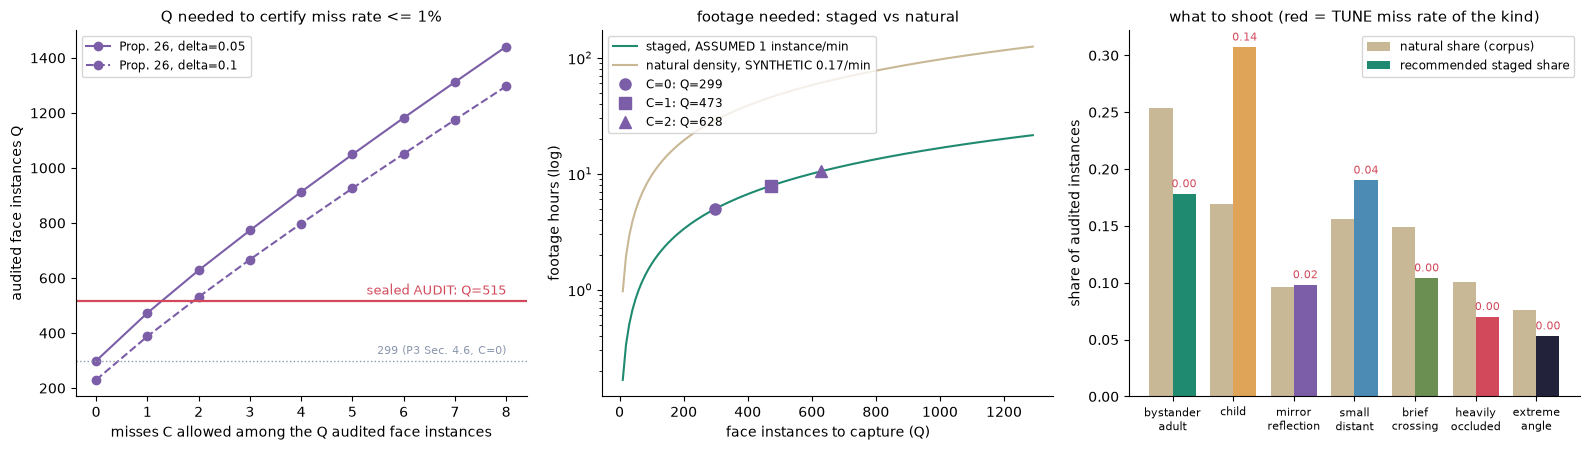

In [7]:
# VIZ
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
cs = np.arange(0, 9)
for delta, ls in [(0.05, "-"), (0.10, "--")]:
    ax.plot(cs, [min_q(C, EPS_TARGET, delta) for C in cs], "o" + ls, color=C_CERT, label=f"Prop. 26, delta={delta}")
ax.axhline(Q_AUDIT, color=C_REQ, lw=1.6)
ax.text(8, Q_AUDIT + 25, f"sealed AUDIT: Q={Q_AUDIT}", ha="right", color=C_REQ, fontsize=9)
ax.axhline(299, color=PALETTE["stone"], lw=1, ls=":"); ax.text(8, 299 + 25, "299 (P3 Sec. 4.6, C=0)", ha="right", color=PALETTE["stone"], fontsize=8)
ax.set_xlabel("misses C allowed among the Q audited face instances"); ax.set_ylabel("audited face instances Q")
ax.set_title("Q needed to certify miss rate <= 1%"); ax.legend(loc="upper left")

ax = axes[1]
qs = np.arange(10, 1300, 10)
ax.plot(qs, qs / INSTANCES_PER_MINUTE_STAGED / 60, color=C_LTT, label=f"staged, ASSUMED {INSTANCES_PER_MINUTE_STAGED:g} instance/min")
ax.plot(qs, qs / NATURAL_DENSITY_PER_MIN / 60, color=PALETTE["sand"], label=f"natural density, SYNTHETIC {NATURAL_DENSITY_PER_MIN:.2f}/min")
for C, mk in zip([0, 1, 2], ["o", "s", "^"]):
    q = int(SIZING_DF.loc[SIZING_DF["allowed_misses_C"] == C, "Q_min_delta0.05"].iloc[0])
    ax.plot(q, q / INSTANCES_PER_MINUTE_STAGED / 60, mk, color=C_CERT, ms=8, label=f"C={C}: Q={q}")
ax.set_yscale("log"); ax.set_xlabel("face instances to capture (Q)"); ax.set_ylabel("footage hours (log)")
ax.set_title("footage needed: staged vs natural"); ax.legend(loc="upper left")

ax = axes[2]
x = np.arange(len(COMP_DF)); w = 0.38
ax.bar(x - w / 2, COMP_DF["natural_share"], w, color=PALETTE["sand"], label="natural share (corpus)")
ax.bar(x + w / 2, COMP_DF["staged_share"], w, color=[KIND_COLORS[k] for k in COMP_DF["kind"]], label="recommended staged share")
for i, r in COMP_DF.iterrows():
    ax.text(i + w / 2, r["staged_share"] + 0.006, f"{r['tune_miss_rate']:.2f}", ha="center", fontsize=8, color=C_REQ)
ax.set_xticks(x); ax.set_xticklabels([k.replace("_", "\n") for k in COMP_DF["kind"]], fontsize=8)
ax.set_ylabel("share of audited instances"); ax.set_title("what to shoot (red = TUNE miss rate of the kind)"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

#### How to read this chart

**Left (Q needed).** The x-axis is the number of misses C you accept among the audited face instances; the y-axis is how many instances must be audited for the Prop. 26 bound to be at most 1%. Each line rises by about 140 to 175 instances per allowed miss. The dotted line is the paper's 299 for C = 0 at delta = 0.05. The red line is the sealed AUDIT split: it clears C = 0 and C = 1 but not C = 2, at either delta. Loosening delta from 0.05 to 0.10 saves roughly 70 to 140 instances.

**Middle (footage, log scale).** The same Q as footage hours. Green uses an **assumed** capture rate; sand uses the **synthetic** natural density. Under these numbers, waiting for natural faces takes about six times longer, which is the case for staged capture.

**Right (what to shoot).** Sand bars are natural shares, coloured bars the recommended staged shares, red numbers each kind's TUNE miss rate. Look for kinds with a high red number and a taller coloured bar: labels go where misses are.

For the job: the size of the labelled set is set by how many misses you can afford, not by how good the detector is.

## 3. Decide with Learn then Test

**The question.** Is there a configuration in the grid whose *miss risk* and *false-blur risk* are both below the client's targets, with probability at least 1 - delta, and if so which is the cheapest?

### 3(a) The LTT building blocks

The cell implements the pieces compactly; nothing is imported from Notebook 1. What each piece is, and where it comes from:

- **Guarantee.** A random choice lambda-hat is an (alpha, delta)-risk-controlling prediction if P(R(T_lambda-hat) <= alpha) >= 1 - delta `[P1 Def. 1, facered-q2]`. LTT tests, for every grid point, the null H_j: R(lambda_j) > alpha with p-values; any FWER-controlling procedure over those nulls yields the guarantee `[P1 Thm 1, facered-q2]`. If nothing is rejected, "the supremum over an empty set is defined as -inf" `[P1 Thm 1, facered-q2]`, and in practice we "abstain from returning an RCP" `[P1 Sec. 1.1, facered-q3]`. Abstaining is a legitimate outcome, not a failure of the code.
- **Level.** delta = 0.10, the paper's default example `[P1 Def. 1, facered-q2]`.
- **p-values.** For a binary loss, the exact binomial tail P(Bin(n, alpha) <= k), which is "the exact binomial tail bound" `[P1 Sec. 3.2, facered-q2]`; for a loss in [0, 1], the Hoeffding-Bentkus p-value `[P1 Prop. 1 Eq. 1, facered-q2]`.
- **Several risks at once.** Take p_j = max over the risks of p_{j,l}; this is a valid p-value for "some risk exceeds its target" `[P1 Prop. 6, facered-q2]`.
- **Fixed-sequence testing** `[P1 Alg. 1, Sec. 2.3.1, facered-q2]`: walk a fixed path of grid points, keep accepting while p <= delta/|J|, stop at the first failure. With one start (|J| = 1) there is no multiplicity penalty; with |J| starts each path is tested at delta/|J|.
- **Path learned on separate data.** P1 App. D splits the calibration data into a *graph selection set* and a *multiple testing set*, and learns the path on the first only `[P1 App. D, facered-q2]`. Here TUNE plays the graph set and CAL the testing set.
- **Free choice inside the accepted set.** One may "pick any lambda in Lambda-hat as their chosen RCP (even in a data-driven way)" `[P1 Sec. 2.1, facered-q3]`. We pick the cheapest.

**Derived here (not in P1).**
- *Miss risk* R_miss: the probability that a face instance has at least one visible frame uncovered; a binary loss per instance.
- *False-blur risk* R_fb: the mean over episodes of the false-blur fraction of that episode's blur box-frames (zero when the episode draws no box). It is an FDR-style risk in [0, 1] per **episode**; it is *not* pooled precision, and the two can differ (pooled precision is printed alongside). P2 leaves precision to other tools: SeqCRC "only empirically limits false positives" `[P2 Sec. V-D, facered-q6]`, which is why precision is handled by LTT here.
- The path rule: rank all grid points by their TUNE max-p (ties by safety headroom) so that every grid point, including the cheap strided ones, is reachable. P1's own beta-path construction is also implemented for comparison (section 3(c) reports how few grid points it visits here).
- The binomial p-value for R_miss treats face instances as independent, which is the assumption discussed in section 1.

There is no `CHECK` in this cell: correctness of the implementation is tested by simulation in 3(d) (CHECKs 3.2, 3.3, 3.5).

In [8]:
# ---- LTT building blocks, re-implemented compactly here (nothing imported from Notebook 1) ----
DELTA = 0.10                                   # error level; P1's default delta = 0.10 [facered-q2/q10]
ALPHA_T1 = dict(miss=0.01, fb=0.05)            # T1: the CLIENT's targets (recall >= 99% per instance; false-blur risk <= 5%)

def h1(a, b):
    a = np.clip(np.asarray(a, float), 0, 1)
    t1 = np.where(a > 0, a * np.log(np.maximum(a, 1e-300) / b), 0.0)
    t2 = np.where(a < 1, (1 - a) * np.log(np.maximum(1 - a, 1e-300) / (1 - b)), 0.0)
    return t1 + t2

def p_binom(k, n, alpha):
    """Exact binomial-tail p-value for a BINARY loss with k losses in n trials [P1 Sec. 3.2, facered-q2]: P(Bin(n, alpha) <= k)."""
    return stats.binom.cdf(k, n, alpha)

def p_hb(rhat, n, alpha):
    """Hoeffding-Bentkus p-value for a loss bounded in [0,1] [P1 Prop. 1, Eq. 1, facered-q2]."""
    rhat = np.asarray(rhat, float)
    bentkus = np.e * stats.binom.cdf(np.ceil(n * rhat - 1e-9), n, alpha)
    hoeffding = np.exp(-n * h1(np.minimum(rhat, alpha), alpha))
    return np.minimum(np.minimum(hoeffding, bentkus), 1.0)

def fixed_sequence(p_path, delta, starts=(0,)):
    """Algorithm 1 [P1 Sec. 2.3.1, facered-q2]: walk each start forward along the path while p <= delta/|J|; stop at the first failure.
    Returns (accepted mask over path positions, visited mask = positions whose p-value had to be evaluated)."""
    L = len(p_path); lvl = delta / len(starts)
    acc, vis = np.zeros(L, bool), np.zeros(L, bool)
    for s in starts:
        j = s
        if acc[j]:
            continue                                   # 'if lambda_j not in Lambda-hat'
        while j < L:
            vis[j] = True
            if p_path[j] <= lvl:
                acc[j] = True; j += 1
            else:
                break
    return acc, vis

# ---- losses from cached per-episode counts. Two risks, with EXPLICIT units (both derived here; only the LTT framework is P1) ----
#  R_miss(lam) = P(a face-to-redact INSTANCE has >= 1 uncovered visible frame): binary loss per instance; empirical = pooled misses / instances
#  R_fb(lam)   = E_episode[ FDP_e ],  FDP_e = (false blur box-frames)/(blur box-frames) of episode e, defined as 0 when the episode draws no box
#               (an FDR-style risk in [0,1] per EPISODE [P1 Sec. 3.1 FDR construction]); NOT the same as pooled precision (see section 5(e))
def to_matrices(loss_by_key: dict, work_names: list, keys: list) -> dict:
    """Stack per-config per-episode counts (from eval_many) over the given work chunks into matrices [G, E]."""
    def stack(field):
        return np.stack([np.concatenate([loss_by_key[(w, k)][field] for w in work_names]) for k in keys])
    n_inst = np.concatenate([loss_by_key[(w, keys[0])]["n_inst"] for w in work_names])
    n_miss, n_box, n_false = stack("n_miss"), stack("n_box"), stack("n_false")
    fdp = np.where(n_box > 0, n_false / np.maximum(n_box, 1), 0.0)
    return dict(n_inst=n_inst, n_miss=n_miss, n_box=n_box, n_false=n_false, fdp=fdp)

def risk_summary(M: dict, idx) -> dict:
    """Point estimates + counts on the episodes `idx` (vector over configs): miss rate, episode-averaged FDP, pooled precision."""
    ni = M["n_inst"][idx].sum(); ne = len(idx)
    return dict(n_inst=int(ni), n_ep=ne, miss=M["n_miss"][:, idx].sum(1) / ni, fb=M["fdp"][:, idx].mean(1),
                pooled_prec=1 - M["n_false"][:, idx].sum(1) / np.maximum(M["n_box"][:, idx].sum(1), 1),
                k_miss=M["n_miss"][:, idx].sum(1))

def ltt_pvalues(M: dict, idx, alpha: dict) -> dict:
    """p-values of both risks for ALL configs on the episodes idx, and the Prop. 6 max [P1 Prop. 6, facered-q2]."""
    s = risk_summary(M, idx)
    p_m = p_binom(s["k_miss"], s["n_inst"], alpha["miss"])
    p_f = p_hb(s["fb"], s["n_ep"], alpha["fb"])
    return dict(p_miss=p_m, p_fb=p_f, p_max=np.maximum(p_m, p_f), **{k: s[k] for k in ("miss", "fb", "pooled_prec", "n_inst", "n_ep")})

def learn_path(p_tune: dict, alpha: dict) -> np.ndarray:
    """Fixed test path learned on TUNE ONLY (P1 App. D split fixed-sequence; the path uses I_graph, the test uses I_testing).
    DERIVED HERE (a variation on App. D): rank ALL grid points by their TUNE max-p (Prop. 6), ties broken by the larger safety headroom
    max(R_miss/alpha_miss, R_fb/alpha_fb); every grid point is reachable, which matters because the cheap (strided) configs must be testable."""
    excess = np.maximum(p_tune["miss"] / alpha["miss"], p_tune["fb"] / alpha["fb"])
    return np.lexsort((excess, p_tune["p_max"]))

def appD_beta_path(p_tune: dict, alpha: dict, D: int = 200) -> np.ndarray:
    """P1 App. D's own path: lam~(beta) = argmin_j || [p_j1, p_j2] - [beta, beta] ||_inf on the TUNE p-values, beta = d/D; adjacent duplicates removed."""
    P = np.stack([p_tune["p_miss"], p_tune["p_fb"]], axis=1)
    path = [int(np.argmin(np.max(np.abs(P - d / D), axis=1))) for d in range(D + 1)]
    return np.array([j for i, j in enumerate(path) if i == 0 or j != path[i - 1]])

def ltt_select(M_tune, tune_idx, M_test, test_idx, alpha, delta=DELTA, starts=(0,)):
    """Whole LTT procedure of one split: path on TUNE -> fixed-sequence test on the test episodes -> (Lambda-hat mask over configs, details)."""
    pt = ltt_pvalues(M_tune, tune_idx, alpha)
    path = learn_path(pt, alpha)
    pc_ = ltt_pvalues(M_test, test_idx, alpha)
    acc_path, vis_path = fixed_sequence(pc_["p_max"][path], delta, starts)
    lam_hat = np.zeros(len(path), bool); lam_hat[path[acc_path]] = True
    visited = np.zeros(len(path), bool); visited[path[vis_path]] = True
    return lam_hat, dict(path=path, p_tune=pt, p_test=pc_, visited=visited)

### 3(b) Evaluate the grid on TUNE, fix the targets, then open CAL

**What this cell does.** It evaluates all 58 configurations on TUNE only and prints the frontier of TUNE point estimates (false-blur risk against miss risk). It also asks, for information only, whether any configuration meets the client's targets **T1** (miss <= 0.01, false-blur <= 0.05) on TUNE.

TUNE point estimates carry **no guarantee**: they are what the path and the targets are learned from. This cell has no `CHECK` because it asserts nothing; it only reports.

In [9]:
# ---- TUNE-only work: evaluate ALL grid configs on TUNE (parallel), learn nothing from CAL or AUDIT ----
t0 = time.time()
register_work("TUNE", CORP["TUNE"], DETS["TUNE"])
_res = eval_many([("TUNE", k) for k in ALL_KEYS])
M_TUNE = to_matrices(_res, ["TUNE"], ALL_KEYS)
t_tune_grid = time.time() - t0
IDX_TUNE = np.arange(len(CORP["TUNE"]["episodes"]))
S_TUNE = risk_summary(M_TUNE, IDX_TUNE)
print(f"all {G} configs evaluated on TUNE ({len(IDX_TUNE)} episodes, {S_TUNE['n_inst']} instances) in {t_tune_grid:.1f}s wall on {N_WORKERS} workers")

FRONT = pd.DataFrame(dict(thr=[k[0] for k in ALL_KEYS], stride=[k[1] for k in ALL_KEYS], gap=[k[2] for k in ALL_KEYS], pad=[k[3] for k in ALL_KEYS],
                          margin=[k[4] for k in ALL_KEYS], tune_miss=S_TUNE["miss"], tune_fb=S_TUNE["fb"], tune_pooled_prec=S_TUNE["pooled_prec"]))
def pareto(df, xcol, ycol):
    d = df.sort_values([xcol, ycol]); best, keep = np.inf, []
    for i, r in d.iterrows():
        if r[ycol] < best:
            keep.append(i); best = r[ycol]
    return df.loc[keep]
FRONT_PARETO = pareto(FRONT, "tune_fb", "tune_miss")
print("TUNE Pareto frontier (false-blur risk vs miss risk; point estimates, TUNE only):")
print(FRONT_PARETO.round(3).to_string(index=False))

# T1 on TUNE (information only): best miss among configs, and the smallest fb among configs with miss <= 1%
t1_ok_tune = FRONT[(FRONT["tune_miss"] <= ALPHA_T1["miss"]) & (FRONT["tune_fb"] <= ALPHA_T1["fb"])]
print(f"\nT1 (client) on TUNE: configs with miss <= {ALPHA_T1['miss']} AND episode-FDP <= {ALPHA_T1['fb']}: {len(t1_ok_tune)} of {G}; "
      f"lowest miss anywhere {FRONT['tune_miss'].min():.4f}; lowest FDP among miss<=1%: "
      f"{FRONT.loc[FRONT['tune_miss'] <= 0.01, 'tune_fb'].min() if (FRONT['tune_miss'] <= 0.01).any() else float('nan'):.3f}")

all 58 configs evaluated on TUNE (650 episodes, 437 instances) in 25.5s wall on 5 workers
TUNE Pareto frontier (false-blur risk vs miss risk; point estimates, TUNE only):
 thr  stride  gap  pad  margin  tune_miss  tune_fb  tune_pooled_prec
0.90       1   30    5     0.3      0.414    0.185             0.786
0.95       1   30   20     0.3      0.410    0.191             0.703
0.90       1   10   20     0.3      0.222    0.250             0.700
0.80       1   30    5     0.3      0.208    0.251             0.750
0.90       1   10   40     0.3      0.089    0.294             0.633
0.70       1   30    5     0.3      0.085    0.311             0.694
0.80       1   10   20     0.3      0.078    0.322             0.619
0.80       1   30   20     0.3      0.076    0.329             0.597
0.75       1   30   20     0.3      0.037    0.355             0.563
0.70       1   10   20     0.3      0.027    0.385             0.529
0.65       1   30   20     0.3      0.023    0.421             0.496
0

**Two target sets, fixed before any CAL or AUDIT label is touched.** P3's Assumption 1 prohibits "use of certification labels to construct, tune, order, or select" what is being certified `[P3 Assumption 1, facered-q7]`; this cell applies the same discipline to the targets, by writing them to `data/nb3/prereg_targets.json` and to the event log before CAL is evaluated.

- **T1** is the client's: alpha_miss = 0.01 (recall >= 99% per instance), alpha_fb = 0.05.
- **T2-v1** is a relaxed **demonstration** target (**derived here**), chosen by a written rule from TUNE point estimates only: the smallest alpha_miss on a ladder for which at least 8 configurations have TUNE miss at least 0.02 below it, and alpha_fb set 0.05 above the best TUNE false-blur risk among those configurations, rounded up to a multiple of 0.05.

T2 exists because T1 is expected to fail (it already fails on TUNE) and the reader should see what a certified result looks like, and what it costs, without pretending the client's targets were met.

**CHECK 3.1 (a-priori).** The event log shows the targets were recorded before the CAL grid was evaluated, and T2-v1 is strictly looser than T1 on both risks. Note this check verifies ordering in the log and looseness; it does not verify that the rule was sensible.

In [10]:
# ---- Two target sets, FIXED BEFORE any CAL or AUDIT label is touched (P3 Assumption 1 discipline; recorded in an event log + JSON) ----
# T1 = the client's targets (given). T2-v1 = a relaxed DEMONSTRATION target, chosen by the following rule using TUNE point estimates ONLY:
#   for alpha_miss in the ladder [0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20] (increasing), let S = grid configs whose TUNE miss rate is
#   <= alpha_miss - 0.02 (a 2-point headroom, ~2 binomial SE at n=437). Take the first alpha_miss with |S| >= 8; then
#   alpha_fb = the smallest multiple of 0.05 that is >= (min TUNE episode-FDP over S) + 0.05 (a 5-point headroom, ~3 SE at n=650).
def choose_t2(tune_miss, tune_fb, ladder=(0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20), headroom_miss=0.02, headroom_fb=0.05, min_configs=8):
    for a in ladder:
        S = np.where(tune_miss <= a - headroom_miss)[0]
        if len(S) >= min_configs:
            return dict(miss=a, fb=float(np.round(np.ceil((tune_fb[S].min() + headroom_fb) / 0.05 - 1e-9) * 0.05, 2)), n_configs=len(S))
    return None
_t2 = choose_t2(S_TUNE["miss"], S_TUNE["fb"])
ALPHA_T2_V1 = dict(miss=_t2["miss"], fb=_t2["fb"])          # first pre-registered T2 (revised in section 3(c) after a failed first test)
PREREG = dict(delta=DELTA, T1=ALPHA_T1, T2_v1=ALPHA_T2_V1, T2_rule="see cell comment: smallest alpha_miss on the ladder with >= 8 configs at TUNE miss <= alpha-0.02; alpha_fb = ceil_to_0.05(min TUNE FDP over those + 0.05)",
              tune_configs_within_headroom=_t2["n_configs"], fixed_at=time.strftime("%Y-%m-%d %H:%M:%S"))
log_event("targets T1/T2 fixed from TUNE only (CAL not yet evaluated)")
(NB3_DIR / "prereg_targets.json").write_text(json.dumps(PREREG, indent=2))
print(json.dumps(PREREG, indent=2))
print(f"\nT1 (client):  alpha_miss = {ALPHA_T1['miss']}, alpha_fb = {ALPHA_T1['fb']}, delta = {DELTA}")
print(f"T2-v1 (relaxed demonstration, from the TUNE frontier): alpha_miss = {ALPHA_T2_V1['miss']}, alpha_fb = {ALPHA_T2_V1['fb']}, delta = {DELTA}   "
      f"[{_t2['n_configs']} configs sit within the headroom on TUNE]")
check("3.1", "T2-v1 was fixed by the written rule from TUNE alone: the event log shows the targets were recorded before the CAL grid was evaluated, and T2-v1 is "
      "strictly looser than T1 on both risks", ALPHA_T2_V1["miss"] > ALPHA_T1["miss"] and ALPHA_T2_V1["fb"] > ALPHA_T1["fb"] and EVENTS[-1][1].startswith("targets"),
      f"T2-v1 = ({ALPHA_T2_V1['miss']}, {ALPHA_T2_V1['fb']}); events so far: {[e[1][:28] for e in EVENTS]}")

{
  "delta": 0.1,
  "T1": {
    "miss": 0.01,
    "fb": 0.05
  },
  "T2_v1": {
    "miss": 0.03,
    "fb": 0.55
  },
  "T2_rule": "see cell comment: smallest alpha_miss on the ladder with >= 8 configs at TUNE miss <= alpha-0.02; alpha_fb = ceil_to_0.05(min TUNE FDP over those + 0.05)",
  "tune_configs_within_headroom": 11,
  "fixed_at": "2026-09-19 14:32:36"
}

T1 (client):  alpha_miss = 0.01, alpha_fb = 0.05, delta = 0.1
T2-v1 (relaxed demonstration, from the TUNE frontier): alpha_miss = 0.03, alpha_fb = 0.55, delta = 0.1   [11 configs sit within the headroom on TUNE]
CHECK 3.1: T2-v1 was fixed by the written rule from TUNE alone: the event log shows the targets were recorded before the CAL grid was evaluated, and T2-v1 is strictly looser than T1 on both risks -> T2-v1 = (0.03, 0.55); events so far: ['targets T1/T2 fixed from TUN'] -> PASS


**Open CAL and run LTT.** For each target set the procedure is: path from TUNE, single-start fixed-sequence test on CAL at delta = 0.10 with the max-p of the two risks. In production only the configurations the walk *visits* would be run on CAL; here all 58 are evaluated up front because 3(d) re-uses them. The printed "p-values evaluated for N configs" is the number the walk actually needed.

Both T1 and T2-v1 are tested on this same split (CAL1), each at level delta; the outputs of an empty set (abstain) are reported as such, and three CAL point estimates closest to the targets are shown for orientation only. They are **not** certified and must not be read as results.

In [11]:
# ---- LTT-CAL: open the CAL split for the first time. (In production only the configs the fixed-sequence walk VISITS would be run on CAL;
# ---- here all grid points are evaluated in parallel up front because section 3(c) re-uses them for the re-split simulation.) ----
log_event("CAL split opened")
t0 = time.time()
register_work("CAL", CORP["CAL"], DETS["CAL"])
_res = eval_many([("CAL", k) for k in ALL_KEYS])
M_CAL = to_matrices(_res, ["CAL"], ALL_KEYS)
IDX_CAL = np.arange(len(CORP["CAL"]["episodes"]))
print(f"all {G} configs evaluated on CAL ({len(IDX_CAL)} episodes, {int(M_CAL['n_inst'].sum())} instances) in {time.time() - t0:.1f}s wall")

def describe_key(k):
    return f"thr={k[0]:.2f} stride={k[1]} gap={k[2]} pad={k[3]} margin={k[4]}"

LTT_MAIN = {}
for name, alpha in [("T1", ALPHA_T1), ("T2v1", ALPHA_T2_V1)]:
    lam_hat, det = ltt_select(M_TUNE, IDX_TUNE, M_CAL, IDX_CAL, alpha, DELTA, starts=(0,))
    LTT_MAIN[name] = dict(lam_hat=lam_hat, **det)
    n_acc, n_vis = int(lam_hat.sum()), int(det["visited"].sum())
    print(f"\n=== {name}: alpha_miss={alpha['miss']}, alpha_fb={alpha['fb']}, delta={DELTA} -> |Lambda-hat| = {n_acc} of {G}; "
          f"CAL p-values evaluated for {n_vis} configs (lazy fixed-sequence walk)")
    if n_acc == 0:
        p_c = det["p_test"]
        exc = np.maximum(p_c["miss"] / alpha["miss"], p_c["fb"] / alpha["fb"])          # normalised excess over the targets (smaller = closer)
        top = np.argsort(exc)[:3]
        print(f"    NO CERTIFIED CONFIGURATION (empty Lambda-hat: abstain) [P1 Sec. 1.1]. Three CAL point estimates closest to the targets (NOT certified):")
        print(pd.DataFrame(dict(config=[describe_key(ALL_KEYS[i]) for i in top], cal_miss=p_c["miss"][top], cal_fdp=p_c["fb"][top],
                                cal_pooled_precision=p_c["pooled_prec"][top])).round(4).to_string(index=False))
        ok1 = (p_c["miss"] <= alpha["miss"]) & (p_c["fb"] <= alpha["fb"])
        print(f"    configs whose CAL point estimates meet BOTH {name} targets: {int(ok1.sum())}; lowest CAL miss {p_c['miss'].min():.4f}; "
              f"lowest CAL FDP among miss<=1%: {p_c['fb'][p_c['miss'] <= 0.01].min() if (p_c['miss'] <= 0.01).any() else float('nan'):.3f}")
    else:
        rows = []
        for j in np.where(lam_hat)[0]:
            rows.append(dict(config=describe_key(ALL_KEYS[j]), cal_miss=det["p_test"]["miss"][j], cal_fb=det["p_test"]["fb"][j],
                             cal_pooled_prec=det["p_test"]["pooled_prec"][j], p_max_cal=det["p_test"]["p_max"][j]))
        print(pd.DataFrame(rows).round(4).sort_values("cal_miss").to_string(index=False))

all 58 configs evaluated on CAL (950 episodes, 633 instances) in 34.9s wall

=== T1: alpha_miss=0.01, alpha_fb=0.05, delta=0.1 -> |Lambda-hat| = 0 of 58; CAL p-values evaluated for 1 configs (lazy fixed-sequence walk)
    NO CERTIFIED CONFIGURATION (empty Lambda-hat: abstain) [P1 Sec. 1.1]. Three CAL point estimates closest to the targets (NOT certified):
                                    config  cal_miss  cal_fdp  cal_pooled_precision
thr=0.75 stride=1 gap=30 pad=20 margin=0.3    0.0585   0.3083                0.5883
 thr=0.60 stride=1 gap=30 pad=5 margin=0.3    0.0585   0.3272                0.6522
thr=0.80 stride=1 gap=10 pad=40 margin=0.3    0.0395   0.3281                0.5462
    configs whose CAL point estimates meet BOTH T1 targets: 0; lowest CAL miss 0.0079; lowest CAL FDP among miss<=1%: 0.607

=== T2v1: alpha_miss=0.03, alpha_fb=0.55, delta=0.1 -> |Lambda-hat| = 0 of 58; CAL p-values evaluated for 1 configs (lazy fixed-sequence walk)
    NO CERTIFIED CONFIGURATION (empty 

**Reading the outcome.**

- **T1 (the client's targets) yields no certified configuration.** Lambda-hat is empty on CAL1: the procedure abstains `[P1 Sec. 1.1, facered-q3]`. The walk needed only one p-value, because the first path element already failed. No configuration even meets both T1 targets by *point estimate* on CAL1; the lowest false-blur risk among configurations with miss <= 1% is 0.607 against a target of 0.05. On TUNE the picture was the same (no configuration meets T1; the lowest false-blur risk among configurations with miss <= 1% is 0.492). At this detector quality the cost of pushing the miss rate down to 1% is blurring a lot of things that are not faces, and no tuning of stride, padding or threshold in this grid escapes that.
- **T2-v1 (miss 0.03, false-blur 0.55) also gave an empty Lambda-hat on CAL1**, although 14 configurations meet it by point estimate. Section 3(c) diagnoses why, and revises the demonstration target in the open.
- The false blur is mostly a property of the simulator: Notebook 2's decomposition attributes 70% of false blur box-frames at its best-recall configuration to pets (the generator gives pets the highest false-positive logit and the longest tracks). That is a **synthetic** modelling choice, never a real-world finding.

### 3(c) T2 was revised after a failed first attempt

This is a disclosure before it is a computation. **T2-v1 failed on CAL1. T2 was then revised, and the revision was tested on a fresh split (CAL2).** The order of events is in `data/nb3/prereg_targets.json` (the `fixed_at` fields) and in the event log.

1. T2-v1 (alpha_miss 0.03, alpha_fb 0.55) was fixed from TUNE before CAL1 was evaluated (CHECK 3.1).
2. It gave an empty Lambda-hat on CAL1. The cell prints why. The first configuration on the path was the one that looked safest on TUNE (4 misses in 437 instances), but on CAL1 it had 16 misses in 633 instances (0.0253): below the target 0.03, yet not by enough for the binomial p-value (0.289) to fall under delta = 0.10. Fixed-sequence testing stops at the first failure, so Lambda-hat was empty even though a few other configurations have an *uncorrected* p_max below delta; p-values of configurations the walk never reached are not certificates. Two explanations are printed: (i) at alpha_miss = 0.03, 633 instances expect only about 19 misses, so the test has little power; (ii) the first path element is the winner of a 58-way contest on TUNE (a winner's curse). (ii) is consistent with the numbers but is not tested here.
3. **After seeing that failure**, the rule for T2 was rewritten (**derived here**): alpha_miss must be large enough that the *planned* CAL2 sample expects at least 30 misses (so the binomial test has power), and the headroom on TUNE is sized in standard errors from planned sample sizes, not from CAL1 labels. The rule uses only TUNE and planned CAL2 sizes, and is recorded before CAL2 is evaluated.
4. CAL2 is then opened, and LTT is run with exactly the same procedure as before.

**Why a fresh split.** P3 warns that reusing audit labels to certify something they helped design "voids the guarantee" `[P3 Sec. 2.4, facered-q12]`, and its Assumption 1 prohibits "use of certification labels to construct, tune, order, or select" what is certified `[P3 Assumption 1, facered-q7]`. P3 states this for candidate generators; applying it to the *targets* is **derived here**, by analogy. CAL1 was looked at, so it is declared consumed and CAL2, untouched, is the test set. This is the design-certification separation discipline in action: the revision is only allowed to count because it is tested on labels that played no part in it.

In [12]:
# ---- 3(c) What went wrong with T2-v1, and the revision (pre-registered on TUNE + planned sample sizes only, tested on the FRESH split CAL2) ----
_d = LTT_MAIN["T2v1"]; _j0 = int(_d["path"][0]); _pt, _pc = _d["p_tune"], _d["p_test"]
print(f"T2-v1 diagnosis. The path's first config ({describe_key(ALL_KEYS[_j0])}) is the one that looked SAFEST on TUNE: "
      f"{int(round(_pt['miss'][_j0] * _pt['n_inst']))}/{_pt['n_inst']} misses on TUNE ({_pt['miss'][_j0]:.4f}, p_miss={_pt['p_miss'][_j0]:.4f}), "
      f"but {int(round(_pc['miss'][_j0] * _pc['n_inst']))}/{_pc['n_inst']} on CAL ({_pc['miss'][_j0]:.4f}, p_miss={_pc['p_miss'][_j0]:.3f} > delta={DELTA}). "
      f"Fixed-sequence testing stops at the first failure, so Lambda-hat was empty although {int((_pc['p_max'] <= DELTA).sum())} of {G} configs have CAL p_max <= delta.")
print(f"Two reasons, both visible BEFORE looking at CAL had we done the arithmetic: (i) alpha_miss={ALPHA_T2_V1['miss']} needs the CAL miss count to fall well below "
      f"{ALPHA_T2_V1['miss'] * _pc['n_inst']:.0f} expected misses (only ~19 at n={_pc['n_inst']}); (ii) the first path element is the winner of a 58-way contest on TUNE (winner's curse).")

# --- T2-v2: rule fixed from TUNE + PLANNED CAL2 sizes only (no CAL1 or CAL2 label used) ---
n_cal2_inst_planned = int(round(S_TUNE["n_inst"] / len(IDX_TUNE) * N_CAL2))       # TUNE's instances-per-episode x planned CAL2 episodes
def choose_t2_v2(tune_miss, tune_fb, n_inst_plan, n_ep_plan, ladder=(0.05, 0.075, 0.10, 0.15, 0.20), z=2.5, min_configs=8, min_expected_misses=30):
    """alpha_miss: smallest ladder value with alpha*n_inst_plan >= 30 expected CAL misses (so the binomial test has power) and >= 8 configs with TUNE
    miss <= alpha - z*SE(alpha; n_inst_plan) [z=2.5 ~ 1.28 for the delta=0.10 test + ~1.2 for TUNE-to-CAL noise]; alpha_fb = ceil_to_0.05(min TUNE FDP over those
    + z * 0.5/sqrt(n_ep_plan)) (0.5 = worst-case sd of a [0,1] loss)."""
    for a in ladder:
        if a * n_inst_plan < min_expected_misses:
            continue
        S = np.where(tune_miss <= a - z * np.sqrt(a * (1 - a) / n_inst_plan))[0]
        if len(S) >= min_configs:
            hf = z * 0.5 / np.sqrt(n_ep_plan)
            return dict(miss=a, fb=float(np.round(np.ceil((tune_fb[S].min() + hf) / 0.05 - 1e-9) * 0.05, 2)), n_configs=len(S), planned_n_inst=n_inst_plan)
_t2b = choose_t2_v2(S_TUNE["miss"], S_TUNE["fb"], n_cal2_inst_planned, N_CAL2)
ALPHA_T2 = dict(miss=_t2b["miss"], fb=_t2b["fb"])                                  # THE T2 used from here on
PREREG["T2_v2"] = dict(ALPHA_T2, delta=DELTA, planned_cal2_instances=n_cal2_inst_planned, configs_within_headroom=_t2b["n_configs"],
                       fixed_at=time.strftime("%Y-%m-%d %H:%M:%S"),
                       reason="T2-v1 gave an empty Lambda-hat on CAL1 (first path element failed); revised rule sizes alpha and headroom from LTT's own power requirement; tested on fresh CAL2")
log_event("T2-v2 rule fixed from TUNE + planned sizes only; CAL1 declared consumed")
(NB3_DIR / "prereg_targets.json").write_text(json.dumps(PREREG, indent=2))
print(f"\nT2-v2 (fixed before CAL2 is touched): alpha_miss={ALPHA_T2['miss']}, alpha_fb={ALPHA_T2['fb']}, delta={DELTA}  "
      f"({_t2b['n_configs']} configs within headroom on TUNE; planned CAL2 instances {n_cal2_inst_planned})")

# --- open CAL2 and run LTT with the SAME procedure (path from TUNE, single-start fixed sequence) ---
log_event("CAL2 split opened")
t0 = time.time()
register_work("CAL2", CORP["CAL2"], DETS["CAL2"])
_res = eval_many([("CAL2", k) for k in ALL_KEYS])
M_CAL2 = to_matrices(_res, ["CAL2"], ALL_KEYS)
IDX_CAL2 = np.arange(len(CORP["CAL2"]["episodes"]))
print(f"all {G} configs evaluated on CAL2 ({len(IDX_CAL2)} episodes, {int(M_CAL2['n_inst'].sum())} instances) in {time.time() - t0:.1f}s wall")
lam_hat2, det2 = ltt_select(M_TUNE, IDX_TUNE, M_CAL2, IDX_CAL2, ALPHA_T2, DELTA, starts=(0,))
LTT_MAIN["T2"] = dict(lam_hat=lam_hat2, **det2)
print(f"\n=== T2 (v2) on CAL2: |Lambda-hat| = {int(lam_hat2.sum())} of {G}; CAL2 p-values evaluated for {int(det2['visited'].sum())} configs (lazy walk)")
if lam_hat2.any():
    _rows = [dict(config=describe_key(ALL_KEYS[j]), cal2_miss=det2["p_test"]["miss"][j], cal2_fb=det2["p_test"]["fb"][j],
                  cal2_pooled_prec=det2["p_test"]["pooled_prec"][j], p_max=det2["p_test"]["p_max"][j]) for j in np.where(lam_hat2)[0]]
    print(pd.DataFrame(_rows).round(4).sort_values("cal2_miss").to_string(index=False))

T2-v1 diagnosis. The path's first config (thr=0.50 stride=2 gap=30 pad=20 margin=0.3) is the one that looked SAFEST on TUNE: 4/437 misses on TUNE (0.0092, p_miss=0.0031), but 16/633 on CAL (0.0253, p_miss=0.289 > delta=0.1). Fixed-sequence testing stops at the first failure, so Lambda-hat was empty although 5 of 58 configs have CAL p_max <= delta.
Two reasons, both visible BEFORE looking at CAL had we done the arithmetic: (i) alpha_miss=0.03 needs the CAL miss count to fall well below 19 expected misses (only ~19 at n=633); (ii) the first path element is the winner of a 58-way contest on TUNE (winner's curse).

T2-v2 (fixed before CAL2 is touched): alpha_miss=0.05, alpha_fb=0.45, delta=0.1  (25 configs within headroom on TUNE; planned CAL2 instances 639)


all 58 configs evaluated on CAL2 (950 episodes, 619 instances) in 33.3s wall

=== T2 (v2) on CAL2: |Lambda-hat| = 2 of 58; CAL2 p-values evaluated for 3 configs (lazy walk)
                                    config  cal2_miss  cal2_fb  cal2_pooled_prec  p_max
thr=0.70 stride=1 gap=10 pad=20 margin=0.3     0.0355   0.3727            0.5249 0.0542
thr=0.70 stride=1 gap=30 pad=20 margin=0.3     0.0355   0.3763            0.5196 0.0542


**What the T2 result does and does not cover.**

- **Result.** With T2-v2 (alpha_miss 0.05, alpha_fb 0.45, delta 0.10), Lambda-hat on CAL2 has two configurations. Both are stride 1 (same threshold, padding and margin; they differ only in the bridging gap), and the walk needed three p-values. The cheapest is `thr=0.70 stride=1 gap=10 pad=20 margin=0.3`, with CAL2 point estimates miss 0.0355, false-blur 0.373, pooled precision 0.525, p_max 0.0542.
- **Covered.** The final procedure (path from TUNE; T2-v2 fixed before CAL2 was opened; single-start fixed-sequence test on CAL2) carries the P1 guarantee: with probability at least 0.90, every configuration in Lambda-hat has both risks below the T2-v2 targets. This is the statement a reader may quote, and only for T2-v2.
- **Not covered.** The overall two-attempt process is **not** a clean single pre-registration. The T2-v2 targets were chosen after CAL1 had shown that T2-v1 fails; had T2-v2 also failed, the natural next step would have been a T2-v3. The guarantee conditions on the targets as given and does not account for that choice among attempts. Moreover T1 and T2-v1 were both tested on CAL1, so those two looks jointly use up to 2 x delta on one split.
- **What this certificate is not.** T2 is a demonstration target. The certified configuration has a pooled precision of about 0.53 on CAL2, far from the client's 95%, and a false-blur risk of 0.37 against the client's 0.05. It certifies a *recall-oriented* configuration that would blur a great deal; it does not meet the client's job.
- **Cost of certifying.** Every certified configuration here is stride 1, so certification bought no cost saving in this run (the cost table follows in the summary).

#### Cost inputs for "cheapest valid"

Choosing the cheapest configuration in Lambda-hat needs a cost per configuration. All of this is **derived here**: none of the three papers covers cost minimisation among valid configurations `[facered-q12 (d)]`. The throughput comes from the smoke test of Notebook 2 (decode, 4K detection and encode speeds on this machine's CPU), which is **measured** with several-fold run-to-run variance on a shared VM. The GPU speed-up and the CPU and GPU prices per hour are **assumed** constants you must replace with vendor quotes and your own measurements. In this model cost depends on the stride only (a strided pipeline detects on fewer frames), so stride is the only lever that lowers cost within the grid.

In [13]:
# ---- throughput dict built at run time from the MEASURED smoke-test JSON (Notebook 2, section 4), plus ASSUMED GPU/price constants ----
_T = json.loads(TIMINGS_PATH.read_text())
def _ffmpeg_fps(step, fallback):
    v = [r["fps"] for r in _T["ffmpeg"] if r["step"] == step and r["fps"] == r["fps"]]
    return (float(v[0]), "measured") if v else (float(fallback), "ASSUMED fallback")
decode_fps_measured, _src_dec = _ffmpeg_fps("decode", 25.0)
encode_fps_measured, _src_enc = _ffmpeg_fps("encode_x264_veryfast", 2.0)
detect_fps_measured = 1000.0 / float(np.mean([r["ms"] for r in _T["detect"] if r["mode"] == "4k_full"]))
ASSUMED_GPU_SPEEDUP = 8.0          # ASSUMPTION (same name/value as NB2): GPU-batched detector ~8x faster than this CPU path
ASSUMED_CPU_USD_PER_HOUR = 0.05    # ASSUMPTION (same as NB2): generic CPU instance rental, NOT a provider quote
ASSUMED_GPU_USD_PER_HOUR = 0.60    # ASSUMPTION (same as NB2): small-GPU instance rental, order of magnitude, NOT a provider quote
THROUGHPUT = dict(decode_fps=decode_fps_measured, detect_fps=detect_fps_measured, encode_fps=encode_fps_measured, fps=30,
                  assumed_gpu_speedup=ASSUMED_GPU_SPEEDUP)
PRICE = dict(assumed_cpu_usd_per_hour=ASSUMED_CPU_USD_PER_HOUR, assumed_gpu_usd_per_hour=ASSUMED_GPU_USD_PER_HOUR)
print(f"MEASURED on this shared WSL2 VM (data/smoke/timings.json, 15-frame 4K clip; several-fold run-to-run variance, NB2 section 4): "
      f"decode {decode_fps_measured:.1f} fps ({_src_dec}), YuNet 4K detect {detect_fps_measured:.2f} fps, libx264-veryfast encode {encode_fps_measured:.2f} fps ({_src_enc})")
print(f"ASSUMED (human must replace): GPU speed-up {ASSUMED_GPU_SPEEDUP}x, CPU ${ASSUMED_CPU_USD_PER_HOUR}/h, GPU ${ASSUMED_GPU_USD_PER_HOUR}/h")
COST_BY_STRIDE = {s: processing_cost(dict(stride=s), THROUGHPUT, PRICE) for s in (1, 2, 4)}
print("processing_cost by stride (CPU $/video-hour = measured throughput x ASSUMED price):",
      {s: round(v["cpu_usd_per_video_hour"], 3) for s, v in COST_BY_STRIDE.items()})
def cost_of_key(key, kind="cpu"):
    return processing_cost(pc_of(key), THROUGHPUT, PRICE)[f"{kind}_usd_per_video_hour"]
COST_VEC = np.array([cost_of_key(k) for k in ALL_KEYS])         # CPU $/video-hour per grid config (depends on stride only)

MEASURED on this shared WSL2 VM (data/smoke/timings.json, 15-frame 4K clip; several-fold run-to-run variance, NB2 section 4): decode 12.3 fps (measured), YuNet 4K detect 0.78 fps, libx264-veryfast encode 2.78 fps (measured)
ASSUMED (human must replace): GPU speed-up 8.0x, CPU $0.05/h, GPU $0.6/h
processing_cost by stride (CPU $/video-hour = measured throughput x ASSUMED price): {1: 2.581, 2: 1.621, 4: 1.141}


### 3(d) Verification by simulation

**Claim tested.** LTT's guarantee is a statement over repeated samples: if the whole procedure (path from TUNE, test on CAL) were repeated on fresh data, the chosen configuration's *true* risk should exceed its target in at most about a fraction delta of the runs `[P1 Thm 1, facered-q2]`. We check that by re-splitting.

**Design (derived here).** The 2,550 episodes of TUNE + CAL + CAL2 are re-split at random R = 200 times with the main run's sizes (650 TUNE, 950 CAL). For each re-split and each procedure, the cheapest configuration in Lambda-hat is chosen, and its "true" risk is taken from the separate TRUTH population (2,400 episodes, which is itself a finite sample, so "true" carries a small noise). A run is a *violation* if either true risk exceeds its target. Five procedures are simulated: T1; T2 with a single start; T2 with 3 and with 5 starts (each start tested at delta/|J|); and a **T2-tight** boundary case with alpha = 1.4 times the true risk of the main run's choice, so that some configurations are truly unsafe and the guarantee is not vacuous. **Disclosure:** a first attempt with factor 1.0 abstained on every re-split (LTT needs headroom); the factor was loosened to 1.4 *after seeing that*, so it is a demonstration knob, not a claimed threshold.

**CHECKs (a-priori threshold, decided before the run).**
- 3.2 / 3.3 / 3.5: for T1 / T2 / T2-tight, the violation rate over the 200 re-splits is at most delta + 3 binomial standard errors = 0.164.
- 3.6: abstain rate is non-decreasing from 1 to 3 to 5 starts (multi-start pays delta/|J| per path).

Two caveats. First, we test the *chosen* configuration only, which is a weaker event than the theorem's "every configuration in Lambda-hat". Second, CHECK 3.2 for T1 has nothing to test: if a procedure always abstains it never selects, so it cannot violate. Its PASS is vacuous and says only that abstention is safe.

In [14]:
# ---- 3(d) Verification by simulation: R random re-splits of a pool; "true" risks from the separate TRUTH population ----
def concat_M(Ms):
    return dict(n_inst=np.concatenate([m["n_inst"] for m in Ms]), **{f: np.concatenate([m[f] for m in Ms], axis=1) for f in ("n_miss", "n_box", "n_false", "fdp")})
M_POOL = concat_M([M_TUNE, M_CAL, M_CAL2])                       # 650 + 950 + 950 = 2,550 episodes, all 58 configs
E_POOL = len(M_POOL["n_inst"]); R_SPLITS = 200
print(f"re-split pool: {E_POOL} episodes ({int(M_POOL['n_inst'].sum())} instances); each re-split draws TUNE={N_TUNE} and CAL={N_CAL} episodes at random (same sizes as the main run)")

# ---- TRUTH: lazily evaluated only for the configs some procedure actually selects (cache) ----
for _n, _c in TRUTH_CH.items():
    register_work(_n, _c, TRUTH_CH_DET[_n])
TRUTH_CACHE = {}
def truth_risks(keys):
    missing = [k for k in dict.fromkeys(keys) if k not in TRUTH_CACHE]
    if missing:
        res = eval_many([(n, k) for k in missing for n in TRUTH_CH])
        for k in missing:
            M = to_matrices(res, list(TRUTH_CH), [k])
            ni = M["n_inst"].sum()
            TRUTH_CACHE[k] = dict(miss=float(M["n_miss"][0].sum() / ni), fb=float(M["fdp"][0].mean()), n_inst=int(ni), n_ep=len(M["n_inst"]),
                                  pooled_prec=float(1 - M["n_false"][0].sum() / max(M["n_box"][0].sum(), 1)))
    return {k: TRUTH_CACHE[k] for k in keys}

def pick_cheapest(lam_hat, p_test):
    """Among Lambda-hat: minimum $/video-hour, then minimum CAL episode-FDP, then minimum CAL miss (any lambda in Lambda-hat keeps the guarantee, P1 Sec. 2.1)."""
    idx = np.where(lam_hat)[0]
    if len(idx) == 0:
        return -1
    order = np.lexsort((p_test["miss"][idx], p_test["fb"][idx], np.round(COST_VEC[idx], 9)))
    return int(idx[order[0]])

# target sets and start sets simulated: T1, T2 (single start), T2 with multi-start J=3 and J=5 (each start tested at delta/|J|), and T2-tight: the boundary case
# alpha = 1.4 x the TRUE risks of the main run's chosen T2 config, so that some grid configs are truly (slightly) unsafe and the guarantee is not vacuous.
# (A first attempt with factor 1.0 abstained on every one of 200 re-splits -- LTT needs headroom -- so the factor was loosened to 1.4 AFTER seeing that; this is a
#  demonstration knob, not a claimed threshold.)
_jm = pick_cheapest(LTT_MAIN["T2"]["lam_hat"], LTT_MAIN["T2"]["p_test"])
_tm = truth_risks([ALL_KEYS[_jm]])[ALL_KEYS[_jm]]
ALPHA_TIGHT = dict(miss=round(1.4 * _tm["miss"], 4), fb=round(min(1.4 * _tm["fb"], 0.95), 4))
PROCS = {"T1": (ALPHA_T1, (0,)), "T2": (ALPHA_T2, (0,)), "T2 multi-start J=3": (ALPHA_T2, (0, 15, 30)), "T2 multi-start J=5": (ALPHA_T2, (0, 12, 24, 36, 48)),
         "T2-tight (alpha = 1.4 x true risk of the main-run choice)": (ALPHA_TIGHT, (0,))}
t0 = time.time()
rng_rs = np.random.default_rng(SEED + 11)
RS = {name: dict(chosen=[], size=[], visited=[]) for name in PROCS}
for r in range(R_SPLITS):
    perm = rng_rs.permutation(E_POOL)
    tune_i, cal_i = perm[:N_TUNE], perm[N_TUNE:N_TUNE + N_CAL]
    for name, (alpha, starts) in PROCS.items():
        lam, det = ltt_select(M_POOL, tune_i, M_POOL, cal_i, alpha, DELTA, starts=starts)
        RS[name]["chosen"].append(pick_cheapest(lam, det["p_test"])); RS[name]["size"].append(int(lam.sum())); RS[name]["visited"].append(int(det["visited"].sum()))
t_rs = time.time() - t0
for name in RS:
    RS[name] = {k: np.array(v) for k, v in RS[name].items()}
print(f"{R_SPLITS} re-splits x {len(PROCS)} procedures in {t_rs:.1f}s; distinct configs ever selected: "
      + ", ".join(f"{n[:18]} {len(set(RS[n]['chosen'][RS[n]['chosen'] >= 0]))}" for n in RS))
t0 = time.time()
_need = [ALL_KEYS[j] for name in RS for j in set(RS[name]["chosen"][RS[name]["chosen"] >= 0].tolist())]
_ = truth_risks(_need)
print(f"TRUTH ({N_TRUTH} episodes, {TRUTH_CACHE[_need[0]]['n_inst']} instances) evaluated for {len(TRUTH_CACHE)} selected configs in {time.time() - t0:.1f}s")

def rs_stats(name, alpha):
    ch = RS[name]["chosen"]; sel = ch >= 0
    tr = [TRUTH_CACHE[ALL_KEYS[j]] for j in ch[sel]]
    viol = np.array([(t["miss"] > alpha["miss"]) or (t["fb"] > alpha["fb"]) for t in tr], bool)
    return dict(procedure=name, alpha_miss=alpha["miss"], alpha_fb=alpha["fb"], R=len(ch), abstain_rate=float(1 - sel.mean()), violations=int(viol.sum()),
                violation_rate=float(viol.sum() / len(ch)), mean_lambda_hat_size=float(RS[name]["size"].mean()),
                mean_cal_configs_evaluated=float(RS[name]["visited"].mean()),
                worst_true_miss=max([t["miss"] for t in tr], default=float("nan")), worst_true_fdp=max([t["fb"] for t in tr], default=float("nan")))
RS_STATS = pd.DataFrame([rs_stats(n, PROCS[n][0]) for n in PROCS])
pd.set_option("display.width", 260)
print(); print(RS_STATS.round(4).to_string(index=False))
tol = 3 * np.sqrt(DELTA * (1 - DELTA) / R_SPLITS)
_st = RS_STATS.set_index("procedure")
for cid, name in (("3.2", "T1"), ("3.3", "T2"), ("3.5", "T2-tight (alpha = 1.4 x true risk of the main-run choice)")):
    r = _st.loc[name]
    check(cid, f"{name}: over {R_SPLITS} re-splits the chosen config's TRUE risk exceeds alpha on either risk in at most delta + 3 binomial SE = {DELTA + tol:.3f} of the runs "
          f"(P1 Thm 1; a-priori){' -- VACUOUS when every split abstains: nothing is selected' if name == 'T1' else ''}", r["violation_rate"] <= DELTA + tol, f"violation {int(r['violations'])}/{R_SPLITS} = {r['violation_rate']:.3f}; abstain rate {r['abstain_rate']:.3f}")
_ab = [_st.loc[n]["abstain_rate"] for n in ("T2", "T2 multi-start J=3", "T2 multi-start J=5")]
check("3.6", "multi-start costs power: abstain rate is non-decreasing in |J| (J=1 -> 3 -> 5; each start tested at delta/|J|) (a-priori)", _ab[0] <= _ab[1] + 1e-9 <= _ab[2] + 2e-9,
      f"abstain {np.round(_ab, 3).tolist()}")

re-split pool: 2550 episodes (1689 instances); each re-split draws TUNE=650 and CAL=950 episodes at random (same sizes as the main run)


200 re-splits x 5 procedures in 2.2s; distinct configs ever selected: T1 0, T2 7, T2 multi-start J=3 8, T2 multi-start J=5 9, T2-tight (alpha =  10


TRUTH (2400 episodes, 1703 instances) evaluated for 16 selected configs in 19.1s

                                                procedure  alpha_miss  alpha_fb   R  abstain_rate  violations  violation_rate  mean_lambda_hat_size  mean_cal_configs_evaluated  worst_true_miss  worst_true_fdp
                                                       T1      0.0100    0.0500 200         1.000           0            0.00                 0.000                       1.000              NaN             NaN
                                                       T2      0.0500    0.4500 200         0.240           0            0.00                 2.620                       3.620           0.0346          0.4292
                                       T2 multi-start J=3      0.0500    0.4500 200         0.305           2            0.01                 1.425                       4.425           0.0570          0.4255
                                       T2 multi-start J=5      0.0500    0.4500 20

**Reading the outcome** (numbers from the printed table, R = 200).

| Procedure | Abstain rate | Violations |
|---|---|---|
| T1 | 1.000 | 0 / 200 (vacuous: it never selects) |
| T2, single start | 0.240 | 0 / 200 (worst true miss 0.0346 against 0.05) |
| T2, 3 starts | 0.305 | 2 / 200 (0.010) |
| T2, 5 starts | 0.355 | 0 / 200 |
| T2-tight (alpha 0.0362, 0.5089) | 0.230 | 0 / 200 |

- All four CHECKs pass their a-priori thresholds. None needed the delta + 3 SE allowance, since every violation rate is below delta = 0.10 itself, but the guarantee is an upper bound: 0 of 200 is consistent with it and does not show it is tight. Even the tight case sits well below delta.
- **T1 abstains on every re-split**: the failure on the main run is not bad luck of one split.
- **Multi-start costs power** as expected: the abstain rate rises from 0.24 to 0.305 to 0.355.
- When T2 certifies something (152 of 200 runs), the cheapest certified configuration has stride > 1 in 64% of those runs, whereas the main run's certified set contained only stride-1 configurations; the main run is one draw, not the typical case.

### 3(e) What detector quality would make T1 certifiable? (exploratory)

**Question (derived here, exploratory).** T1 fails at this detector quality. How much better would the detector have to be? The cell shifts the simulator's detector calibration through the parameters of Notebook 2's `simulate_detector` (the face-logit intercept `base`, the false-positive logit scale `fp_gain`, and the clutter rate) and, for levels L2 to L4, also switches the screen/photo policy so that faces on TVs and photographs count as faces to redact (that changes the ground truth, not the detector). It re-evaluates a small core grid (threshold x padding at gap 30, plus strided configurations) on TUNE and CAL and runs the same LTT procedure for T1 at each of the four levels L1 to L4; L0 is the main run.

Why pets matter here: Notebook 2's decomposition shows pets as the largest source of false blur on this synthetic corpus, because the generator gives pets the highest false-positive logit and the longest tracks. A lower `fp_gain` therefore removes that modelling choice's effect. This is **synthetic**; it says nothing about real pets.

**Caveats to keep in view.**
- **Exploratory.** The four levels share the delta budget (delta/4 = 0.025 each, a Bonferroni split), all tested on the already-opened CAL. The levels are not pre-registered targets; this table is a sensitivity analysis, not a certificate.
- "Best config" is chosen by CAL point estimates, so its numbers are optimistic (selection on the same data).
- "Instances needed" is what the binomial test would need if that miss rate persisted on a larger sample; it addresses the miss risk only.

**CHECK 3.4 (a-priori).** The levels are ordered by detector quality: the best CAL point-estimate normalised excess over T1 (max of miss/0.01 and false-blur/0.05; at most 1 means both targets met by point estimate) is non-increasing from L1 to L4.

In [15]:
# ---- 3(e) "What detector quality would make T1 certifiable?" (derived here, EXPLORATORY): shift the simulator's detector calibration ----
# Levels change `det` keys of NB2's simulate_detector (base = face-logit intercept, fp_gain = false-positive logit scale, clutter rate) and, for L2/L3, the
# screen/photo policy (apply_policy: TV/photo faces become faces to redact). A small core grid (thr x pad at gap=30, plus strided configs) is re-evaluated.
SENS_KEYS = [(t, 1, 30, p, 0.3) for t in (0.5, 0.6, 0.7, 0.8, 0.9, 0.95) for p in (5, 20, 40)] + \
            [(t, s, 30, 40, 0.3) for t in (0.7, 0.9) for s in (2, 4)]
SENS_LEVELS = [
    ("L0 baseline detector (default)", {}, False),
    ("L1 better detector: base 2.0, fp_gain 1.5, clutter 0.2", dict(base=2.0, fp_gain=1.5, clutter_rate_per_1000frames=0.2), False),
    ("L2 = L1 + redact screen/photo faces (policy)", dict(base=2.0, fp_gain=1.5, clutter_rate_per_1000frames=0.2), True),
    ("L3 much better detector: base 3.0, fp_gain 2.5, clutter 0.05, + policy", dict(base=3.0, fp_gain=2.5, clutter_rate_per_1000frames=0.05), True),
    ("L4 excellent detector: base 4.0, fp_gain 3.0, clutter 0.02, + policy", dict(base=4.0, fp_gain=3.0, clutter_rate_per_1000frames=0.02), True),
]
SENS_DELTA = DELTA / (len(SENS_LEVELS) - 1)      # exploratory levels L1-L4 share the delta budget (Bonferroni), all tested on the already-opened CAL
SENS_ROWS, SENS_DETAIL = [], {}
t0 = time.time()
for li, (label, det_kw, redact) in enumerate(SENS_LEVELS):
    if li == 0:
        continue                                     # L0 = the main run above (T1 empty on CAL1); not re-run
    for sp in ("TUNE", "CAL"):
        _c = apply_policy(CORP[sp], True) if redact else CORP[sp]
        _d = simulate_detector(_c, det_kw, seed=SEED + 30 + li)
        register_work(f"S{li}{sp}", _c, _d)
    res = eval_many([(f"S{li}{sp}", k) for sp in ("TUNE", "CAL") for k in SENS_KEYS])
    Mt = {sp: to_matrices({(f"S{li}{sp}", k): res[(f"S{li}{sp}", k)] for k in SENS_KEYS}, [f"S{li}{sp}"], SENS_KEYS) for sp in ("TUNE", "CAL")}
    it, ic = np.arange(Mt["TUNE"]["n_inst"].size), np.arange(Mt["CAL"]["n_inst"].size)
    lam, det = ltt_select(Mt["TUNE"], it, Mt["CAL"], ic, ALPHA_T1, SENS_DELTA, starts=(0,))
    pc_ = det["p_test"]
    j_best = int(np.argmin(np.maximum(pc_["miss"] / ALPHA_T1["miss"], pc_["fb"] / ALPHA_T1["fb"])))
    both = (pc_["miss"] <= ALPHA_T1["miss"]) & (pc_["fb"] <= ALPHA_T1["fb"])
    cert = np.where(lam)[0]
    cheapest = min(cert, key=lambda j: (round(cost_of_key(SENS_KEYS[j]), 9), pc_["fb"][j])) if len(cert) else None
    rate = float(pc_["miss"][j_best])
    n_needed = next((n for n in range(50, 20001, 25) if rate < ALPHA_T1["miss"] and p_binom(int(round(rate * n)), n, ALPHA_T1["miss"]) <= SENS_DELTA), None)
    SENS_ROWS.append(dict(level=label, T1_certified=bool(len(cert)), n_certified=int(len(cert)),
                          n_configs_meeting_T1_by_point_estimate=int(both.sum()), best_config=describe_key(SENS_KEYS[j_best]),
                          best_cal_miss=round(float(pc_["miss"][j_best]), 4), best_cal_fdp=round(float(pc_["fb"][j_best]), 4),
                          best_cal_pooled_precision=round(float(pc_["pooled_prec"][j_best]), 3),
                          instances_needed_to_certify_that_miss_rate=(n_needed if n_needed else "not reachable"),
                          cheapest_certified=(describe_key(SENS_KEYS[cheapest]) if cheapest is not None else "none (abstain)"),
                          cheapest_cpu_usd_per_h_assumed_price=(round(cost_of_key(SENS_KEYS[cheapest]), 3) if cheapest is not None else float("nan"))))
    SENS_DETAIL[li] = dict(lam=lam, p_test=pc_, Mt=Mt)
    print(f"  {label}: done ({time.time() - t0:.0f}s elapsed)")
SENS_DF = pd.DataFrame(SENS_ROWS)
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 60)
print(); print(SENS_DF.to_string(index=False))
_exc = [max(r["best_cal_miss"] / ALPHA_T1["miss"], r["best_cal_fdp"] / ALPHA_T1["fb"]) for r in SENS_ROWS]
print(f"\nT1 certified at L1..L4: {[r['T1_certified'] for r in SENS_ROWS]}; best-config normalised excess over T1 (max of miss/0.01, FDP/0.05; <=1 means both targets met by point estimate): {np.round(_exc, 2).tolist()}")
check("3.4", "the sensitivity levels really are ordered by detector quality: the best CAL point-estimate normalised excess over T1 is non-increasing from L1 to L4 (a-priori claim)",
      all(_exc[i + 1] <= _exc[i] + 1e-9 for i in range(len(_exc) - 1)), f"excess {np.round(_exc, 2).tolist()}")

  L1 better detector: base 2.0, fp_gain 1.5, clutter 0.2: done (16s elapsed)


  L2 = L1 + redact screen/photo faces (policy): done (32s elapsed)


  L3 much better detector: base 3.0, fp_gain 2.5, clutter 0.05, + policy: done (44s elapsed)


  L4 excellent detector: base 4.0, fp_gain 3.0, clutter 0.02, + policy: done (56s elapsed)

                                                                 level  T1_certified  n_certified  n_configs_meeting_T1_by_point_estimate                               best_config  best_cal_miss  best_cal_fdp  best_cal_pooled_precision instances_needed_to_certify_that_miss_rate cheapest_certified  cheapest_cpu_usd_per_h_assumed_price
                L1 better detector: base 2.0, fp_gain 1.5, clutter 0.2         False            0                                       0 thr=0.70 stride=1 gap=30 pad=5 margin=0.3         0.0300        0.1907                      0.784                              not reachable     none (abstain)                                   NaN
                          L2 = L1 + redact screen/photo faces (policy)         False            0                                       0 thr=0.70 stride=1 gap=30 pad=5 margin=0.3         0.0275        0.1488                      0.916 

**Reading the outcome.**

- **T1 is certified at none of L1 to L4** (`T1_certified` is False in all four rows; the cheapest-certified column is "none (abstain)").
- Some configurations meet T1 **by point estimate only**: none at L1 or L2, two at L3 and five at L4. Point-estimate success is not a certificate; with a finite CAL sample, the test at delta/4 still abstains.
- The normalised excess of the best configuration falls from about 6.2x (L0) to 3.8x, 3.0x, 0.86x and 0.83x at L1 to L4. At L4 the best CAL miss rate is 0.0043 and the best false-blur risk 0.0415 (pooled precision 0.949): the detector is no longer the obstacle, but the calibration sample may be: the miss test alone would need about 1,025 instances at that rate (about 4,750 at L3), against 633 in CAL.
- So even a much better detector needs a larger calibration set before T1 can be *proven*, which links back to the sizing in section 2. CHECK 3.4 passes with excess [3.81, 2.98, 0.86, 0.83].

### Summary of the LTT results

Numbers only; the charts follow. The printout states, in order: the T1 outcome with the closest CAL1 point estimates (labelled not certified); the T2 outcome on CAL2 and the chosen configuration; the cost of the chosen configuration against the most conservative certified one; the number of configurations whose *uncorrected* p_max is below delta against the number certified; how often the cheapest certified configuration was strided across the 200 re-splits; and how many grid points P1's own beta-path construction visits on this grid.

**CHECK 3.7 (a-priori, weak).** The saving from certification (cost of the most conservative certified configuration minus cost of the chosen one) is at least 0. This is close to a tautology, because the chosen configuration is by construction the cheapest in Lambda-hat; the real content is that the saving is *printed*.

In [16]:
# ---- main-run T1/T2 outcomes, the chosen T2 config and the cost of certification (numbers only; charts come next) ----
_lam, _det = LTT_MAIN["T2"]["lam_hat"], LTT_MAIN["T2"]
J_T2_MAIN = pick_cheapest(_lam, _det["p_test"])
cert_idx = np.where(_lam)[0]
cert_cost = COST_VEC[cert_idx]
most_conservative = int(cert_idx[np.argmin(_det["p_test"]["miss"][cert_idx])]) if len(cert_idx) else -1        # lowest CAL2 miss point estimate in Lambda-hat
print(f"T1 (client: miss <= {ALPHA_T1['miss']}, false-blur <= {ALPHA_T1['fb']}, delta {DELTA}): |Lambda-hat| = {int(LTT_MAIN['T1']['lam_hat'].sum())} -> NO CERTIFIED CONFIGURATION on CAL1")
p1 = LTT_MAIN["T1"]["p_test"]; exc1 = np.maximum(p1["miss"] / ALPHA_T1["miss"], p1["fb"] / ALPHA_T1["fb"]); jb = int(np.argmin(exc1))
print(f"   best CAL1 point estimates against T1 (NOT certified): closest config {describe_key(ALL_KEYS[jb])}: miss {p1['miss'][jb]:.4f}, FDP {p1['fb'][jb]:.3f}, pooled precision {p1['pooled_prec'][jb]:.3f}; "
      f"lowest miss anywhere {p1['miss'].min():.4f} (that config's FDP {p1['fb'][int(np.argmin(p1['miss']))]:.3f}); "
      f"lowest FDP among configs with miss <= 1%: {p1['fb'][p1['miss'] <= 0.01].min():.3f} -- {p1['fb'][p1['miss'] <= 0.01].min() / ALPHA_T1['fb']:.0f}x the client's {ALPHA_T1['fb']}")
print(f"T2 (miss <= {ALPHA_T2['miss']}, false-blur <= {ALPHA_T2['fb']}): |Lambda-hat| = {len(cert_idx)} on CAL2; chosen (cheapest, ties -> fewest false blurs) = {describe_key(ALL_KEYS[J_T2_MAIN])}")
p2 = _det["p_test"]
print(f"   chosen config CAL2 estimates: miss {p2['miss'][J_T2_MAIN]:.4f}, episode-FDP {p2['fb'][J_T2_MAIN]:.3f}, pooled precision {p2['pooled_prec'][J_T2_MAIN]:.3f}, p_max {p2['p_max'][J_T2_MAIN]:.4f}")
save = float(COST_VEC[most_conservative] - COST_VEC[J_T2_MAIN])
print(f"   cost (CPU $/video-hour = MEASURED throughput x ASSUMED price): chosen ${COST_VEC[J_T2_MAIN]:.3f} vs most conservative certified config ({describe_key(ALL_KEYS[most_conservative])}) "
      f"${COST_VEC[most_conservative]:.3f} -> saving ${save:.3f}/h. Every certified config is stride 1 ({sorted({ALL_KEYS[j][1] for j in cert_idx})}), so certification brought no cost saving here.")
st = [(j, ALL_KEYS[j]) for j in range(G) if ALL_KEYS[j][1] > 1]
print(f"   configs with an UNCORRECTED CAL2 p_max <= delta: {int((p2['p_max'] <= DELTA).sum())} of {G} -- only {len(cert_idx)} are certified: the fixed-sequence walk stops at the first failure, and p-values of "
      f"configs it never reached are not certificates (testing all {G} at level delta would inflate the error).")
_ch = RS["T2"]["chosen"]; _ch = _ch[_ch >= 0]
print(f"   over the {R_SPLITS} re-splits, when T2 certified something ({len(_ch)} runs), the cheapest certified config had stride>1 in {float(np.mean([ALL_KEYS[j][1] > 1 for j in _ch])):.0%} of runs")
print("   strided configs (the only cost lever) -- lowest CAL2 p_max first:")
print(pd.DataFrame(dict(config=[describe_key(k) for _, k in st], cal2_miss=[p2["miss"][j] for j, _ in st], cal2_fdp=[p2["fb"][j] for j, _ in st],
                        p_max_cal2=[p2["p_max"][j] for j, _ in st], cpu_usd_per_h=[COST_VEC[j] for j, _ in st]))
      .sort_values("p_max_cal2").head(6).round(4).to_string(index=False))
# quantities used by the charts
P_TUNE = LTT_MAIN["T2"]["p_tune"]; PATH = LTT_MAIN["T2"]["path"]
BETA_PATH = appD_beta_path(P_TUNE, ALPHA_T2)
print(f"\nP1 App. D's own beta-path would visit only {len(BETA_PATH)} of {G} configs on this grid (many configs have TUNE p-values pinned near 0 or 1); the rank path used here visits all {len(PATH)}.")
_ex_L0 = float(exc1.min())
SENS_EXCESS = [_ex_L0] + [max(r["best_cal_miss"] / ALPHA_T1["miss"], r["best_cal_fdp"] / ALPHA_T1["fb"]) for r in SENS_ROWS]
check("3.7", "cost saving from certification: the cheapest config in Lambda-hat is no more expensive than the most conservative one (a tautology by construction of pick_cheapest; informational, the printed saving is the finding) and the report states the "
      "measured saving explicitly (a-priori: saving >= 0)", save >= -1e-12, f"saving ${save:.3f}/h")

T1 (client: miss <= 0.01, false-blur <= 0.05, delta 0.1): |Lambda-hat| = 0 -> NO CERTIFIED CONFIGURATION on CAL1
   best CAL1 point estimates against T1 (NOT certified): closest config thr=0.75 stride=1 gap=30 pad=20 margin=0.3: miss 0.0585, FDP 0.308, pooled precision 0.588; lowest miss anywhere 0.0079 (that config's FDP 0.612); lowest FDP among configs with miss <= 1%: 0.607 -- 12x the client's 0.05
T2 (miss <= 0.05, false-blur <= 0.45): |Lambda-hat| = 2 on CAL2; chosen (cheapest, ties -> fewest false blurs) = thr=0.70 stride=1 gap=10 pad=20 margin=0.3
   chosen config CAL2 estimates: miss 0.0355, episode-FDP 0.373, pooled precision 0.525, p_max 0.0542
   cost (CPU $/video-hour = MEASURED throughput x ASSUMED price): chosen $2.581 vs most conservative certified config (thr=0.70 stride=1 gap=10 pad=20 margin=0.3) $2.581 -> saving $0.000/h. Every certified config is stride 1 ([1]), so certification brought no cost saving here.
   configs with an UNCORRECTED CAL2 p_max <= delta: 7 of 58

**Reading the summary.**

- **T1: no certified configuration.** Stated once more without softening: the client's targets (miss <= 0.01, false-blur <= 0.05, delta 0.10) are not certified at this detector quality, and even the closest CAL1 point estimates are far from them (the lowest false-blur risk among configurations with miss <= 1% is 0.607, about 12 times the target).
- **T2-v2: two configurations certified on CAL2**, both stride 1. Cost is **measured** throughput times an **assumed** price: about $2.58 per video-hour at stride 1, against $1.62 at stride 2 and $1.14 at stride 4. The chosen configuration and the most conservative certified one are the same cost, so the saving from certification is $0.000 per hour: certification bought no cost saving in this run.
- **Uncorrected versus certified.** Seven of 58 configurations have an *uncorrected* CAL2 p_max below delta; only 2 are certified. The strided configurations (the only cost lever) had the lowest p_max among the strided ones at 0.0146 (uncorrected) but were not reached by the walk. Across the 200 re-splits the cheapest certified configuration was strided in 64% of the runs that certified anything, so the stride-1 outcome is one draw, not a law.
- **P1's own path.** The beta-path of P1 App. D would visit only 5 of the 58 configurations on this grid, since many TUNE p-values are pinned near 0 or 1; the rank path used here reaches all of them. This is a **derived here** variation, not the paper's procedure.

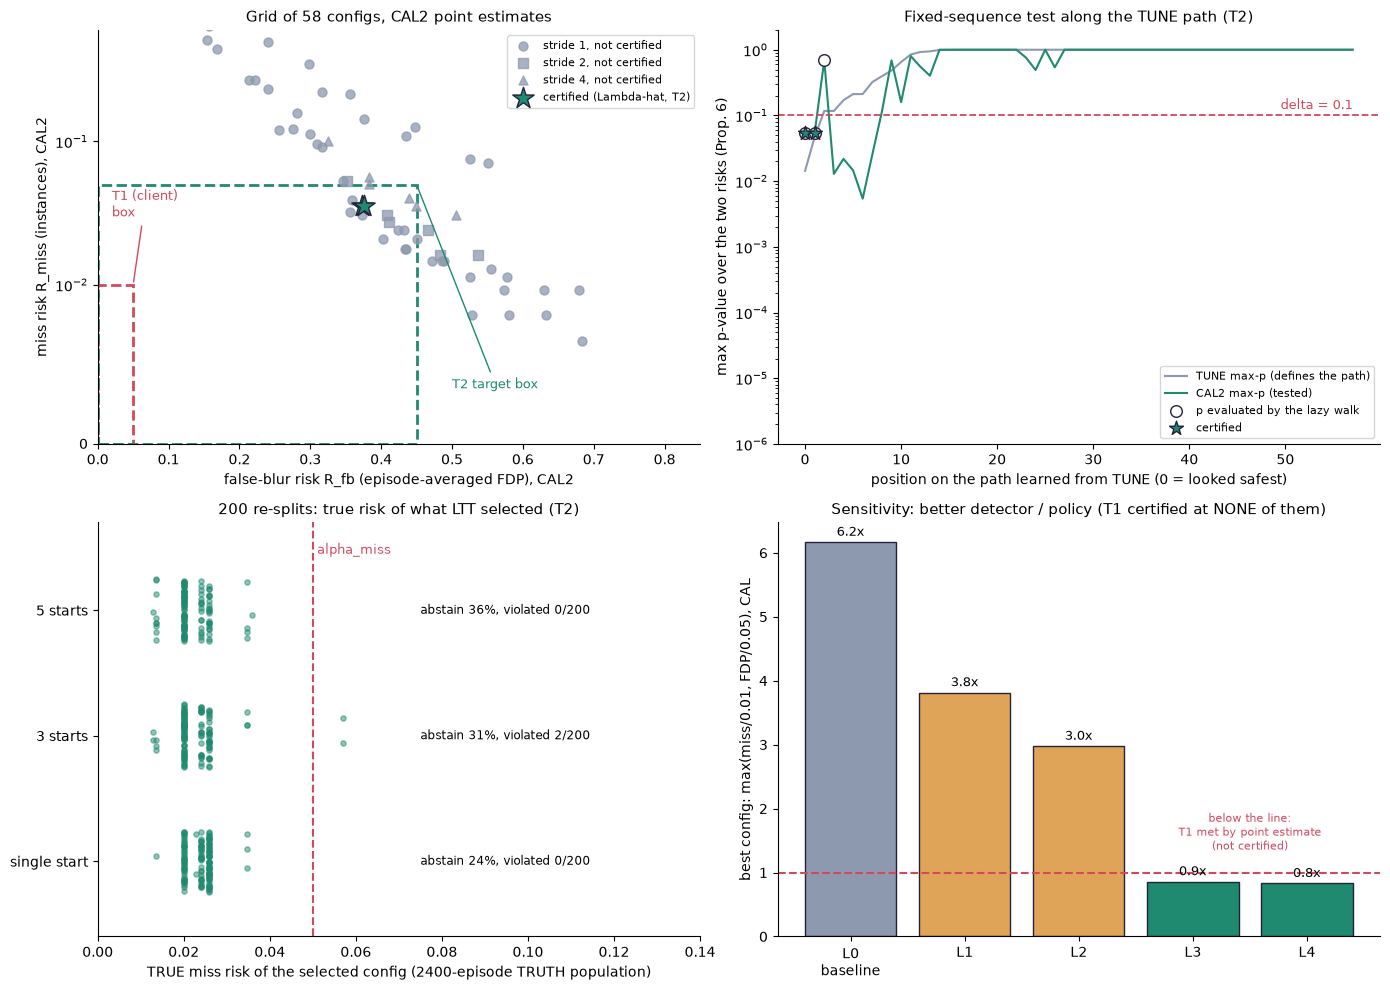

In [17]:
# VIZ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
p2 = LTT_MAIN["T2"]["p_test"]; lam2 = LTT_MAIN["T2"]["lam_hat"]

ax = axes[0, 0]
ax.add_patch(plt.Rectangle((0, 0), ALPHA_T1["fb"], ALPHA_T1["miss"], fill=False, ec=C_REQ, lw=2, ls="--"))
ax.add_patch(plt.Rectangle((0, 0), ALPHA_T2["fb"], ALPHA_T2["miss"], fill=False, ec=C_LTT, lw=2, ls="--"))
ax.annotate("T1 (client)\nbox", (ALPHA_T1["fb"], ALPHA_T1["miss"]), xytext=(0.02, 0.03), color=C_REQ, fontsize=9, arrowprops=dict(arrowstyle="-", color=C_REQ))
ax.annotate("T2 target box", (ALPHA_T2["fb"], ALPHA_T2["miss"]), xytext=(0.5, 0.0035), color=C_LTT, fontsize=9, arrowprops=dict(arrowstyle="-", color=C_LTT))
strd = np.array([k[1] for k in ALL_KEYS])
for s_, mk in ((1, "o"), (2, "s"), (4, "^")):
    m = (strd == s_) & ~lam2
    ax.scatter(p2["fb"][m], p2["miss"][m], marker=mk, s=42, color=PALETTE["stone"], alpha=0.75, label=f"stride {s_}, not certified")
ax.scatter(p2["fb"][lam2], p2["miss"][lam2], marker="*", s=260, color=C_LTT, ec=PALETTE["ink"], zorder=5, label="certified (Lambda-hat, T2)")
ax.set_yscale("symlog", linthresh=0.01); ax.set_xlim(0, 0.85); ax.set_ylim(0, 0.6)
ax.set_xlabel("false-blur risk R_fb (episode-averaged FDP), CAL2"); ax.set_ylabel("miss risk R_miss (instances), CAL2")
ax.set_title("Grid of 58 configs, CAL2 point estimates"); ax.legend(loc="upper right", fontsize=8)

ax = axes[0, 1]
x = np.arange(len(PATH))
ax.plot(x, P_TUNE["p_max"][PATH], color=PALETTE["stone"], lw=1.5, label="TUNE max-p (defines the path)")
ax.plot(x, p2["p_max"][PATH], color=C_LTT, lw=1.5, label="CAL2 max-p (tested)")
ax.axhline(DELTA, color=C_REQ, ls="--", lw=1.3); ax.text(len(PATH) - 1, DELTA * 1.25, f"delta = {DELTA}", color=C_REQ, ha="right", fontsize=9)
acc_pos = np.where(lam2[PATH])[0]; vis_pos = np.where(LTT_MAIN["T2"]["visited"][PATH])[0]
ax.scatter(vis_pos, p2["p_max"][PATH][vis_pos], s=70, color="white", ec=PALETTE["ink"], zorder=4, label="p evaluated by the lazy walk")
ax.scatter(acc_pos, p2["p_max"][PATH][acc_pos], s=110, marker="*", color=C_LTT, ec=PALETTE["ink"], zorder=5, label="certified")
ax.set_yscale("log"); ax.set_ylim(1e-6, 2); ax.set_xlabel("position on the path learned from TUNE (0 = looked safest)"); ax.set_ylabel("max p-value over the two risks (Prop. 6)")
ax.set_title("Fixed-sequence test along the TUNE path (T2)"); ax.legend(loc="lower right", fontsize=8)

ax = axes[1, 0]
rng_j = np.random.default_rng(3)
names = ["T2", "T2 multi-start J=3", "T2 multi-start J=5"]
for k, nm in enumerate(names):
    ch = RS[nm]["chosen"]; ch = ch[ch >= 0]
    tm = np.array([TRUTH_CACHE[ALL_KEYS[j]]["miss"] for j in ch])
    ax.scatter(tm, k + rng_j.uniform(-0.25, 0.25, len(tm)), s=14, alpha=0.5, color=C_LTT)
    st_ = RS_STATS.set_index("procedure").loc[nm]
    ax.text(0.075, k, f"abstain {st_['abstain_rate']:.0%}, violated {int(st_['violations'])}/{int(st_['R'])}", va="center", fontsize=8.5)
ax.axvline(ALPHA_T2["miss"], color=C_REQ, ls="--", lw=1.5); ax.text(ALPHA_T2["miss"] + 0.001, 2.45, "alpha_miss", color=C_REQ, fontsize=9)
ax.set_yticks(range(3)); ax.set_yticklabels(["single start", "3 starts", "5 starts"]); ax.set_xlim(0.0, 0.14); ax.set_ylim(-0.6, 2.7)
ax.set_xlabel(f"TRUE miss risk of the selected config ({N_TRUTH}-episode TRUTH population)"); ax.set_title(f"{R_SPLITS} re-splits: true risk of what LTT selected (T2)")

ax = axes[1, 1]
labs = ["L0\nbaseline"] + [f"L{i + 1}" for i in range(len(SENS_ROWS))]
bars = ax.bar(labs, SENS_EXCESS, color=[PALETTE["stone"]] + [C_LTT if e <= 1 else PALETTE["amber"] for e in SENS_EXCESS[1:]], ec=PALETTE["ink"])
ax.axhline(1.0, color=C_REQ, ls="--", lw=1.5); ax.text(3.5, 1.3, "below the line:\nT1 met by point estimate\n(not certified)", color=C_REQ, ha="center", va="bottom", fontsize=8)
for b, e in zip(bars, SENS_EXCESS):
    ax.text(b.get_x() + b.get_width() / 2, e + 0.1, f"{e:.1f}x", ha="center", fontsize=9)
ax.set_ylabel("best config: max(miss/0.01, FDP/0.05), CAL"); ax.set_title("Sensitivity: better detector / policy (T1 certified at NONE of them)")
plt.tight_layout(); plt.show()

#### How to read this chart

**Top left.** Each dot is one of 58 configurations at its CAL2 point estimate (x: false-blur risk, y: miss risk). Dashed boxes are the targets: small red T1, larger green T2; stars are certified. No dot lies inside T1. Several grey dots lie inside T2 yet are not certified: a point estimate inside a box is not a certificate.

**Top right.** The x-axis is the path learned on TUNE (0 looked safest); grey is TUNE max-p, green CAL2 max-p, dashed is delta. The walk accepts positions 0 and 1, fails at position 2 (p about 0.7) and stops, although later positions dip below delta. That stopping point is the pattern: path order decides what can be certified.

**Bottom left.** Each dot is one of 200 re-splits; x is the true miss risk of the selected configuration, dashed is alpha_miss. Dots left of the line are honest selections; the two right of it (3-start procedure) are violations. Abstain rates are printed.

**Bottom right.** Bars show how far the best configuration is from T1 at each detector level (1 = both targets met by point estimate). None is certified.

For the job: certification belongs to the procedure, not to a point estimate, and T1 needs both a better detector and more labelled data.

## 4. SeqCRC-style comparison: "in expectation" is not "with probability 1 - delta"

Section 3 used Learn then Test (LTT): a statement about the calibration draw, "with probability at least 1 - delta the chosen configuration's true risk is at most alpha" [P1 Thm 1, facered-q12(a)]. The second paper, SeqCRC, gives a different kind of statement. This section runs both on the **same data, the same miss target (alpha = 0.05, T2's) and the same calibration sets**, so the difference is visible instead of asserted.

**What is implemented**

- **One-parameter CRC** on the confidence threshold: lambda-hat = inf{lambda : (1/(n+1)) sum_i L_i(lambda) + B/(n+1) <= alpha} [P2 Eq. 1, facered-q4]. Here lambda = 1 - score threshold, B = 1, and the loss L_i is the miss indicator of one **face instance** (unit choice: **derived here**). The risk curve is made monotone by a running maximum, in the spirit of P2's monotonisation trick (Sec. IV-E) (**derived here**). The two-step localisation/classification stage of SeqCRC is **not implemented** (budget).
- **What the theorem says.** Theorem 1 gives E[L_test(lambda-hat)] <= alpha, where the expectation is over the calibration data *and* the test point; P2 itself warns: "There is no guarantee that (2) holds for all possible test instances" [P2 Sec. III-A, facered-q4]. So the mean true miss over many calibration draws is controlled; the probability that *one* calibration draw lands on a configuration with true miss above alpha is not. It must never be written as "recall >= 99% with confidence 1 - delta".
- **Exchangeability is the price of admission.** The proof needs the loss sequence to be "i.i.d. (by Assumption 1) and thus exchangeable" [P2 App. A-A, Step 3.c, facered-q4]. Frames within an episode and detections within a track are dependent, and none of the three papers covers video [facered-q11, facered-q12(d)]. Here the loss unit is the face instance and the resampling unit is the episode (**derived here**).
- **Precision is not controlled.** Verbatim: SeqCRC "guarantees a large enough recall but only empirically limits false positives" [P2 Sec. V-D, facered-q5]. Precision can only come from LTT's second risk (section 3).
- **Face-free frames dilute the risk.** P2 gives an image with no ground truth loss zero: "we set the loss to zero" [P2 Sec. IV-E, facered-q6]. On face-sparse footage an *episode-averaged* loss therefore understates the per-instance miss rate; the cell also runs that variant to show the size of the effect (**derived here**).

**Setup and a-priori claims (fixed before the numbers were seen).** Three procedures run on R = 300 random 950-episode calibration sets drawn from the 1,900-episode CAL+CAL2 pool; "true" risks come from the separate 2,400-episode TRUTH population: **CRC (instances)**, **LTT-1D** (miss risk only, fixed sequence from the safest threshold, exact binomial p-values, delta = 0.10) and **CRC (episode-averaged)**. Two threshold ladders were fixed by hand: *coarse* 0.600 to 0.850 in steps of 0.025 and *fine* 0.70 to 0.80 in steps of 0.01; the fine ladder was placed around where the miss curve crosses alpha, i.e. with the knowledge of section 3 (a demonstration knob, not a discovered optimum). With R = 300 and delta = 0.10 the Monte Carlo tolerance is delta + 3 SE = 0.152.

| CHECK | a-priori claim (PASS means the claim was met) |
|---|---|
| 4.1a/b | CRC's *mean* true miss <= alpha + 3 MC SE (expectation control holds) |
| 4.2a/b | CRC's per-split violation fraction **exceeds** 0.152 (written before the run, coarse ladder first) |
| 4.3a/b | LTT-1D's violation fraction <= 0.152 [P1 Thm 1] |
| 4.4 | the episode-averaged CRC's instance-level true miss is >= 1.3 x alpha on average |
| 4.5 / 4.6 | over alpha in {0.03 ... 0.07}: CRC's mean stays <= alpha and its violation exceeds 0.152 at some alpha / LTT-1D's violation stays <= 0.152 at every alpha |
| 4.7 | with a 100-episode calibration set CRC's violation exceeds 0.152 while LTT-1D's does not |

Claims 4.2 and 4.5 were the "SeqCRC violates far more than delta" story. The output decides whether that story survives; it is reported as found below.

In [18]:
# ---- 4. SeqCRC-style comparison. ONE-parameter CRC (P2 Eq. 1) on the confidence threshold; the two-step localisation stage is NOT implemented (budget; see text). ----
# Two threshold ladders (fixed a priori, not learned; everything else fixed at gap=30, pad=20, margin=0.3, stride=1):
#   'coarse' = 0.600, 0.625, ..., 0.850 (11 values)      'fine' = 0.70, 0.71, ..., 0.80 (11 values, around where the miss curve crosses alpha)
FAM_DEF = {"coarse (step 0.025)": [round(0.6 + 0.025 * i, 3) for i in range(11)], "fine (step 0.01)": [round(0.70 + 0.01 * i, 3) for i in range(11)]}
FAM_KEYS_BY = {n: [(t, 1, 30, 20, 0.3) for t in thr] for n, thr in FAM_DEF.items()}
NEW_FAM = sorted({k for ks in FAM_KEYS_BY.values() for k in ks if k not in KEY_INDEX})
t0 = time.time()
_res = eval_many([(s, k) for s in ("CAL", "CAL2") for k in NEW_FAM])
_MN = {s: to_matrices({(s, k): _res[(s, k)] for k in NEW_FAM}, [s], NEW_FAM) for s in ("CAL", "CAL2")}
def fam_matrix(s, M_grid, keys):
    out = {f: np.stack([M_grid[f][KEY_INDEX[k]] if k in KEY_INDEX else _MN[s][f][NEW_FAM.index(k)] for k in keys]) for f in ("n_miss", "n_box", "n_false", "fdp")}
    out["n_inst"] = M_grid["n_inst"]
    return out
M_FAM_BY = {n: concat_M([fam_matrix("CAL", M_CAL, ks), fam_matrix("CAL2", M_CAL2, ks)]) for n, ks in FAM_KEYS_BY.items()}      # [11 thresholds, 1,900 episodes]
E_FAM = len(M_FAM_BY["fine (step 0.01)"]["n_inst"])
print(f"two threshold families ({len(NEW_FAM)} newly evaluated configs) on the {E_FAM} CAL+CAL2 episodes in {time.time() - t0:.1f}s")

ALPHA_CRC = ALPHA_T2["miss"]                     # same miss target as T2 (a-priori)
def crc_select(M, idx, alpha, B=1.0, level="instance"):
    """CRC Eq. 1 [P2, facered-q4]: lambda-hat = inf{lambda : (1/(n+1)) sum_i L_i(lambda) + B/(n+1) <= alpha}, here lambda = 1 - thr, so the
    LARGEST thr satisfying it. Risk curve is made monotone in thr by the least non-decreasing majorant (P2 Sec. IV-E monotonization idea). Returns
    the family index; if no threshold satisfies the constraint the most conservative one (index 0) is used (convention inf(empty) = max(lambda))."""
    if level == "instance":
        n = M["n_inst"][idx].sum(); L_sum = M["n_miss"][:, idx].sum(1).astype(float)          # unit: face INSTANCE (derived here)
    else:   # episode-averaged image-style loss: episodes without faces contribute 0 (P2 Sec. IV-E edge case), so the average is DILUTED
        ni = M["n_inst"][idx]; n = len(idx)
        L_sum = (np.where(ni > 0, M["n_miss"][:, idx] / np.maximum(ni, 1), 0.0)).sum(1)
    risk = np.maximum.accumulate(L_sum)                                                       # monotone non-decreasing in thr
    ok = (risk + B) / (n + 1) <= alpha
    return int(np.where(ok)[0].max()) if ok.any() else 0

def ltt1d_select(M, idx, alpha, delta=DELTA):
    """LTT fixed sequence, MISS risk only, along the natural path (lowest threshold = safest first); exact binomial p-values, level delta.
    Returns the largest accepted threshold index (fewest false blurs), or -1 = abstain."""
    n = M["n_inst"][idx].sum(); k = M["n_miss"][:, idx].sum(1)
    acc, _ = fixed_sequence(p_binom(k, n, alpha), delta, starts=(0,))
    return int(np.where(acc)[0].max()) if acc.any() else -1

R_CRC = 300
PROC_BY, PROC_DFS = {}, []
for fam_name, keys in FAM_KEYS_BY.items():
    Mf = M_FAM_BY[fam_name]
    rng_c = np.random.default_rng(SEED + 12)
    P = {name: [] for name in ("CRC (instances)", "LTT-1D (miss only)", "CRC (episode-averaged)")}
    for r in range(R_CRC):
        idx = rng_c.permutation(E_FAM)[:N_CAL]
        P["CRC (instances)"].append(crc_select(Mf, idx, ALPHA_CRC)); P["LTT-1D (miss only)"].append(ltt1d_select(Mf, idx, ALPHA_CRC))
        P["CRC (episode-averaged)"].append(crc_select(Mf, idx, ALPHA_CRC, level="episode"))
    PROC_BY[fam_name] = {k: np.array(v) for k, v in P.items()}
    _ = truth_risks([keys[j] for v in PROC_BY[fam_name].values() for j in set(v[v >= 0].tolist())])
print(f"TRUTH risks known for {len(TRUTH_CACHE)} configs")

def proc_stats(fam_name, name, sel_idx, alpha_miss=ALPHA_CRC, alpha_fb=ALPHA_T2["fb"]):
    keys = FAM_KEYS_BY[fam_name]; ok = sel_idx >= 0
    tr = [TRUTH_CACHE[keys[j]] for j in sel_idx[ok]]
    miss = np.array([t["miss"] for t in tr]); fb = np.array([t["fb"] for t in tr]); pp = np.array([t["pooled_prec"] for t in tr])
    n_viol = int((miss > alpha_miss).sum())
    return dict(family=fam_name, procedure=name, R=len(sel_idx), abstain_rate=float(1 - ok.mean()), violations_miss=n_viol, violation_rate=n_viol / len(sel_idx),
                mean_true_miss=float(miss.mean()) if len(miss) else float("nan"), sd_true_miss=float(miss.std()) if len(miss) else float("nan"),
                mean_true_fdp=float(fb.mean()) if len(fb) else float("nan"), mean_true_pooled_precision=float(pp.mean()) if len(pp) else float("nan"),
                frac_runs_fdp_above_T2_alpha_fb=float((fb > alpha_fb).sum() / len(sel_idx)))
PROC_DF = pd.DataFrame([proc_stats(f, k, v) for f, P in PROC_BY.items() for k, v in P.items()])
# LTT-full (both risks, T2) from section 3(d): the same alpha_miss, evaluated on the miss target only for a like-for-like column
_ch = RS["T2"]["chosen"]; _sel = _ch >= 0
_tr = [TRUTH_CACHE[ALL_KEYS[j]] for j in _ch[_sel]]
LTT_FULL = dict(family="full grid", procedure="LTT-full T2 (both risks; section 3)", R=len(_ch), abstain_rate=float(1 - _sel.mean()),
                violations_miss=int(sum(t["miss"] > ALPHA_T2["miss"] for t in _tr)), violation_rate=float(sum(t["miss"] > ALPHA_T2["miss"] for t in _tr) / len(_ch)),
                mean_true_miss=float(np.mean([t["miss"] for t in _tr])), sd_true_miss=float(np.std([t["miss"] for t in _tr])),
                mean_true_fdp=float(np.mean([t["fb"] for t in _tr])), mean_true_pooled_precision=float(np.mean([t["pooled_prec"] for t in _tr])),
                frac_runs_fdp_above_T2_alpha_fb=float(sum(t["fb"] > ALPHA_T2["fb"] for t in _tr) / len(_ch)))
PROC_DF = pd.concat([PROC_DF, pd.DataFrame([LTT_FULL])], ignore_index=True)
pd.set_option("display.width", 260)
print(f"\nmiss target alpha = {ALPHA_CRC} for every row; R = {R_CRC} random {N_CAL}-episode calibration sets from the {E_FAM}-episode CAL+CAL2 pool; 'true' risks on the {N_TRUTH}-episode TRUTH population")
print(PROC_DF.round(4).to_string(index=False))
print("TRUE miss risk along each ladder (TRUTH):", {f: [round(TRUTH_CACHE[k]["miss"], 3) for k in ks if k in TRUTH_CACHE] for f, ks in FAM_KEYS_BY.items()})

tolc = 3 * np.sqrt(DELTA * (1 - DELTA) / R_CRC)
def row(fam, proc):
    return PROC_DF[(PROC_DF["family"] == fam) & (PROC_DF["procedure"] == proc)].iloc[0]
for cid, fam in (("4.1a", "coarse (step 0.025)"), ("4.1b", "fine (step 0.01)")):
    r = row(fam, "CRC (instances)"); se = r["sd_true_miss"] / np.sqrt(R_CRC)
    check(cid, f"CRC on the {fam} ladder (instance loss, P2 Thm 1): MEAN true miss of the selected config <= alpha + 3 MC SE (expectation control holds)",
          r["mean_true_miss"] <= ALPHA_CRC + 3 * se, f"mean {r['mean_true_miss']:.4f} vs alpha {ALPHA_CRC} (MC SE {se:.4f})")
for cid, fam in (("4.2a", "coarse (step 0.025)"), ("4.2b", "fine (step 0.01)")):
    r = row(fam, "CRC (instances)")
    check(cid, f"CRC on the {fam} ladder: per-split violation fraction P(true miss > alpha) EXCEEDS delta + 3 SE = {DELTA + tolc:.3f} (expectation control is not a 1-delta guarantee; "
          f"a-priori claim; the coarse ladder was run first)", r["violation_rate"] > DELTA + tolc, f"{int(r['violations_miss'])}/{R_CRC} = {r['violation_rate']:.3f}; mean true miss {r['mean_true_miss']:.4f}")
for cid, fam in (("4.3a", "coarse (step 0.025)"), ("4.3b", "fine (step 0.01)")):
    r = row(fam, "LTT-1D (miss only)")
    check(cid, f"LTT-1D on the {fam} ladder (same alpha, delta=0.10): per-split violation fraction <= delta + 3 SE (P1 Thm 1)", r["violation_rate"] <= DELTA + tolc,
          f"{int(r['violations_miss'])}/{R_CRC} = {r['violation_rate']:.3f}; abstain {r['abstain_rate']:.3f}")
r = row("fine (step 0.01)", "CRC (episode-averaged)")
check("4.4", "face-free episodes dilute an episode-averaged CRC (fine ladder): the instance-level true miss of its selected config exceeds alpha on average by >= 30% (a-priori; contract rule 7)",
      r["mean_true_miss"] >= 1.3 * ALPHA_CRC, f"mean instance-level miss {r['mean_true_miss']:.4f} vs alpha {ALPHA_CRC}; violation {r['violation_rate']:.3f}")

# ---- alpha sweep on the fine ladder (a-priori grid of targets): where does CRC's expectation control leave the per-split violation? ----
SWEEP_ALPHAS = [0.03, 0.04, 0.05, 0.06, 0.07]
fine = "fine (step 0.01)"; fkeys = FAM_KEYS_BY[fine]; Mf = M_FAM_BY[fine]
_ = truth_risks(fkeys)                                              # the whole fine ladder on TRUTH (a few extra configs)
SWEEP = []
for a in SWEEP_ALPHAS:
    rng_c = np.random.default_rng(SEED + 13)
    sel_c, sel_l = [], []
    for r in range(R_CRC):
        idx = rng_c.permutation(E_FAM)[:N_CAL]
        sel_c.append(crc_select(Mf, idx, a)); sel_l.append(ltt1d_select(Mf, idx, a))
    for proc, sel in (("CRC", np.array(sel_c)), ("LTT-1D", np.array(sel_l))):
        ok = sel >= 0
        tm = np.array([TRUTH_CACHE[fkeys[j]]["miss"] for j in sel[ok]]); tf = np.array([TRUTH_CACHE[fkeys[j]]["pooled_prec"] for j in sel[ok]])
        SWEEP.append(dict(alpha=a, procedure=proc, abstain_rate=float(1 - ok.mean()), violation_rate=float((tm > a).sum() / R_CRC),
                          mean_true_miss=float(tm.mean()) if len(tm) else float("nan"), mean_true_pooled_precision=float(tf.mean()) if len(tf) else float("nan")))
SWEEP_DF = pd.DataFrame(SWEEP)
print("\nalpha sweep (fine ladder, same 300 calibration sets per alpha):"); print(SWEEP_DF.round(4).to_string(index=False))
_c, _l = SWEEP_DF[SWEEP_DF["procedure"] == "CRC"], SWEEP_DF[SWEEP_DF["procedure"] == "LTT-1D"]
check("4.5", f"over the alpha sweep, CRC's mean true miss stays <= alpha + 3 MC SE at EVERY alpha (expectation control) while its per-split violation exceeds delta + 3 SE = {DELTA + tolc:.3f} "
      "at AT LEAST ONE alpha (a-priori claim; the sweep is the honest way to see the gap between 'in expectation' and 'with probability 1-delta')",
      bool((_c["mean_true_miss"] <= _c["alpha"] + 0.002).all() and (_c["violation_rate"] > DELTA + tolc).any()),
      f"CRC violation by alpha: {dict(zip(_c['alpha'], _c['violation_rate'].round(3)))}; mean true miss {dict(zip(_c['alpha'], _c['mean_true_miss'].round(4)))}")
check("4.6", f"over the alpha sweep, LTT-1D's per-split violation is <= delta + 3 SE = {DELTA + tolc:.3f} at EVERY alpha (P1 Thm 1; a-priori)", bool((_l["violation_rate"] <= DELTA + tolc).all()),
      f"LTT-1D violation by alpha: {dict(zip(_l['alpha'], _l['violation_rate'].round(3)))}; abstain {dict(zip(_l['alpha'], _l['abstain_rate'].round(2)))}")

# ---- calibration-size sweep at alpha = 0.05: the smaller the calibration set, the more R(lambda-hat) disperses around its mean ----
SWEEP_N = [100, 200, 400, 950]                                       # calibration episodes (~0.67 face instances per episode)
SWEEP_N_ROWS = []
for n_ep in SWEEP_N:
    rng_c = np.random.default_rng(SEED + 14)
    sel_c, sel_l = [], []
    for r in range(R_CRC):
        idx = rng_c.permutation(E_FAM)[:n_ep]
        sel_c.append(crc_select(Mf, idx, ALPHA_CRC)); sel_l.append(ltt1d_select(Mf, idx, ALPHA_CRC))
    for proc, sel in (("CRC", np.array(sel_c)), ("LTT-1D", np.array(sel_l))):
        ok = sel >= 0
        tm = np.array([TRUTH_CACHE[fkeys[j]]["miss"] for j in sel[ok]])
        SWEEP_N_ROWS.append(dict(cal_episodes=n_ep, cal_instances_approx=int(round(n_ep * Mf["n_inst"].sum() / E_FAM)), procedure=proc, abstain_rate=float(1 - ok.mean()),
                                 violation_rate=float((tm > ALPHA_CRC).sum() / R_CRC), mean_true_miss=float(tm.mean()) if len(tm) else float("nan"),
                                 sd_true_miss=float(tm.std()) if len(tm) else float("nan")))
SWEEP_N_DF = pd.DataFrame(SWEEP_N_ROWS)
print(f"\ncalibration-size sweep (fine ladder, alpha = {ALPHA_CRC}):"); print(SWEEP_N_DF.round(4).to_string(index=False))
_cn, _ln = SWEEP_N_DF[SWEEP_N_DF["procedure"] == "CRC"].set_index("cal_episodes"), SWEEP_N_DF[SWEEP_N_DF["procedure"] == "LTT-1D"].set_index("cal_episodes")
check("4.7", f"with a SMALL calibration set ({SWEEP_N[0]} episodes) CRC's per-split violation exceeds delta + 3 SE = {DELTA + tolc:.3f} while LTT-1D's stays below it "
      "(a-priori claim: expectation control disperses with small n; LTT pays with abstention instead)",
      bool(_cn.loc[SWEEP_N[0], "violation_rate"] > DELTA + tolc and _ln.loc[SWEEP_N[0], "violation_rate"] <= DELTA + tolc),
      f"CRC violation by n: {_cn['violation_rate'].round(3).to_dict()}; LTT-1D: {_ln['violation_rate'].round(3).to_dict()}; LTT-1D abstain: {_ln['abstain_rate'].round(2).to_dict()}")

two threshold families (13 newly evaluated configs) on the 1900 CAL+CAL2 episodes in 12.7s


TRUTH risks known for 30 configs

miss target alpha = 0.05 for every row; R = 300 random 950-episode calibration sets from the 1900-episode CAL+CAL2 pool; 'true' risks on the 2400-episode TRUTH population
             family                           procedure   R  abstain_rate  violations_miss  violation_rate  mean_true_miss  sd_true_miss  mean_true_fdp  mean_true_pooled_precision  frac_runs_fdp_above_T2_alpha_fb
coarse (step 0.025)                     CRC (instances) 300        0.0000               35          0.1167          0.0301        0.0089         0.3634                      0.5336                              0.0
coarse (step 0.025)                  LTT-1D (miss only) 300        0.0000                1          0.0033          0.0232        0.0031         0.3784                      0.5169                              0.0
coarse (step 0.025)              CRC (episode-averaged) 300        0.0000              300          1.0000          0.0909        0.0091         0.3124     


alpha sweep (fine ladder, same 300 calibration sets per alpha):
 alpha procedure  abstain_rate  violation_rate  mean_true_miss  mean_true_pooled_precision
  0.03       CRC        0.0000          0.0033          0.0253                      0.5286
  0.03    LTT-1D        1.0000          0.0000             NaN                         NaN
  0.04       CRC        0.0000          0.0100          0.0271                      0.5309
  0.04    LTT-1D        0.9933          0.0033          0.0361                      0.5438
  0.05       CRC        0.0000          0.1200          0.0354                      0.5414
  0.05    LTT-1D        0.6967          0.0033          0.0306                      0.5358
  0.06       CRC        0.0000          0.0833          0.0485                      0.5561
  0.06    LTT-1D        0.1467          0.0033          0.0355                      0.5417
  0.07       CRC        0.0000          0.0900          0.0608                      0.5682
  0.07    LTT-1D        0


calibration-size sweep (fine ladder, alpha = 0.05):
 cal_episodes  cal_instances_approx procedure  abstain_rate  violation_rate  mean_true_miss  sd_true_miss
          100                    66       CRC        0.0000          0.2633          0.0373        0.0180
          100                    66    LTT-1D        0.9100          0.0533          0.0493        0.0179
          200                   132       CRC        0.0000          0.2933          0.0386        0.0165
          200                   132    LTT-1D        0.8633          0.0333          0.0387        0.0147
          400                   264       CRC        0.0000          0.2300          0.0376        0.0140
          400                   264    LTT-1D        0.8033          0.0533          0.0386        0.0116
          950                   626       CRC        0.0000          0.1400          0.0360        0.0085
          950                   626    LTT-1D        0.6667          0.0067          0.0308        

**What the output says (synthetic data, R = 300 calibration sets, alpha = 0.05).**

- **Expectation control holds** (4.1a/b PASS): CRC's mean true miss is 0.0301 (coarse ladder) and 0.0364 (fine ladder), both below 0.05.
- **The "violation" claim was NOT met at the main calibration size** (4.2a, 4.2b and 4.5 are honest FAILs). CRC's per-split violation fraction is 35/300 = 0.117 on both ladders: above delta = 0.10, but inside the Monte Carlo tolerance of it (0.152), and the sweep over alpha peaks at 0.12. The ladder's true miss risks step over 0.05 between 0.043 and 0.051, so many of these violations are small overshoots. At 950 episodes SeqCRC-style calibration is *not* dramatically worse than delta.
- **LTT-1D's violation fraction is 1/300 = 0.003** (4.3a/b PASS), but that is bought with abstention: 0.000 on the coarse ladder, **0.697** on the fine ladder, and 1.00 / 0.99 / 0.70 / 0.15 / 0.003 at alpha = 0.03 / 0.04 / 0.05 / 0.06 / 0.07 (4.6 PASS). LTT answers "no certified configuration" where CRC always answers.
- **The gap opens with small calibration sets** (4.7 PASS): with 100 episodes (about 66 instances) CRC's violation is 0.263 against LTT-1D's 0.053 (abstain 0.91); at 200 / 400 / 950 episodes CRC is 0.293 / 0.230 / 0.140.
- **Face-free episodes dilute an episode-averaged loss** (4.4 PASS): the selected configuration's instance-level true miss averages 0.0862 against alpha = 0.05, and it violates in 300/300 splits.
- **Precision is nobody's win:** mean true pooled precision is 0.47 to 0.59 for every procedure, far from the client's 0.95.

Honest summary: CRC controls what it says it controls (the mean), never abstains, and is cheaper in data; LTT controls the probability, and pays with abstention that grows as the calibration set shrinks.

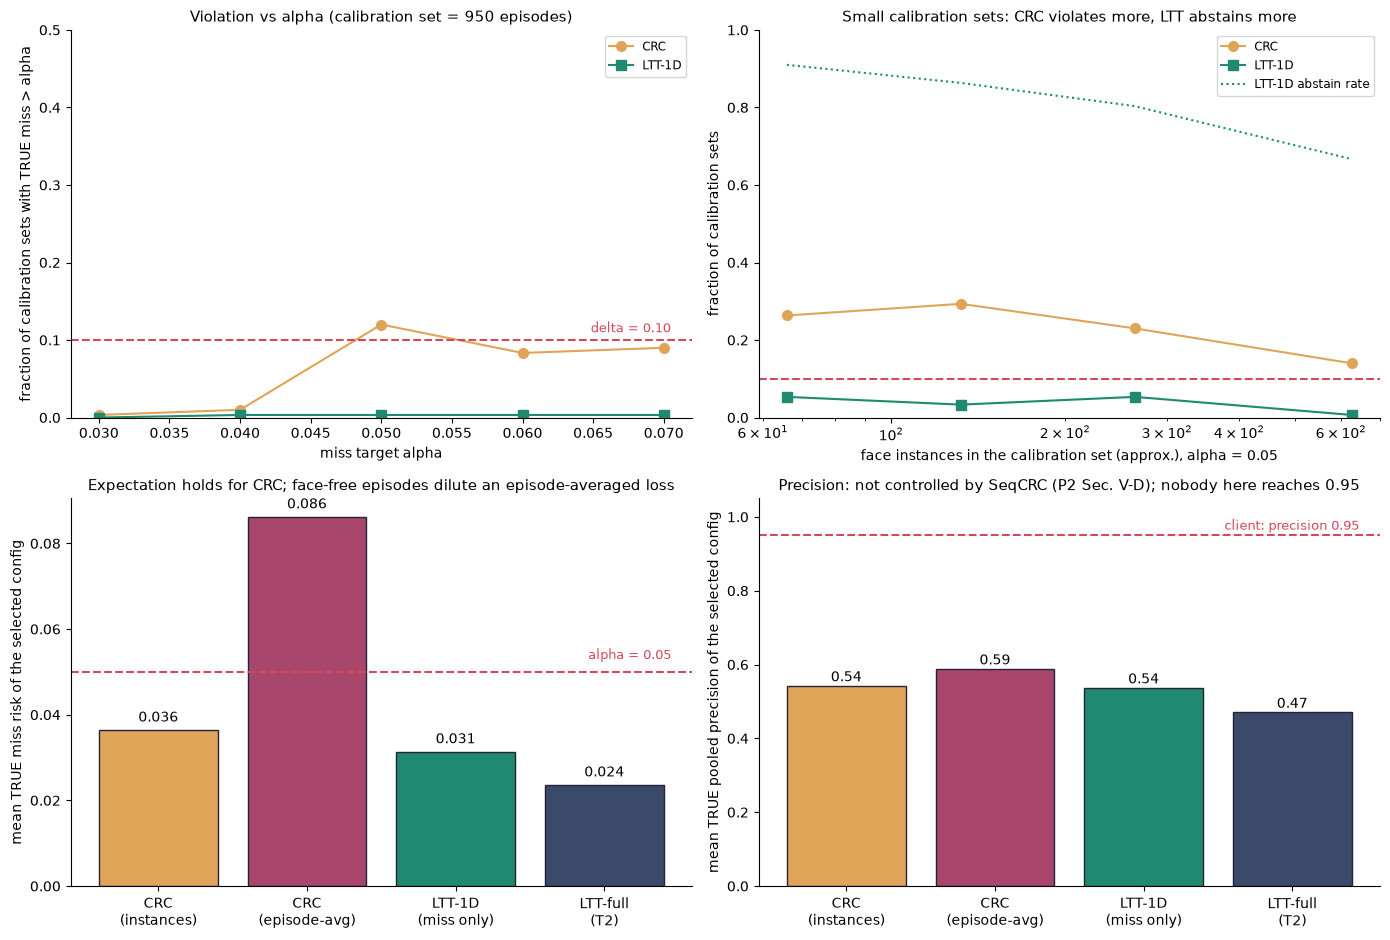

In [19]:
# VIZ
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
fine = "fine (step 0.01)"
D_ = PROC_DF[PROC_DF["family"].isin([fine, "full grid"])].set_index("procedure")
order = ["CRC (instances)", "CRC (episode-averaged)", "LTT-1D (miss only)", "LTT-full T2 (both risks; section 3)"]
cols = [C_CRC, PALETTE["berry"], C_LTT, PALETTE["slate"]]; short = ["CRC\n(instances)", "CRC\n(episode-avg)", "LTT-1D\n(miss only)", "LTT-full\n(T2)"]
tolc_ = 3 * np.sqrt(DELTA * (1 - DELTA) / R_CRC)

ax = axes[0, 0]
for proc, c_, mk in (("CRC", C_CRC, "o"), ("LTT-1D", C_LTT, "s")):
    d_ = SWEEP_DF[SWEEP_DF["procedure"] == proc]
    ax.plot(d_["alpha"], d_["violation_rate"], mk + "-", color=c_, label=proc, ms=7)
ax.axhline(DELTA, color=C_REQ, ls="--", lw=1.5); ax.text(0.0705, DELTA + 0.01, "delta = 0.10", color=C_REQ, ha="right", fontsize=9)
ax.set_xlabel("miss target alpha"); ax.set_ylabel("fraction of calibration sets with TRUE miss > alpha")
ax.set_title(f"Violation vs alpha (calibration set = {N_CAL} episodes)"); ax.set_ylim(0, 0.5); ax.legend()

ax = axes[0, 1]
for proc, c_, mk in (("CRC", C_CRC, "o"), ("LTT-1D", C_LTT, "s")):
    d_ = SWEEP_N_DF[SWEEP_N_DF["procedure"] == proc]
    ax.plot(d_["cal_instances_approx"], d_["violation_rate"], mk + "-", color=c_, label=proc, ms=7)
    if proc == "LTT-1D":
        ax.plot(d_["cal_instances_approx"], d_["abstain_rate"], ":", color=C_LTT, label="LTT-1D abstain rate")
ax.axhline(DELTA, color=C_REQ, ls="--", lw=1.5)
ax.set_xscale("log"); ax.set_xlabel(f"face instances in the calibration set (approx.), alpha = {ALPHA_CRC}"); ax.set_ylabel("fraction of calibration sets")
ax.set_title("Small calibration sets: CRC violates more, LTT abstains more"); ax.set_ylim(0, 1.0); ax.legend(fontsize=8.5)

ax = axes[1, 0]
m = [D_.loc[o, "mean_true_miss"] for o in order]
ax.bar(short, m, color=cols, ec=PALETTE["ink"])
ax.axhline(ALPHA_CRC, color=C_REQ, ls="--", lw=1.5); ax.text(3.45, ALPHA_CRC + 0.003, f"alpha = {ALPHA_CRC}", color=C_REQ, ha="right", fontsize=9)
for i, x_ in enumerate(m):
    ax.text(i, x_ + 0.002, f"{x_:.3f}", ha="center", fontsize=10)
ax.set_ylabel("mean TRUE miss risk of the selected config"); ax.set_title("Expectation holds for CRC; face-free episodes dilute an episode-averaged loss")

ax = axes[1, 1]
pp = [D_.loc[o, "mean_true_pooled_precision"] for o in order]
ax.bar(short, pp, color=cols, ec=PALETTE["ink"])
ax.axhline(0.95, color=C_REQ, ls="--", lw=1.5); ax.text(3.45, 0.965, "client: precision 0.95", color=C_REQ, ha="right", fontsize=9)
for i, x_ in enumerate(pp):
    ax.text(i, x_ + 0.012, f"{x_:.2f}", ha="center", fontsize=10)
ax.set_ylim(0, 1.05); ax.set_ylabel("mean TRUE pooled precision of the selected config")
ax.set_title("Precision: not controlled by SeqCRC (P2 Sec. V-D); nobody here reaches 0.95")
plt.tight_layout(); plt.show()

#### How to read this chart

Four panels, synthetic data; "true" risks come from the 2,400-episode TRUTH population.

- **Top left.** x = miss target alpha; y = fraction of calibration sets (950 episodes) whose selected configuration has true miss above alpha; dashed line = delta = 0.10. Orange (CRC) peaks near 0.12 at alpha = 0.05 and is 0.08 to 0.09 at 0.06 and 0.07. Green (LTT-1D) is flat near 0.003, but this hides abstention: 100% and 99% of runs at alpha = 0.03 and 0.04.
- **Top right.** x = face instances in the calibration set (log); y = fraction of calibration sets. CRC stays above delta at every size (0.26, 0.29, 0.23, 0.14); LTT-1D's violation stays near or below 0.05 and its dotted abstain rate falls from 0.91 to 0.67 as data grows. This is where the two guarantees really differ.
- **Bottom left.** Mean true miss of the selected configuration: CRC 0.036 (instances) and 0.086 (episode-averaged), LTT-1D 0.031, LTT-full 0.024, against alpha = 0.05. Only the episode-averaged bar crosses the line: face-free episodes dilute its loss.
- **Bottom right.** Mean true pooled precision, 0.47 to 0.59, all far below the client's 0.95.

For the job: rest the recall promise on a 1 - delta certificate (LTT, then the sealed audit), not on an expectation bound.

## 5. Sealed audit: pre-register, then open the labels once

Sections 3 and 4 were about *choosing* a configuration. This section asks whether a configuration that is already fixed can be **certified** on data nobody used to design it. The rule of the audit paper is blunt: the configuration, family and thresholds must be "fixed before the audit labels are observed" [P3 Thm 19, facered-q9], and reusing opened labels "violates Assumption 1, and voids the guarantee" [P3 Sec. 2.4, facered-q12].

**How the notebook enforces it.** The AUDIT split is a fresh 700-episode corpus from the same simulator, disjoint at the episode level from TUNE, CAL, CAL2 and TRUTH. The first half of the next cell writes everything that will be tested to `data/nb3/audit_prereg.json` (audit level delta = 0.05, P3's planning default [facered-q10]; the two configurations; the nested threshold family; both epsilons; the stress generator; the 45-second segment length) and appends an event to the log. Only then is the AUDIT split opened. CHECK 5.1 compares the two event-log positions.

**The two audited configurations.**
- **T2 choice**: the cheapest member of the section-3 certified set (thr 0.70, stride 1, gap 10, pad 20, margin 0.3).
- **Best-effort recall-first**: the configuration with the lowest pooled TUNE+CAL+CAL2 miss point estimate (thr 0.40, gap 10, pad 40). LTT did **not** certify it (T1 was empty), so only the audit can say anything about it.

**Five certificates, five different events** (do not merge them):

| | certificate | event it bounds | source |
|---|---|---|---|
| 5(a) | Prop. 26, Clopper-Pearson over audited face **instances** | the conditional miss rate L | [P3 Prop. 26, facered-q9] |
| 5(b) | excluded-pool missed mass, hypergeometric / binomial, on 45-s **segments** | absolute mass r of untouched segments holding a face | [P3 Thm 8, facered-q8; Thm 7, facered-q11]; segments **derived here** |
| 5(c) | fixed-sequence walk over a pre-registered nested family | which prefix passes one epsilon at full delta | [P3 Thm 19, facered-q9] |
| 5(d) | stress-test cluster bounds | escape probability under one *declared* perturbation generator | [P3 Defs 27-28, Thm 29, facered-q9] |
| 5(e) | pooled precision with an episode-cluster bootstrap | the client's precision | **bootstrap, not a paper guarantee** |

### 5(a) Prop. 26: the only basis for a recall claim

Under the audit design of P3 Thm 24, with Q audited positives of which C are missed, "with probability at least 1 - delta, L(g_J) <= U_Q(C_J, delta)" [P3 Prop. 26, facered-q9]. Here the audited positives are face **instances** (tracks), so U is a bound on the client's per-instance miss rate and 1 - U is a recall lower bound. This is the only certificate in the section that speaks to the 99% claim; the missed-mass bound of 5(b) does not, because "the implied bound is L(g) <= 0.5 ... which is not a high-recall guarantee" when faces are rare [P3 Remark 9, facered-q11].

A-priori checks: **5.1** the registration precedes the opening; **5.2** the audit is consistent with the LTT certificate for the T2 choice, i.e. the one-sided 95% Clopper-Pearson *lower* bound on its miss rate does not exceed T2's alpha_miss (a violation would mean the audit contradicts section 3). The client's 99% claim is *not* a pass/fail check: the cell reports whether U <= 0.01, whichever way it falls.

Paper numbers stay separate from these: P3's worked example is N = 100,000 with U_300(0, 0.025) = 0.01222 and M_U = 853 [P3 Sec. 8, facered-q8]; nothing below is meant to reproduce them.

In [20]:
# ---- 5. SEALED AUDIT. FIRST fix the configurations, write them to disk, and only then touch AUDIT labels [P3 Assumption 1, facered-q7] ----
DELTA_AUDIT = 0.05                                   # audit level (P3's planning table uses delta = 0.05)
# (1) the T2 choice from section 3: cheapest config in Lambda-hat on CAL2 (ties -> fewest false blurs on CAL2)
_lam2, _pt2 = LTT_MAIN["T2"]["lam_hat"], LTT_MAIN["T2"]["p_test"]
J_T2 = pick_cheapest(_lam2, _pt2)
# (2) a best-effort, RECALL-FIRST config for the client's 99% claim: lowest pooled TUNE+CAL+CAL2 miss point estimate (ties -> higher pooled precision). It is
#     NOT certified by LTT (T1 was empty): the audit is the only thing that could support a claim about it.
_pool_miss = risk_summary(M_POOL, np.arange(E_POOL))
J_BEST = int(np.lexsort((-_pool_miss["pooled_prec"], _pool_miss["miss"]))[0])
NESTED_THR = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]           # Thm 19 family: everything but the threshold fixed (gap 30, pad 20, margin 0.3)
NESTED_KEYS = [(t, 1, 30, 20, 0.3) for t in NESTED_THR]
EPS_SEG = 0.01                                       # the single pre-registered epsilon for Thm 19 (absolute missed mass over 45-s segments; derived here)
EPS_INST = ALPHA_T2["miss"]                          # pre-registered epsilon for the INSTANCE-level twin of Thm 19 (derived here) = T2's alpha_miss
SEG_SECONDS, N0_SAMPLE, N_PI_SAMPLE = 45, 300, 300
STRESS_BASES = [0.5, 0.0, -0.5]                      # stress-test generator A (declared): detector base logit lowered by 0.5/1.0/1.5 (poor light, motion blur, mirror-like)
AUDIT_REG = dict(delta_audit=DELTA_AUDIT, T2_config=dict(key=list(ALL_KEYS[J_T2])), best_effort_config=dict(key=list(ALL_KEYS[J_BEST])),
                 nested_family=[list(k) for k in NESTED_KEYS], eps_segment_missed_mass=EPS_SEG, eps_instance_miss_rate=EPS_INST, segment_seconds=SEG_SECONDS,
                 n0_excluded_sample=N0_SAMPLE, n_prevalence_sample=N_PI_SAMPLE, stress_generator_base_logit_shifts=[b - 1.0 for b in STRESS_BASES],
                 audit_episodes=int(len(CORP["AUDIT"]["episodes"])), written_at=time.strftime("%Y-%m-%d %H:%M:%S"))
(NB3_DIR / "audit_prereg.json").write_text(json.dumps(AUDIT_REG, indent=2))
log_event("audit configuration, family, epsilon and stress generator written to disk (AUDIT labels still unopened)")
print(json.dumps(AUDIT_REG, indent=2))
print(f"\nT2 choice : {describe_key(ALL_KEYS[J_T2])}   (CAL2: miss {_pt2['miss'][J_T2]:.4f}, episode-FDP {_pt2['fb'][J_T2]:.3f})")
print(f"best-effort: {describe_key(ALL_KEYS[J_BEST])}   (pooled TUNE+CAL+CAL2 miss {_pool_miss['miss'][J_BEST]:.4f}, pooled precision {_pool_miss['pooled_prec'][J_BEST]:.3f})")

# ---- open the AUDIT split: labels are touched for the first time below ----
log_event("AUDIT split opened")
register_work("AUDIT", CORP["AUDIT"], DETS["AUDIT"])
def audit_eval(corpus, dets, pc):
    bb = run_pipeline(dets, corpus, pc).reset_index(drop=True)
    res = evaluate(corpus, bb)
    return bb, res
AUD = {}
for name, j in (("T2", J_T2), ("BEST", J_BEST)):
    bb, res = audit_eval(CORP["AUDIT"], DETS["AUDIT"], pc_of(ALL_KEYS[j]))
    pi = res["per_instance"].sort_values("track_id").reset_index(drop=True)
    AUD[name] = dict(key=ALL_KEYS[j], bb=bb, res=res, per_instance=pi, Q=len(pi), C=int(pi["instance_missed"].sum()),
                     loss=episode_losses(CORP["AUDIT"], DETS["AUDIT"], pc_of(ALL_KEYS[j])))
# ---- (a) Prop. 26: conditional miss-rate certificate over audited face INSTANCES [P3 Prop. 26, facered-q9] ----
rows = []
for name, a in AUD.items():
    Q, C = a["Q"], a["C"]
    U = float(cp_upper(C, Q, DELTA_AUDIT)); Lo = float(cp_lower(C, Q, DELTA_AUDIT))
    rate = C / Q
    q_need = next((q for q in range(50, 20001) if cp_upper(int(round(rate * q)), q, DELTA_AUDIT) <= EPS_TARGET), None) if rate < EPS_TARGET else None
    a.update(U=U, L_low=Lo)
    rows.append(dict(config=name, key=describe_key(a["key"]), Q=Q, C_missed=C, miss_rate=round(rate, 4), U_Q_C_delta=round(U, 4),
                     certified_recall_lower_bound=round(1 - U, 4), claims_recall_99=bool(U <= EPS_TARGET),
                     Q_needed_at_this_miss_rate=(q_need if q_need else "never (rate >= 1%)" if rate >= EPS_TARGET else "n/a")))
P26_DF = pd.DataFrame(rows)
pd.set_option("display.width", 260); pd.set_option("display.max_colwidth", 55)
print("\n(a) Prop. 26 on the sealed AUDIT (delta = 0.05):"); print(P26_DF.to_string(index=False))
print(f"    Section 2 table: certifying L <= 1% needs Q >= {SIZING_DF['Q_min_delta0.05'].tolist()[:3]} audited instances for C = 0, 1, 2 misses; this audit has Q = {Q_AUDIT}.")
_t2 = AUD["T2"]
_names = [e[1] for e in EVENTS]
_i_reg = next(i for i, n_ in enumerate(_names) if n_.startswith("audit configuration")); _i_open = _names.index("AUDIT split opened")
check("5.1", "pre-registration order: the audit configs / family / epsilon / stress generator were written to disk BEFORE the AUDIT split was opened (event log)",
      _i_reg < _i_open, f"event {_i_reg} (registered) < event {_i_open} (audit opened); log: {[n_[:22] for n_ in _names]}")
check("5.2", "the audit is consistent with the LTT claim for the T2 choice: the one-sided 95% Clopper-Pearson LOWER bound on its miss rate does not exceed T2's alpha_miss "
      "(a-priori; a violation would mean the audit contradicts the certificate)", _t2["L_low"] <= ALPHA_T2["miss"],
      f"audit miss {_t2['C']}/{_t2['Q']} = {_t2['C'] / _t2['Q']:.4f}, lower bound {_t2['L_low']:.4f} vs alpha {ALPHA_T2['miss']}")

{
  "delta_audit": 0.05,
  "T2_config": {
    "key": [
      0.7,
      1,
      10,
      20,
      0.3
    ]
  },
  "best_effort_config": {
    "key": [
      0.4,
      1,
      10,
      40,
      0.3
    ]
  },
  "nested_family": [
    [
      0.4,
      1,
      30,
      20,
      0.3
    ],
    [
      0.45,
      1,
      30,
      20,
      0.3
    ],
    [
      0.5,
      1,
      30,
      20,
      0.3
    ],
    [
      0.55,
      1,
      30,
      20,
      0.3
    ],
    [
      0.6,
      1,
      30,
      20,
      0.3
    ],
    [
      0.65,
      1,
      30,
      20,
      0.3
    ],
    [
      0.7,
      1,
      30,
      20,
      0.3
    ],
    [
      0.75,
      1,
      30,
      20,
      0.3
    ],
    [
      0.8,
      1,
      30,
      20,
      0.3
    ],
    [
      0.85,
      1,
      30,
      20,
      0.3
    ],
    [
      0.9,
      1,
      30,
      20,
      0.3
    ]
  ],
  "eps_segment_missed_mass": 0.01,
  "eps_instance_miss_rate"


(a) Prop. 26 on the sealed AUDIT (delta = 0.05):
config                                        key   Q  C_missed  miss_rate  U_Q_C_delta  certified_recall_lower_bound  claims_recall_99 Q_needed_at_this_miss_rate
    T2 thr=0.70 stride=1 gap=10 pad=20 margin=0.3 515        10     0.0194       0.0327                        0.9673             False         never (rate >= 1%)
  BEST thr=0.40 stride=1 gap=10 pad=40 margin=0.3 515         2     0.0039       0.0122                        0.9878             False                        628
    Section 2 table: certifying L <= 1% needs Q >= [299, 473, 628] audited instances for C = 0, 1, 2 misses; this audit has Q = 515.
CHECK 5.1: pre-registration order: the audit configs / family / epsilon / stress generator were written to disk BEFORE the AUDIT split was opened (event log) -> event 4 (registered) < event 5 (audit opened); log: ['targets T1/T2 fixed fr', 'CAL split opened', 'T2-v2 rule fixed from ', 'CAL2 split opened', 'audit configuration,

**What the output says.** Pre-registration precedes opening (5.1 PASS). On Q = 515 audited face instances at delta = 0.05:

| config | missed C | miss rate | U_Q(C, 0.05) | recall lower bound | U <= 1%? |
|---|---|---|---|---|---|
| T2 choice | 10 | 0.0194 | 0.0327 | 0.9673 | **no** |
| best-effort recall-first | 2 | 0.0039 | 0.0122 | 0.9878 | **no** |

- **The client's 99% recall is not certified for either configuration.** The best-effort configuration is close (0.9878), but its bound is above 1%. At its observed rate of 2/515, the "Q needed" column says about 628 audited instances would be enough; that is a larger audit, not a better bound. The T2 choice, at 1.9% observed, can never certify 1% at any Q.
- **T2's own target is corroborated**: its lower confidence bound on the miss rate is 0.0106, below alpha_miss = 0.05 (5.2 PASS), and U = 0.0327 is also below 0.05. The audit does not contradict the section-3 certificate.
- Section 2's sizing table already said what to expect: certifying a 1% miss rate needs Q >= 299, 473 or 628 audited instances for C = 0, 1 or 2 misses; this audit has Q = 515.
- The best-effort configuration buys its recall with false blur (pooled precision in 5(e)).

### 5(b) Excluded-pool missed-mass certificate: a real bound on a weaker event

**Claim.** Labels on the *excluded* pool (what the pipeline left untouched) bound the absolute missed mass r(g); labels on the included pool cannot: "Included-pool labels alone do not bound missed mass" [P3 Prop. 3, facered-q12]. Two forms: the finite-corpus hypergeometric inversion M_U [P3 Thm 8, facered-q8] and the binomial bound r(g) <= p0 * U_n0(K0, delta) [P3 Thm 7 / Cor. 16, facered-q11, facered-q9], with delta split as delta0 + delta1 [P3 Thm 10, facered-q8].

**Items (derived here).** Fixed 45-second segments of the audit episodes. A segment is *included* if the pipeline drew at least one blur box in it, *excluded* otherwise; it is *positive* if it holds at least one visible face frame. The unit is a segment, not an instance, and segments of the same face track are **dependent**. Theorem 8 samples without replacement from a fixed finite pool, so it is valid by design; Theorem 7 assumes i.i.d. items, so its coverage under dependence is *measured* here rather than assumed.

**What must not be inferred.** An absolute missed-mass bound is not recall. Converting needs a certified lower bound a on the prevalence pi: Recall >= 1 - r/a [P3 Remark 9, facered-q9/q11]. The paper's own warning number: pi = 0.01 and r <= 0.005 give recall >= 0.5 only [P3 Remark 9, facered-q11] (paper number). The cell computes this conversion from a separate 300-segment prevalence sample (delta1 = 0.025).

**Coverage study on the simulator.** The sealed AUDIT labels are not used again. On the TRUTH population a deliberately weak configuration (thr 0.95) is used so the excluded pool contains some positive segments at all. A-priori checks: **5.3** Thm 8 coverage over 3,000 repeated n0 = 300 draws is at least 1 - delta0 - 3 SE = 0.9664; **5.4** Thm 7 coverage of the population excluded-pool rate, when audited segments come from only 600 episodes (dependent segments), is at least 0.956. A FAIL on 5.4 would mean clustering breaks the i.i.d. assumption, and it would be reported as such.

In [21]:
# ---- (b) Excluded-pool missed-mass certificate (Thm 7 binomial / Thm 8 hypergeometric) [P3 Sec. 4.1-4.2, facered-q7] ----
# ITEMS (derived here): fixed-length 45-second video segments of the audit episodes. g(item) = 1 if the pipeline drew >= 1 blur box in the segment, else 0
# (the EXCLUDED pool: segments the pipeline left completely untouched). Y(item) = 1 if the segment contains >= 1 visible face-to-redact frame. A positive
# excluded segment is therefore a segment with an unredacted face frame. Segments of the same face track / episode are DEPENDENT (see the coverage study below).
SEG = SEG_SECONDS * 30
def segment_items(corpus: dict, bb: pd.DataFrame) -> pd.DataFrame:
    """One row per (episode, segment): n_seg items; `has_box` (g=1), `positive` (segment holds >= 1 visible face-to-redact GT frame)."""
    ep = corpus["episodes"]
    n_seg = np.ceil(ep["duration_frames"].to_numpy() / SEG).astype(int)
    items = pd.DataFrame(dict(episode_id=np.repeat(ep["episode_id"].to_numpy(), n_seg), seg=np.concatenate([np.arange(k) for k in n_seg])))
    cache = corpus["_gt_all"][1]
    face = corpus["tracks"].loc[corpus["tracks"]["is_face_to_redact"], "track_id"]
    gt = cache[cache["track_id"].isin(face)]
    pos = gt.assign(seg=gt["frame"] // SEG)[["episode_id", "seg"]].drop_duplicates().assign(positive=True)
    box = bb.assign(seg=bb["frame"] // SEG)[["episode_id", "seg"]].drop_duplicates().assign(has_box=True) if len(bb) else pd.DataFrame(columns=["episode_id", "seg", "has_box"])
    items = items.merge(pos, on=["episode_id", "seg"], how="left").merge(box, on=["episode_id", "seg"], how="left")
    items["positive"] = items["positive"].fillna(False).astype(bool); items["has_box"] = items["has_box"].fillna(False).astype(bool)
    return items

def hypergeom_upper(K0, N0, n0, alpha):
    """M_U(K0, alpha; N0, n0) = max{m in [0,N0] : P(Hypergeom(N0, m, n0) <= K0) >= alpha} [P3 Thm 8, facered-q7]; binary search (cdf is non-increasing in m)."""
    lo, hi = K0, N0
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if stats.hypergeom.cdf(K0, N0, mid, n0) >= alpha:
            lo = mid
        else:
            hi = mid - 1
    return lo

ITEMS = segment_items(CORP["AUDIT"], AUD["T2"]["bb"])
N_ALL, N_EXC = len(ITEMS), int((~ITEMS["has_box"]).sum())
EXC = ITEMS[~ITEMS["has_box"]].reset_index(drop=True)
M0_TRUE, PI_HAT = int(EXC["positive"].sum()), float(ITEMS["positive"].mean())
print(f"AUDIT segments (45 s): N = {N_ALL} items; excluded pool (no blur box drawn) N0 = {N_EXC} ({N_EXC / N_ALL:.1%}); positives in excluded pool M0 = {M0_TRUE} "
      f"(eta = {M0_TRUE / max(N_EXC, 1):.4f}, r = M0/N = {M0_TRUE / N_ALL:.4f}); face-holding segments overall: {PI_HAT:.3f} of all segments")

delta0 = delta1 = DELTA_AUDIT / 2                 # delta split between the missed-mass bound and the prevalence lower bound (union bound)
rng_b = np.random.default_rng(SEED + 21)
draw = rng_b.choice(N_EXC, size=N0_SAMPLE, replace=False)                          # n0 segments uniformly WITHOUT replacement from the excluded pool
K0 = int(EXC["positive"].to_numpy()[draw].sum())
M_U = hypergeom_upper(K0, N_EXC, N0_SAMPLE, delta0)
U_bin = float(cp_upper(K0, N0_SAMPLE, delta0))
r_hyper, r_binom = M_U / N_ALL, (N_EXC / N_ALL) * U_bin
print(f"\naudit sample: n0 = {N0_SAMPLE} excluded segments labelled, K0 = {K0} positives")
print(f"  Thm 8 (hypergeometric, finite pool): M0 <= M_U = {M_U}  =>  r(g) <= {r_hyper:.4f}   [true r = {M0_TRUE / N_ALL:.4f}]")
print(f"  Thm 7 (binomial): eta <= U_300({K0}, {delta0}) = {U_bin:.4f}  =>  r(g) <= p0 * U = {r_binom:.4f}")
# Remark 9: absolute missed mass is NOT recall. Recall >= 1 - u/a needs a certified lower bound a on the prevalence pi; here from n = 300 uniformly drawn segments.
draw_pi = rng_b.choice(N_ALL, size=N_PI_SAMPLE, replace=False)
K_pi = int(ITEMS["positive"].to_numpy()[draw_pi].sum())
a_pi = float(cp_lower(K_pi, N_PI_SAMPLE, delta1))
recall_seg_lb = max(0.0, 1 - r_hyper / a_pi)
print(f"  Remark 9: prevalence sample K = {K_pi}/{N_PI_SAMPLE}, certified lower bound a = L(K, {delta1}) = {a_pi:.3f}; implied SEGMENT-level recall >= 1 - r_bound/a = {recall_seg_lb:.3f} "
      f"(joint confidence {1 - delta0 - delta1:.3f}); true segment recall = {1 - M0_TRUE / max(int(ITEMS['positive'].sum()), 1):.3f}")
print(f"  So an absolute missed-mass bound of {r_hyper:.3f} looks small, but with {PI_HAT:.0%} of segments holding a face it certifies only ~{recall_seg_lb:.0%} segment recall; "
      f"on real footage where faces are rarer (P3 Remark 9: pi = 0.01, r <= 0.005 -> recall >= 0.5) it would certify far less. It is NOT the client's instance-recall claim.")

print(f"\nWhy is K0 = 0? In this pipeline a face track almost always draws SOME box in every 45-s segment it lives in (bridging + padding around any detection);\n"
      f"its misses are frames left uncovered INSIDE segments that do contain boxes (dropouts, box too small). Those live in the INCLUDED pool, where P3 Prop. 3\n"
      f"says labels give no missed-mass bound, and where only the instance-level Prop. 26 audit of (a) speaks. The excluded-pool audit certifies a different, easier event.")

# --- Monte Carlo coverage on the SIMULATOR (TRUTH population; the sealed AUDIT labels are not used again) ---
# For the excluded pool to contain positives at all, the coverage study uses a deliberately WEAK config (thr 0.95): a face whose whole track stays
# under the threshold draws no box, so its segments are excluded AND positive.
WEAK_KEY = (0.95, 1, 30, 20, 0.3)
t0 = time.time()
_tr_items = []
for _n, _c in TRUTH_CH.items():
    _it = segment_items(_c, run_pipeline(TRUTH_CH_DET[_n], _c, pc_of(WEAK_KEY)))
    _it["ep_key"] = _n + "_" + _it["episode_id"].astype(str)
    _tr_items.append(_it)
TR_ITEMS = pd.concat(_tr_items, ignore_index=True)
exc_mask = ~TR_ITEMS["has_box"].to_numpy(); pos_all = TR_ITEMS["positive"].to_numpy()
N_TR, N0_TR = len(TR_ITEMS), int(exc_mask.sum()); M0_TR = int((pos_all & exc_mask).sum()); eta_pop = M0_TR / N0_TR
print(f"\nTRUTH ({N_TRUTH} episodes, {N_TR} segments) with the weak config {describe_key(WEAK_KEY)}: excluded pool {N0_TR} ({N0_TR / N_TR:.1%}), positives M0 = {M0_TR}, "
      f"eta_pop = {eta_pop:.4f}, r = {M0_TR / N_TR:.4f}  [{time.time() - t0:.1f}s]")
R_MC = 3000
pos_exc = pos_all[exc_mask]
# (i) design-based (Thm 8): repeat the n0-draw on the FIXED finite excluded pool; valid by the sampling design whatever the dependence between segments
K_mc = rng_b.hypergeometric(M0_TR, N0_TR - M0_TR, N0_SAMPLE, size=R_MC)
_MU = {int(k): hypergeom_upper(int(k), N0_TR, N0_SAMPLE, delta0) for k in np.unique(K_mc)}
cov_thm8 = float(np.mean([M0_TR <= _MU[int(k)] for k in K_mc]))
tol_mc = 3 * np.sqrt(delta0 * (1 - delta0) / R_MC)
check("5.3", f"Thm 8 (hypergeometric) coverage on the finite TRUTH excluded pool over {R_MC} repeated draws of n0={N0_SAMPLE}: P(M0 <= M_U) >= 1 - delta0 - 3 SE = "
      f"{1 - delta0 - tol_mc:.4f} (a-priori)", cov_thm8 >= 1 - delta0 - tol_mc, f"coverage {cov_thm8:.4f} (true M0 = {M0_TR}, typical M_U = {int(np.median(list(_MU.values())))})")
# (ii) population-level Thm 7 with DEPENDENT segments: each replicate audit sees only E_SUB = 600 episodes (random subset), n0 = N0_POP = 1000 excluded segments from them
uniq_ep, ep_inv = np.unique(TR_ITEMS["ep_key"].to_numpy(), return_inverse=True)
by_ep_exc = [np.where((ep_inv == e) & exc_mask)[0] for e in range(len(uniq_ep))]
R_POP, E_SUB, N0_POP = 600, 600, 1000
hits = []
for _ in range(R_POP):
    sub = rng_b.choice(len(uniq_ep), size=E_SUB, replace=False)
    pool = np.concatenate([by_ep_exc[e] for e in sub])
    take = rng_b.choice(pool, size=min(N0_POP, len(pool)), replace=False)
    hits.append(eta_pop <= float(cp_upper(int(pos_all[take].sum()), len(take), delta0)))
cov_thm7 = float(np.mean(hits)); tol_p = 3 * np.sqrt(delta0 * (1 - delta0) / R_POP)
print(f"Thm 7 (binomial, i.i.d. items assumed) on DEPENDENT segments: audits of {N0_POP} excluded segments from {E_SUB}-episode subsets: "
      f"coverage of eta_pop <= U = {cov_thm7:.4f} (nominal {1 - delta0:.3f})")
check("5.4", f"Thm 7 binomial coverage of the population excluded-pool rate when the audited segments come from only {E_SUB} episodes (dependent segments; weak config), over {R_POP} "
      f"replicate audits: >= 1 - delta0 - 3 SE = {1 - delta0 - tol_p:.3f} (a-priori; an honest FAIL would mean clustering breaks the i.i.d. assumption)",
      cov_thm7 >= 1 - delta0 - tol_p, f"coverage {cov_thm7:.4f}")

AUDIT segments (45 s): N = 4096 items; excluded pool (no blur box drawn) N0 = 3244 (79.2%); positives in excluded pool M0 = 0 (eta = 0.0000, r = M0/N = 0.0000); face-holding segments overall: 0.130 of all segments

audit sample: n0 = 300 excluded segments labelled, K0 = 0 positives
  Thm 8 (hypergeometric, finite pool): M0 <= M_U = 37  =>  r(g) <= 0.0090   [true r = 0.0000]
  Thm 7 (binomial): eta <= U_300(0, 0.025) = 0.0122  =>  r(g) <= p0 * U = 0.0097
  Remark 9: prevalence sample K = 42/300, certified lower bound a = L(K, 0.025) = 0.103; implied SEGMENT-level recall >= 1 - r_bound/a = 0.912 (joint confidence 0.950); true segment recall = 1.000
  So an absolute missed-mass bound of 0.009 looks small, but with 13% of segments holding a face it certifies only ~91% segment recall; on real footage where faces are rarer (P3 Remark 9: pi = 0.01, r <= 0.005 -> recall >= 0.5) it would certify far less. It is NOT the client's instance-recall claim.

Why is K0 = 0? In this pipeline a face trac


TRUTH (2400 episodes, 13959 segments) with the weak config thr=0.95 stride=1 gap=30 pad=20 margin=0.3: excluded pool 11958 (85.7%), positives M0 = 64, eta_pop = 0.0054, r = 0.0046  [1.9s]
CHECK 5.3: Thm 8 (hypergeometric) coverage on the finite TRUTH excluded pool over 3000 repeated draws of n0=300: P(M0 <= M_U) >= 1 - delta0 - 3 SE = 0.9664 (a-priori) -> coverage 1.0000 (true M0 = 64, typical M_U = 400) -> PASS


Thm 7 (binomial, i.i.d. items assumed) on DEPENDENT segments: audits of 1000 excluded segments from 600-episode subsets: coverage of eta_pop <= U = 0.9983 (nominal 0.975)
CHECK 5.4: Thm 7 binomial coverage of the population excluded-pool rate when the audited segments come from only 600 episodes (dependent segments; weak config), over 600 replicate audits: >= 1 - delta0 - 3 SE = 0.956 (a-priori; an honest FAIL would mean clustering breaks the i.i.d. assumption) -> coverage 0.9983 -> PASS


**What the output says (synthetic AUDIT, T2 configuration).**

- 4,096 segments; 3,244 (79.2%) are excluded, and **none of them contains a face** (M0 = 0). The 300-segment audit sample finds K0 = 0.
- Certified missed mass: Thm 8 gives r <= 37/4,096 = **0.0090**, Thm 7 gives r <= p0 * U = **0.0097**, both under 1%.
- But only 13.0% of segments hold a face. The prevalence sample (42 of 300) gives a = 0.103, so the implied **segment-level recall is >= 0.912**, not 99%. True segment recall here is 1.000; the bound is loose, not the pipeline.
- Why K0 = 0: a face track almost always draws some box in every 45-s segment it lives in (bridging and padding), so its misses are uncovered *frames inside included segments*. Those belong to the included pool, where labels give no missed-mass bound (P3 Prop. 3), and only Prop. 26 in 5(a) speaks to them. This certificate is about a different, easier event than the client's.

**Coverage (weak configuration on TRUTH).** Thm 8: coverage 1.0000 against a threshold of 0.9664 (5.3 PASS). Thm 7 on dependent segments: 0.9983 against 0.956 (5.4 PASS); nominal 0.975. Read these with care: with a true excluded-pool rate of 0.0054, even K0 = 0 gives an upper bound above the truth, so coverage saturates near 1 and the test is not sharp. It shows the bounds were not broken by segment dependence *in this simulator*, not that dependence is harmless.

### 5(c) Fixed-sequence certification along a pre-registered nested family (Thm 19)

**Claim.** If the component detectors, the cut points and the target epsilon are "fixed before the audit labels are observed", test the prefixes "in the fixed order" g_M, g_(M-1), ..., g_1, stop at the first failure, and return the last prefix that passed; then with probability at least 1 - delta either nothing is returned or the returned prefix satisfies r(g) <= epsilon [P3 Thm 19, facered-q9]. Each test runs at the **full** level delta: no delta/M union-bound penalty, at the price of a single pre-registered epsilon and no simultaneous bounds for the other prefixes [P3 Sec. 4.8, facered-q9].

**Family (pre-registered in the JSON before the audit was opened).** The score threshold from 0.40 (g_M, most inclusive) to 0.90 (g_1, least inclusive), 11 members, everything else fixed (gap 30, pad 20, margin 0.3, stride 1). The theorem needs the prefixes to be **nested** (E_M contained in ... contained in E_1). The cell measures whether the pipeline really is nested, on the audit itself.

**Two versions, kept apart.**
- **Segment-mass version, as stated in the paper**: pass_m = the Thm 8 bound on the excluded pool of prefix m is at most epsilon_seg = 0.01, with n_m = 300 fresh draws per prefix.
- **Instance-level twin (derived here)**: the same walk at the same delta, with pass_m = [U_Q(C_m, delta) <= epsilon_inst], where epsilon_inst = 0.05 is T2's alpha_miss, pre-registered. This is Prop. 26 inside a Thm 19 walk. It is **not** stated in the paper. The cell also reports where the walk would stop with a delta/M union bound, to show what "no penalty" is worth.

**A-priori checks.** **5.5** nesting is exact: over the 10 threshold steps no audited instance is missed at a lower threshold yet covered at a higher one, and no segment is excluded at a lower threshold yet boxed at a higher one (zero violations required; otherwise the nesting is only approximate and the theorem's assumption is only approximately met). **5.6** the audited instance miss rate is non-decreasing along the family.

In [22]:
# ---- (c) Thm 19: fixed-sequence certification along a PRE-REGISTERED nested family [P3 Sec. 4.8, Thm 19, facered-q9] ----
# Family: score threshold 0.40 ... 0.90 (11 prefixes), everything else fixed. g_1 = thr 0.90 (least inclusive, largest excluded pool), g_M = thr 0.40 (most inclusive).
# Order of testing (paper): g_M, g_{M-1}, ..., g_1; stop at the first failure; return the LAST prefix that passed. Each test runs at the full level delta (no delta/M).
t0 = time.time()
NEST = {}
for key in NESTED_KEYS:
    bb = run_pipeline(DETS["AUDIT"], CORP["AUDIT"], pc_of(key)); res = evaluate(CORP["AUDIT"], bb)
    pi = res["per_instance"].sort_values("track_id").reset_index(drop=True)
    it = segment_items(CORP["AUDIT"], bb)
    NEST[key] = dict(missed=pi["instance_missed"].to_numpy(), excl=(~it["has_box"]).to_numpy(), pos=it["positive"].to_numpy(),
                     precision=res["precision"], n_box=res["n_blur_boxframes"])
print(f"nested family evaluated on the sealed AUDIT in {time.time() - t0:.1f}s")

# nesting check: as the threshold falls, blur sets should only grow
inst_viol = sum(int((NEST[NESTED_KEYS[i]]["missed"] & ~NEST[NESTED_KEYS[i + 1]]["missed"]).sum()) for i in range(len(NESTED_KEYS) - 1))   # missed at lower thr but covered at higher thr
pool_viol = sum(int((NEST[NESTED_KEYS[i]]["excl"] & ~NEST[NESTED_KEYS[i + 1]]["excl"]).sum()) for i in range(len(NESTED_KEYS) - 1))       # excluded at lower thr but boxed at higher thr
print(f"nesting on the AUDIT: violations (instance covered at a higher threshold but missed at a lower one): {inst_viol} of {len(NEST[NESTED_KEYS[0]]['missed'])} instances x {len(NESTED_KEYS) - 1} steps; "
      f"segment-pool violations (excluded at lower thr but boxed at higher thr): {pool_viol} of {len(NEST[NESTED_KEYS[0]]['excl'])} segments x {len(NESTED_KEYS) - 1} steps")
check("5.5", "nesting assumption of Thm 19: over the 10 threshold steps, NO audited instance is missed at a lower threshold yet covered at a higher one, and no segment is excluded at a "
      "lower threshold yet boxed at a higher one (a-priori: 0 violations = exactly nested; otherwise the nesting is only approximate)",
      inst_viol == 0 and pool_viol == 0, f"{inst_viol} instance-level and {pool_viol} pool-level violations")

# (c1) Thm 19 as stated: missed MASS of the excluded segment pools, epsilon = 0.01 (pre-registered), n_m = 300 fresh draws per prefix at level delta = 0.05
rng19 = np.random.default_rng(SEED + 22)
N_SEGS = len(ITEMS)
rows19, walk_flags = [], []
for key in NESTED_KEYS:                                       # order g_M ... g_1 = threshold 0.40 -> 0.90
    d = NEST[key]; exc_idx = np.where(d["excl"])[0]; N0m = len(exc_idx)
    draw_m = rng19.choice(N0m, size=N0_SAMPLE, replace=False)
    Km = int(d["pos"][exc_idx[draw_m]].sum())
    MU = hypergeom_upper(Km, N0m, N0_SAMPLE, DELTA_AUDIT)
    passed_seg = (MU / N_SEGS) <= EPS_SEG
    Cm = int(d["missed"].sum()); Qm = len(d["missed"])
    Um = float(cp_upper(Cm, Qm, DELTA_AUDIT)); passed_inst = Um <= EPS_INST
    rows19.append(dict(thr=key[0], excluded_pool_N0=N0m, K_m=Km, r_bound_seg=round(MU / N_SEGS, 4), passes_seg_eps=bool(passed_seg),
                       instance_miss_rate=round(Cm / Qm, 4), U_Q_C_inst=round(Um, 4), passes_inst_eps=bool(passed_inst), pooled_precision=round(d["precision"], 3)))
T19 = pd.DataFrame(rows19)
def walk(flags):
    ret = -1
    for m, f in enumerate(flags):                            # test order g_M -> g_1 = index 0 -> M-1 in NESTED_KEYS
        if not f:
            break
        ret = m
    return ret
ret_seg, ret_inst = walk(T19["passes_seg_eps"].tolist()), walk(T19["passes_inst_eps"].tolist())
# union-bound (delta/M) variant of the INSTANCE-level test, for the "no delta/M penalty" comparison
T19["passes_inst_eps_deltaM"] = [bool(float(cp_upper(int(NEST[k]["missed"].sum()), len(NEST[k]["missed"]), DELTA_AUDIT / len(NESTED_KEYS))) <= EPS_INST) for k in NESTED_KEYS]
pd.set_option("display.width", 260)
print(); print(T19.to_string(index=False))
print(f"\nThm 19 (missed MASS, eps_seg = {EPS_SEG}): returned prefix = thr {NESTED_THR[ret_seg] if ret_seg >= 0 else 'none'} "
      f"(the LEAST inclusive prefix passes: every excluded pool holds ~no positive segments)")
print(f"   ... yet that prefix misses {T19.loc[ret_seg, 'instance_miss_rate']:.1%} of audited face INSTANCES (pooled precision {T19.loc[ret_seg, 'pooled_precision']}): "
      f"the segment-level certificate is about a different, much weaker event (see Remark 9 above).")
print(f"Thm 19 instance-level twin (DERIVED HERE: same walk and level delta, pass_m = [U_Q(C_m, delta) <= eps_inst = {EPS_INST}]): returned prefix = thr "
      f"{NESTED_THR[ret_inst] if ret_inst >= 0 else 'none'};  with a delta/M union bound the walk would stop at thr "
      f"{NESTED_THR[walk(T19['passes_inst_eps_deltaM'].tolist())] if walk(T19['passes_inst_eps_deltaM'].tolist()) >= 0 else 'none'}")
_mono = bool((np.diff(T19["instance_miss_rate"].to_numpy()) >= -1e-12).all())
check("5.6", "the audited instance miss rate is non-decreasing along the nested family (0.40 -> 0.90), as nested blur sets imply (a-priori)", _mono,
      f"miss rates {T19['instance_miss_rate'].tolist()}")

nested family evaluated on the sealed AUDIT in 11.5s
nesting on the AUDIT: violations (instance covered at a higher threshold but missed at a lower one): 1 of 515 instances x 10 steps; segment-pool violations (excluded at lower thr but boxed at higher thr): 0 of 4096 segments x 10 steps
CHECK 5.5: nesting assumption of Thm 19: over the 10 threshold steps, NO audited instance is missed at a lower threshold yet covered at a higher one, and no segment is excluded at a lower threshold yet boxed at a higher one (a-priori: 0 violations = exactly nested; otherwise the nesting is only approximate) -> 1 instance-level and 0 pool-level violations -> FAIL

 thr  excluded_pool_N0  K_m  r_bound_seg  passes_seg_eps  instance_miss_rate  U_Q_C_inst  passes_inst_eps  pooled_precision  passes_inst_eps_deltaM
0.40              2790    0       0.0063            True              0.0019      0.0092             True             0.375                    True
0.45              2913    0       0.0066          

**What the output says.**

- **CHECK 5.5 is an honest FAIL: the nesting holds only approximately.** There is 1 instance-level violation (of 515 instances x 10 steps) and 0 pool-level violations (of 4,096 segments x 10 steps). The theorem's nesting assumption is therefore not exactly met; one instance in 5,150 instance-steps is negligible in practice but it is not zero, and the write-up must not claim exact nesting. CHECK 5.6 (miss rate non-decreasing from 0.0019 at thr 0.40 to 0.2505 at thr 0.90) passes.
- **The segment-mass walk returns the *least* inclusive prefix (thr 0.90).** All 11 excluded pools have a Thm 8 bound between 0.0063 and 0.0078, under epsilon_seg = 0.01, so the walk never stops. Yet thr 0.90 misses **25.1%** of the audited face instances (pooled precision 0.679). The certificate is valid; it is about a much weaker event (Remark 9) and must not be presented as a recall statement.
- **The instance-level twin returns thr 0.70** (U_Q = 0.0351 <= 0.05; the next prefix, thr 0.75, fails with U_Q = 0.0604). That is T2's own threshold, so the walk and section 3 agree. With a delta/M union bound the walk would also stop at 0.70: in this run the "no delta/M penalty" advantage is real in principle but buys nothing visible, because no prefix sits between the two bounds.
- **A post-hoc look that must not be turned into a claim.** Two members, thr 0.40 and 0.45, have U_Q = 0.0092 (1 miss in 515), below 1%. But epsilon_inst was registered as 0.05, not 0.01; picking 1% after seeing these labels is exactly the reuse that voids the guarantee, and with a delta/M union bound over the 11 members no member reaches 1% (see the results summary table at the end). Both members also have pooled precision of only 0.375 to 0.406. The legitimate route to a 99% claim is a **fresh** audit set with a pre-registered configuration and epsilon = 0.01.

### 5(d) Stress-test cluster certificates (Thm 29)

**Claim.** For a stress-test generator A (a map from an item to a finite cluster of variants, fixed independently of the audit), the worst-cluster escape probability rho_max (some variant escapes) and the average-variant escape probability rho_avg (expected fraction of escaping variants) satisfy, simultaneously over a finite family G and with probability at least 1 - delta, rho <= U_Q(K, delta / (2|G|)) [P3 Defs 27-28, Thm 29, facered-q9]. The guarantee is relative to the declared generator A only; it is not a general robustness statement over continuous perturbation spaces [P3 Sec. 6.1, facered-q9].

**Generator A (derived here; declared and written to disk before the audit).** Each audited face instance is re-scored under three harder detector calibrations, with the base logit lowered by 0.5, 1.0 and 1.5 (a stand-in for poor light, motion blur, mirror-like surfaces). A cluster is {original, variant 1, 2, 3} of the *same* face. G = {T2 choice, best-effort}, so |G| = 2 and the level is delta / (2|G|) = 0.0125.

**A-priori check 5.7** is an identity, not a coverage test: K_max >= K_rand (a randomly chosen variant escaping implies some variant escapes) and the rho_max bound >= the rho_avg bound. The coverage of Thm 29 itself is not simulated in this notebook.

In [23]:
# ---- (d) Thm 29: stress-test cluster certificates [P3 Sec. 6.1, Defs 27-28, Thm 29, facered-q9] ----
# Stress-test generator A (DERIVED HERE, declared and written to disk before the audit): each audited face instance is re-scored under 3 harder detector calibrations
# (base logit lowered by 0.5 / 1.0 / 1.5: poor light, motion blur, mirror-like), so a cluster A(X_i) = {original, variant 1, 2, 3} of 4 variants of the SAME face.
# rho_max = P(some variant escapes) ; rho_avg = expected fraction of variants that escape. G = {T2 config, best-effort config}, |G| = 2 -> level delta / (2|G|).
t0 = time.time()
VARIANT_MISS = {}
for name in ("T2", "BEST"):
    cols = [AUD[name]["per_instance"]["instance_missed"].to_numpy()]
    for vi, b in enumerate(STRESS_BASES):
        dv = simulate_detector(CORP["AUDIT"], dict(base=b), seed=SEED + 40 + vi)
        res_v = evaluate(CORP["AUDIT"], run_pipeline(dv, CORP["AUDIT"], pc_of(AUD[name]["key"])))
        cols.append(res_v["per_instance"].sort_values("track_id")["instance_missed"].to_numpy())
    VARIANT_MISS[name] = np.stack(cols, axis=1)                                   # [Q, 4]
print(f"stress variants evaluated in {time.time() - t0:.1f}s")
rng29 = np.random.default_rng(SEED + 23)
lvl29 = DELTA_AUDIT / (2 * 2)
rows29 = []
for name, W in VARIANT_MISS.items():
    Q = W.shape[0]
    K_max = int(W.any(axis=1).sum())
    Z = rng29.integers(0, W.shape[1], size=Q)                                      # Z_i ~ Unif(A(X_i))
    K_rand = int(W[np.arange(Q), Z].sum())
    rows29.append(dict(config=name, Q=Q, miss_original=int(W[:, 0].sum()), miss_by_variant=W.sum(0).tolist(), K_max=K_max, K_rand=K_rand,
                       rho_max_bound=round(float(cp_upper(K_max, Q, lvl29)), 4), rho_avg_bound=round(float(cp_upper(K_rand, Q, lvl29)), 4)))
T29 = pd.DataFrame(rows29)
print(f"\nThm 29 at level delta/(2|G|) = {lvl29} (|G| = 2), simultaneous over both configs with probability >= 1 - {DELTA_AUDIT}:"); print(T29.to_string(index=False))
print("The certificate covers ONLY these declared perturbations [P3 Sec. 6.1]; it says nothing about lighting, blur or mirrors beyond the three declared detector shifts.")
check("5.7", "Thm 29 identities: K_max >= K_rand for both configs (a random variant escaping implies some variant escapes), and rho_max bound >= rho_avg bound",
      bool((T29["K_max"] >= T29["K_rand"]).all() and (T29["rho_max_bound"] >= T29["rho_avg_bound"]).all()),
      f"K_max {T29['K_max'].tolist()} vs K_rand {T29['K_rand'].tolist()}")

stress variants evaluated in 12.8s

Thm 29 at level delta/(2|G|) = 0.0125 (|G| = 2), simultaneous over both configs with probability >= 1 - 0.05:
config   Q  miss_original   miss_by_variant  K_max  K_rand  rho_max_bound  rho_avg_bound
    T2 515             10 [10, 31, 75, 169]    170      66         0.3786         0.1649
  BEST 515              2     [2, 2, 7, 10]     11       7         0.0405         0.0301
The certificate covers ONLY these declared perturbations [P3 Sec. 6.1]; it says nothing about lighting, blur or mirrors beyond the three declared detector shifts.
CHECK 5.7: Thm 29 identities: K_max >= K_rand for both configs (a random variant escaping implies some variant escapes), and rho_max bound >= rho_avg bound -> K_max [170, 11] vs K_rand [66, 7] -> PASS


**What the output says.** Of 515 audited instances:

| config | misses in original / variants 1, 2, 3 | K_max | K_rand | rho_max bound | rho_avg bound |
|---|---|---|---|---|---|
| T2 choice | 10 / 31, 75, 169 | 170 | 66 | 0.3786 | 0.1649 |
| best-effort | 2 / 2, 7, 10 | 11 | 7 | 0.0405 | 0.0301 |

The identities hold (5.7 PASS). The T2 configuration degrades sharply under the harder detectors (10 misses become 169 under the hardest variant), so at least one variant of a face escapes it with probability up to 0.38. The recall-first configuration is much more robust (rho_max <= 0.041) but, as 5(e) shows, at a heavy price in false blur. These bounds hold **only** for the three declared detector shifts; they say nothing about lighting, blur or mirrors beyond them.

### 5(e) The client's pooled precision, with a bootstrap interval

**Claim (and its limit).** None of the three papers gives an audit certificate for precision: SeqCRC "only empirically limits false positives" [P2 Sec. V-D, facered-q5], and P3 notes that a precision certificate needs a bound on the false-positive mass as well as the burden, which excluded-pool sampling does not provide [facered-q12(a)]. LTT's false-blur risk (section 3) is a different quantity: it is the episode-*averaged* false-blur fraction, whereas the client's precision is *pooled* over all blur box-frames. Both are reported.

The interval below is a **percentile bootstrap over episodes** (B = 2,000; the episode is the resampling cluster because boxes inside an episode are dependent). It is **not** a P1/P2/P3 guarantee and does not carry a 1 - delta statement.

**A-priori check 5.8**: each pooled-precision point estimate lies inside its own 95% bootstrap interval (a sanity check on the code, not on the client's target; whether 0.95 is reached is reported as found).

The cell ends with the protocol for a failed audit, from the audit paper's limitations: the certified configuration is now a *number*, not a design freedom; changing the pipeline in response to opened labels and re-certifying on the same labels voids the guarantee, and peeking to decide whether to sample more without pre-registration is not allowed either [P3 limitations 1-2, facered-q9]. What is allowed: a **fresh, unopened audit split**, or a **pre-registered error-spending plan** across audit rounds.

In [24]:
# ---- (e) The client's POOLED precision on the audit, with an episode-cluster bootstrap interval (a BOOTSTRAP, not a paper guarantee) ----
def cluster_bootstrap(n_box, n_false, B=2000, seed=SEED + 24):
    rng = np.random.default_rng(seed); E = len(n_box)
    idx = rng.integers(0, E, size=(B, E))
    prec = 1 - n_false[idx].sum(1) / np.maximum(n_box[idx].sum(1), 1)
    fdp = np.where(n_box[idx] > 0, n_false[idx] / np.maximum(n_box[idx], 1), 0.0).mean(1)          # the LTT risk (episode-averaged)
    return np.percentile(prec, [2.5, 97.5]), np.percentile(fdp, [2.5, 97.5])
rows_e = []
for name, a in AUD.items():
    ls = a["loss"]; nb, nf = ls["n_box"], ls["n_false"]
    (plo, phi), (flo, fhi) = cluster_bootstrap(nb, nf)
    pooled = 1 - nf.sum() / nb.sum(); fdp_pt = float(np.where(nb > 0, nf / np.maximum(nb, 1), 0.0).mean())
    a.update(pooled_prec=pooled, prec_ci=(plo, phi), fdp=fdp_pt, fdp_ci=(flo, fhi))
    rows_e.append(dict(config=name, pooled_precision=round(pooled, 3), boot95=f"[{plo:.3f}, {phi:.3f}]", episode_avg_FDP_LTT_risk=round(fdp_pt, 3),
                       FDP_boot95=f"[{flo:.3f}, {fhi:.3f}]", client_precision_target_0_95_met=bool(phi >= 0.95 and plo >= 0.95)))
PREC_DF = pd.DataFrame(rows_e)
print("Sealed-AUDIT precision (cluster = episode; percentile bootstrap, B=2000; NOT a P1/P2/P3 guarantee):"); print(PREC_DF.to_string(index=False))
print("NB: the LTT risk R_fb is the episode-AVERAGED false-blur fraction; the client's precision is POOLED over all blur box-frames. They differ, and both are reported.")
check("5.8", "bootstrap sanity: the pooled-precision point estimate lies inside its own 95% bootstrap interval for both configs (a-priori)",
      all(a["prec_ci"][0] <= a["pooled_prec"] <= a["prec_ci"][1] for a in AUD.values()), f"{[(round(float(a['pooled_prec']), 3), [round(float(x), 3) for x in a['prec_ci']]) for a in AUD.values()]}")
print("\nWhat if the audit fails (or shows a miss)?  The certified configuration is now a number, not a design freedom. Changing the pipeline in response to opened audit labels and re-certifying on the")
print("SAME labels 'violates Assumption 1, and voids the guarantee' [P3 Sec. 2.4]. Allowed: (i) a FRESH, unopened audit split, or (ii) a pre-registered error-spending plan across audit rounds.")
log_event("audit certificates computed; AUDIT labels now burned for design purposes")

Sealed-AUDIT precision (cluster = episode; percentile bootstrap, B=2000; NOT a P1/P2/P3 guarantee):
config  pooled_precision         boot95  episode_avg_FDP_LTT_risk     FDP_boot95  client_precision_target_0_95_met
    T2             0.550 [0.516, 0.585]                     0.371 [0.342, 0.399]                             False
  BEST             0.237 [0.214, 0.261]                     0.661 [0.636, 0.688]                             False
NB: the LTT risk R_fb is the episode-AVERAGED false-blur fraction; the client's precision is POOLED over all blur box-frames. They differ, and both are reported.
CHECK 5.8: bootstrap sanity: the pooled-precision point estimate lies inside its own 95% bootstrap interval for both configs (a-priori) -> [(0.55, [0.516, 0.585]), (0.237, [0.214, 0.261])] -> PASS

What if the audit fails (or shows a miss)?  The certified configuration is now a number, not a design freedom. Changing the pipeline in response to opened audit labels and re-certifying on the
SA

**What the output says (sealed AUDIT, synthetic).**

| config | pooled precision | bootstrap 95% | episode-averaged false blur | its bootstrap 95% |
|---|---|---|---|---|
| T2 choice | 0.550 | [0.516, 0.585] | 0.371 | [0.342, 0.399] |
| best-effort | 0.237 | [0.214, 0.261] | 0.661 | [0.636, 0.688] |

**The client's 95% precision is not supported for either configuration**; the intervals sit far below 0.95 (5.8 PASS is only the sanity check). About 45% of the blur box-frames fall where the ground truth says nothing should be blurred (T2 choice), and about 76% for the recall-first configuration. This is a property of the synthetic detector and the simple blur rules here, not a claim about a real detector, but it shows the shape of the trade: recall bought by lowering the threshold is paid for in false blur. With the T1 targets (miss <= 1%, false-blur <= 5%) empty in section 3, this is the same finding seen from the audit side.

**If the audit had failed, or shown a miss:** the only allowed continuations are a fresh audit split or pre-registered error spending. Re-tuning on these labels burns them; the event log records that the AUDIT labels are now used up for design purposes.

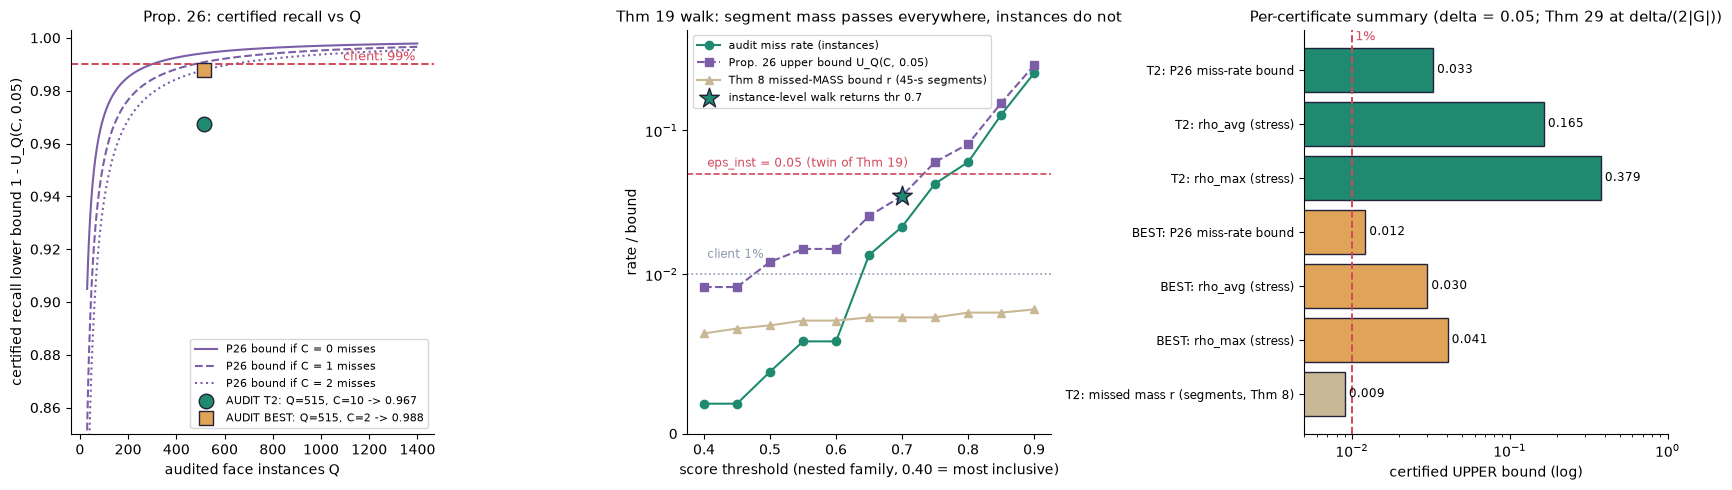

In [25]:
# VIZ
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ax = axes[0]
Qc = np.arange(30, 1400)
for C_, ls_, col in ((0, "-", C_CERT), (1, "--", C_CERT), (2, ":", C_CERT)):
    ax.plot(Qc, 1 - cp_upper(C_, Qc, DELTA_AUDIT), ls_, color=col, label=f"P26 bound if C = {C_} misses")
ax.axhline(0.99, color=C_REQ, lw=1.4, ls="--"); ax.text(1390, 0.9915, "client: 99%", color=C_REQ, ha="right", fontsize=9)
for name, mk, col in (("T2", "o", C_LTT), ("BEST", "s", C_CRC)):
    a = AUD[name]
    ax.scatter(a["Q"], 1 - a["U"], marker=mk, s=110, color=col, ec=PALETTE["ink"], zorder=5, label=f"AUDIT {name}: Q={a['Q']}, C={a['C']} -> {1 - a['U']:.3f}")
ax.set_ylim(0.85, 1.003); ax.set_xlabel("audited face instances Q"); ax.set_ylabel("certified recall lower bound 1 - U_Q(C, 0.05)")
ax.set_title("Prop. 26: certified recall vs Q"); ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
thr = T19["thr"].to_numpy()
ax.plot(thr, T19["instance_miss_rate"], "o-", color=C_LTT, label="audit miss rate (instances)")
ax.plot(thr, T19["U_Q_C_inst"], "s--", color=C_CERT, label="Prop. 26 upper bound U_Q(C, 0.05)")
ax.axhline(EPS_INST, color=C_REQ, ls="--", lw=1.2); ax.text(0.405, EPS_INST + 0.006, f"eps_inst = {EPS_INST} (twin of Thm 19)", color=C_REQ, fontsize=8.5)
ax.axhline(0.01, color=PALETTE["stone"], ls=":", lw=1.2); ax.text(0.405, 0.013, "client 1%", color=PALETTE["stone"], fontsize=8.5)
ax.plot(thr, T19["r_bound_seg"], "^-", color=PALETTE["sand"], label="Thm 8 missed-MASS bound r (45-s segments)")
if ret_inst >= 0:
    ax.scatter([NESTED_THR[ret_inst]], [T19.loc[ret_inst, "U_Q_C_inst"]], s=220, marker="*", color=C_LTT, ec=PALETTE["ink"], zorder=6, label=f"instance-level walk returns thr {NESTED_THR[ret_inst]}")
ax.set_yscale("symlog", linthresh=0.01); ax.set_ylim(0, 0.5); ax.set_xlabel("score threshold (nested family, 0.40 = most inclusive)"); ax.set_ylabel("rate / bound")
ax.set_title("Thm 19 walk: segment mass passes everywhere, instances do not"); ax.legend(fontsize=8, loc="upper left")

ax = axes[2]
lab, val, col = [], [], []
for name, c_ in (("T2", C_LTT), ("BEST", C_CRC)):
    a = AUD[name]; t = T29[T29["config"] == name].iloc[0]
    for l_, v_ in ((f"{name}: P26 miss-rate bound", a["U"]), (f"{name}: rho_avg (stress)", t["rho_avg_bound"]), (f"{name}: rho_max (stress)", t["rho_max_bound"])):
        lab.append(l_); val.append(v_); col.append(c_)
lab.append("T2: missed mass r (segments, Thm 8)"); val.append(r_hyper); col.append(PALETTE["sand"])
y = np.arange(len(lab))[::-1]
ax.barh(y, val, color=col, ec=PALETTE["ink"])
for yi, v_ in zip(y, val):
    ax.text(v_ * 1.06, yi, f"{v_:.3f}", va="center", fontsize=8.5)
ax.axvline(0.01, color=C_REQ, ls="--", lw=1.4); ax.text(0.0105, y.max() + 0.55, "1%", color=C_REQ, fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(lab, fontsize=8.5); ax.set_xscale("log"); ax.set_xlim(0.005, 1.0)
ax.set_xlabel("certified UPPER bound (log)"); ax.set_title("Per-certificate summary (delta = 0.05; Thm 29 at delta/(2|G|))")
plt.tight_layout(); plt.show()

#### How to read this chart

Three panels; bounds are one-sided upper bounds at delta = 0.05 (the stress bounds at delta/(2|G|)).

- **Left: Prop. 26 recall bound against audit size.** x = audited face instances Q; y = certified recall lower bound 1 - U_Q(C, 0.05); curves for C = 0, 1, 2 misses; red dashed line = the client's 99%. At Q = 515 the best-effort audit (C = 2) sits on its curve at 0.988, just under 99%; T2 (C = 10) is far below every curve at 0.967.
- **Middle: the Thm 19 walk.** x = nested score threshold (0.40 most inclusive); y is a symlog axis. The green instance miss rate rises from about 0.002 to 0.25; the purple Prop. 26 bound sits above it; the tan Thm 8 missed-mass bound stays near 0.006 to 0.008, under the client's 1% line everywhere. The star marks where the instance-level walk stops (thr 0.70). The gap between tan and green is the point: the segment certificate passes even where a quarter of faces are missed.
- **Right: all certificates (log x).** Only the missed-mass bar (0.009) is left of the 1% line; every recall-relevant bar (0.012 to 0.379) is right of it.

For the job: quote the left panel as the recall evidence; the tan line is a diagnostic.

## 6. Cost per option

**Claim.** The client wants the cheapest configuration that meets the targets, but none of the three papers prices anything. P3 minimises a *review burden* B(g) = P(g(X) = 1) subject to a certified missed-mass bound [P3 Sec. 3, Eq. 1, facered-q9], and computational rendering, GPU latency or encoding cost is simply not addressed [facered-q12(d)]. So every dollar figure here is **derived here** or **assumed**, and cost minimisation among certified configurations is a design step of this notebook, not a result from the sources.

**What is measured and what is assumed.**
- **Measured**: throughput of the reused Notebook 2 pipeline on this shared WSL2 VM, from `data/smoke/timings.json` (a 15-frame 4K clip); section 3's throughput cell (`16_throughput`) builds the dictionary. NB2 recorded several-fold run-to-run variation on this machine.
- **Assumed placeholders, not provider quotes**: the CPU price, the GPU price and the GPU speed-up over the CPU path. A dollar per video-hour is *measured throughput x assumed price*.

**Options priced.** The T2-certified configuration(s); strided variants (only stride changes the cost; they are **uncertified**, either failing on CAL2 or not reached by the fixed-sequence walk, whose p-values are not certificates); the best-effort recall-first configuration (uncertified by LTT; the audit is its only evidence); and the GPU column under the assumed numbers. The cell prints the **break-even**: the GPU is cheaper only if speed-up > GPU price / CPU price, whatever the throughput.

**A-priori checks.** **6.1** cost is strictly decreasing in stride (1 > 2 > 4) for both columns (the lever exists). **6.2** at speed-up = GPU price / CPU price the two columns are equal (an identity of the cost function). **6.3** run-to-run variance in the measured timings moves the CPU $/video-hour by at least 2x, so that no single dollar figure should be quoted to the client (the threshold is stated as 2.0x; watch how close it is).

In [26]:
# ---- 6. Cost per option: $/video-hour from NB2's processing_cost. MEASURED = CPU throughput from data/smoke/timings.json; ASSUMED = GPU speed-up and both prices ----
# Options: the T2-certified config; strided variants from the grid (uncertified: not in Lambda-hat); the recall-first best-effort config (T1, uncertified); NB2's naive baseline.
p2 = LTT_MAIN["T2"]["p_test"]; lam2 = LTT_MAIN["T2"]["lam_hat"]
def opt_row(label, j, status):
    c = processing_cost(pc_of(ALL_KEYS[j]), THROUGHPUT, PRICE)
    return dict(option=label, config=describe_key(ALL_KEYS[j]), status=status, cal2_miss_synth=round(float(p2["miss"][j]), 4), cal2_pooled_precision_synth=round(float(p2["pooled_prec"][j]), 3),
                cpu_usd_per_video_hour=round(c["cpu_usd_per_video_hour"], 3), gpu_usd_per_video_hour_assumed=round(c["gpu_usd_per_video_hour"], 3))
cost_rows = [opt_row("T2 certified (chosen)", J_T2, "CERTIFIED (LTT T2, delta=0.10)")]
for j in np.where(lam2)[0]:
    if j != J_T2:
        cost_rows.append(opt_row("T2 certified (other)", int(j), "CERTIFIED (LTT T2, delta=0.10)"))
for j in sorted([j for j in range(G) if ALL_KEYS[j][1] > 1], key=lambda j: p2["p_max"][j])[:4]:
    cost_rows.append(opt_row(f"stride {ALL_KEYS[j][1]} variant", int(j), f"not certified (CAL2 p_max {p2['p_max'][j]:.3f}; not reached by the walk)" if p2["p_max"][j] <= DELTA else f"not certified (CAL2 p_max {p2['p_max'][j]:.2f})"))
cost_rows.append(opt_row("best-effort recall-first (T1)", J_BEST, "not certified (T1 empty; audit shows Prop. 26 recall >= %.3f)" % (1 - AUD["BEST"]["U"])))
COST_DF = pd.DataFrame(cost_rows)
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 300)
print("Cost per option (synthetic recall/precision on CAL2; CPU $/h = MEASURED throughput x ASSUMED price; GPU $/h = ASSUMED speed-up x ASSUMED price):")
print(COST_DF.to_string(index=False))

# break-even GPU: the GPU column is cheaper only if speed-up > GPU price / CPU price (ASSUMED both)
BE_SPEEDUP = ASSUMED_GPU_USD_PER_HOUR / ASSUMED_CPU_USD_PER_HOUR
BE_GPU_PRICE = ASSUMED_GPU_SPEEDUP * ASSUMED_CPU_USD_PER_HOUR
print(f"\nbreak-even (ASSUMED numbers): GPU needs speed-up > GPU price / CPU price = {BE_SPEEDUP:.0f}x at ${ASSUMED_GPU_USD_PER_HOUR}/h vs ${ASSUMED_CPU_USD_PER_HOUR}/h (assumed speed-up {ASSUMED_GPU_SPEEDUP:.0f}x => GPU is "
      f"{'cheaper' if ASSUMED_GPU_SPEEDUP > BE_SPEEDUP else 'MORE expensive'} under THESE placeholders); or, at {ASSUMED_GPU_SPEEDUP:.0f}x, the GPU price must be < ${BE_GPU_PRICE:.2f}/h.")
c_be = processing_cost(dict(stride=1), dict(THROUGHPUT, assumed_gpu_speedup=BE_SPEEDUP), PRICE)
check("6.1", "processing_cost is strictly decreasing in stride (1 > 2 > 4) for both CPU and GPU columns (the stride lever exists; a-priori property)",
      COST_BY_STRIDE[1]["cpu_usd_per_video_hour"] > COST_BY_STRIDE[2]["cpu_usd_per_video_hour"] > COST_BY_STRIDE[4]["cpu_usd_per_video_hour"], f"CPU $/h {[round(COST_BY_STRIDE[s]['cpu_usd_per_video_hour'], 3) for s in (1, 2, 4)]}")
check("6.2", "break-even identity: at GPU speed-up = GPU price / CPU price the GPU and CPU $/video-hour are equal (a-priori identity of processing_cost)",
      abs(c_be["gpu_usd_per_video_hour"] - c_be["cpu_usd_per_video_hour"]) < 1e-9, f"{c_be['gpu_usd_per_video_hour']:.6f} vs {c_be['cpu_usd_per_video_hour']:.6f}")

# sensitivity of the cheapest CERTIFIED option (stride 1 here) to the ASSUMED parameters, and to the measured smoke-run variance
sens_rows = []
for sp_ in (2.0, 4.0, 8.0, 16.0, 32.0):
    for gp in (0.30, 0.60, 1.20):
        c = processing_cost(dict(stride=1), dict(THROUGHPUT, assumed_gpu_speedup=sp_), dict(assumed_cpu_usd_per_hour=ASSUMED_CPU_USD_PER_HOUR, assumed_gpu_usd_per_hour=gp))
        sens_rows.append(dict(gpu_speedup_assumed=sp_, gpu_usd_per_hour_assumed=gp, cpu_usd_per_video_hour=round(c["cpu_usd_per_video_hour"], 3),
                              gpu_usd_per_video_hour=round(c["gpu_usd_per_video_hour"], 3), cheaper="GPU" if c["gpu_usd_per_video_hour"] < c["cpu_usd_per_video_hour"] else "CPU"))
SENS_COST_DF = pd.DataFrame(sens_rows)
print("\nsensitivity of the certified option's cost (stride 1) to the ASSUMED GPU speed-up and price (CPU price held at the assumed $0.05/h):")
print(SENS_COST_DF.pivot(index="gpu_speedup_assumed", columns="gpu_usd_per_hour_assumed", values="gpu_usd_per_video_hour").to_string())
print(f"(CPU column for comparison: ${COST_BY_STRIDE[1]['cpu_usd_per_video_hour']:.3f}/video-hour, independent of the GPU assumptions)")
# smoke-run variance: NB2 recorded decode 7-42 fps and libx264 encode 0.6-4.5 fps across runs on this shared VM (several-fold); scenario costs at stride 1 and stride 4
VAR = {"slow run (decode 7 fps, encode 0.6 fps)": dict(decode_fps=7.0, encode_fps=0.6), "as measured in timings.json": {}, "fast run (decode 42 fps, encode 4.5 fps)": dict(decode_fps=42.0, encode_fps=4.5)}
var_rows = []
for nm, kw in VAR.items():
    for s in (1, 4):
        c = processing_cost(dict(stride=s), dict(THROUGHPUT, **kw), PRICE)
        var_rows.append(dict(scenario=nm, stride=s, cpu_usd_per_video_hour=round(c["cpu_usd_per_video_hour"], 3)))
VAR_DF = pd.DataFrame(var_rows)
print("\nsmoke-timing variance (ranges recorded in Notebook 2 across runs on this shared WSL2 VM; detect fps held at the measured value):"); print(VAR_DF.to_string(index=False))
_ratio = VAR_DF[VAR_DF["stride"] == 1]["cpu_usd_per_video_hour"].max() / VAR_DF[VAR_DF["stride"] == 1]["cpu_usd_per_video_hour"].min()
check("6.3", "the run-to-run variance of the measured smoke timings moves the CPU $/video-hour by >= 2x (a-priori: so no single $ figure should be quoted to the client)",
      _ratio >= 2.0, f"max/min = {_ratio:.3f}x at stride 1 (threshold >= 2.0; borderline if close)")

Cost per option (synthetic recall/precision on CAL2; CPU $/h = MEASURED throughput x ASSUMED price; GPU $/h = ASSUMED speed-up x ASSUMED price):
                       option                                     config                                                         status  cal2_miss_synth  cal2_pooled_precision_synth  cpu_usd_per_video_hour  gpu_usd_per_video_hour_assumed
        T2 certified (chosen) thr=0.70 stride=1 gap=10 pad=20 margin=0.3                                 CERTIFIED (LTT T2, delta=0.10)           0.0355                        0.525                   2.581                           3.872
         T2 certified (other) thr=0.70 stride=1 gap=30 pad=20 margin=0.3                                 CERTIFIED (LTT T2, delta=0.10)           0.0355                        0.520                   2.581                           3.872
             stride 2 variant thr=0.70 stride=2 gap=30 pad=40 margin=0.3      not certified (CAL2 p_max 0.015; not reached by the walk)      

**What the output says.**

- **The cheapest certified option is stride 1**: CPU **$2.581** per video-hour (measured throughput x assumed $0.05/h), GPU **$3.872** (assumed 8x speed-up at an assumed $0.60/h). Both members of the certified set are stride 1, so certification bought **no saving** here (the summary line in section 3 says $0.000/h).
- **The cost lever exists but is uncertified.** Stride 2 costs $1.621 and stride 4 costs $1.141 (CHECK 6.1 PASS). The two best stride-2 variants have a CAL2 p_max of 0.015 and 0.025, below delta, but were not reached by the fixed-sequence walk and so carry no certificate. Whether a stride-2 configuration can be certified depends on the split: over section 3's 200 re-splits the cheapest certified configuration had stride above 1 in 64% of the runs that certified anything. A cheaper *certified* option therefore needs a path pre-registered before looking at labels, on a fresh split.
- **The recall-first configuration costs the same as the T2 choice** ($2.581): cost depends on stride, not on threshold or padding.
- **GPU break-even (assumed numbers): 12x**; the assumed speed-up is 8x, so the GPU is *more* expensive under these placeholders; at 8x the GPU would have to cost under $0.40 per hour. CHECK 6.2 PASS.
- **Timing variance:** CPU cost at stride 1 is $4.635 (slow smoke run), $2.581 (as measured), $2.289 (fast run): max/min = 2.02x. **CHECK 6.3 passes only at the threshold** (>= 2.0x against 2.02x): treat it as borderline, and it is why no single dollar figure should be quoted. At stride 4 the same three runs span $0.85 to $3.19.

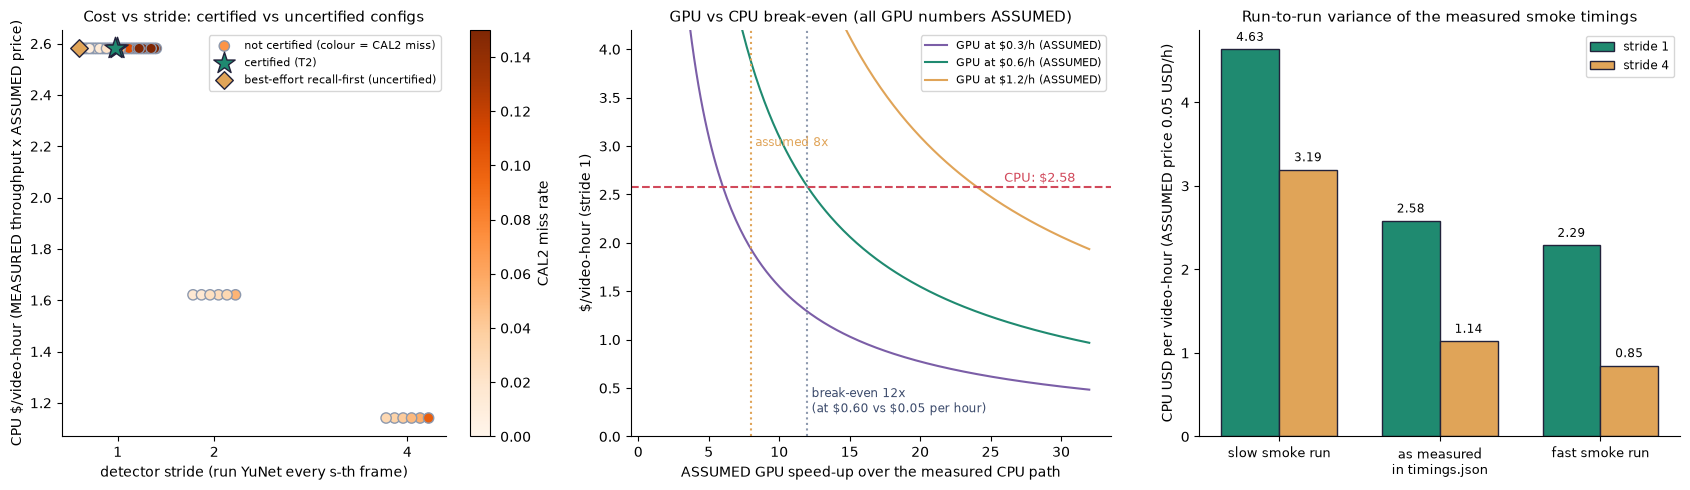

In [27]:
# VIZ
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ax = axes[0]
strd = np.array([k[1] for k in ALL_KEYS]); x = np.zeros(G)
for s_ in (1, 2, 4):                                    # strip layout: within a stride, configs are spread left-to-right by increasing CAL2 miss
    m_ = np.where(strd == s_)[0]; order_ = m_[np.argsort(p2["miss"][m_])]
    x[order_] = s_ + np.linspace(-0.4, 0.4, len(order_)) * (0.55 if s_ > 1 else 1.0)
unc = ~lam2
sc = ax.scatter(x[unc], COST_VEC[unc], c=np.clip(p2["miss"][unc], 0, 0.15), cmap="Oranges", s=55, ec=PALETTE["stone"], vmin=0, vmax=0.15, label="not certified (colour = CAL2 miss)")
ax.scatter(x[lam2], COST_VEC[lam2], marker="*", s=260, color=C_LTT, ec=PALETTE["ink"], zorder=5, label="certified (T2)")
ax.scatter([x[J_BEST]], [COST_VEC[J_BEST]], marker="D", s=80, color=C_CRC, ec=PALETTE["ink"], zorder=4, label="best-effort recall-first (uncertified)")
plt.colorbar(sc, ax=ax, label="CAL2 miss rate")
ax.set_xticks([1, 2, 4]); ax.set_xlabel("detector stride (run YuNet every s-th frame)"); ax.set_ylabel("CPU $/video-hour (MEASURED throughput x ASSUMED price)")
ax.set_title("Cost vs stride: certified vs uncertified configs"); ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
sp = np.linspace(1, 32, 200)
for gp, col in ((0.30, C_CERT), (0.60, C_LTT), (1.20, C_CRC)):
    ax.plot(sp, COST_BY_STRIDE[1]["cpu_compute_s_per_video_s"] / sp * gp, color=col, label=f"GPU at ${gp}/h (ASSUMED)")
ax.axhline(COST_BY_STRIDE[1]["cpu_usd_per_video_hour"], color=C_REQ, ls="--", lw=1.5); ax.text(31, COST_BY_STRIDE[1]["cpu_usd_per_video_hour"] + 0.05, f"CPU: ${COST_BY_STRIDE[1]['cpu_usd_per_video_hour']:.2f}", color=C_REQ, ha="right", fontsize=9)
ax.axvline(BE_SPEEDUP, color=PALETTE["stone"], ls=":"); ax.text(BE_SPEEDUP + 0.3, 0.25, f"break-even {BE_SPEEDUP:.0f}x\n(at \\$0.60 vs \\$0.05 per hour)", fontsize=8.5, color=PALETTE["slate"])
ax.axvline(ASSUMED_GPU_SPEEDUP, color=PALETTE["amber"], ls=":"); ax.text(ASSUMED_GPU_SPEEDUP + 0.3, 3.0, f"assumed {ASSUMED_GPU_SPEEDUP:.0f}x", fontsize=8.5, color=PALETTE["amber"])
ax.set_ylim(0, 4.2); ax.set_xlabel("ASSUMED GPU speed-up over the measured CPU path"); ax.set_ylabel("$/video-hour (stride 1)"); ax.set_title("GPU vs CPU break-even (all GPU numbers ASSUMED)"); ax.legend(fontsize=8)

ax = axes[2]
w = 0.36; xs = np.arange(len(VAR))
for k_, (s, col) in enumerate(((1, C_LTT), (4, C_CRC))):
    vals = VAR_DF[VAR_DF["stride"] == s]["cpu_usd_per_video_hour"].to_numpy()
    ax.bar(xs + (k_ - 0.5) * w, vals, w, color=col, ec=PALETTE["ink"], label=f"stride {s}")
    for xi, v_ in zip(xs, vals):
        ax.text(xi + (k_ - 0.5) * w, v_ + 0.1, f"{v_:.2f}", ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels(["slow smoke run", "as measured\nin timings.json", "fast smoke run"], fontsize=9)
ax.set_ylabel("CPU USD per video-hour (ASSUMED price 0.05 USD/h)"); ax.set_title("Run-to-run variance of the measured smoke timings"); ax.legend()
plt.tight_layout(); plt.show()

#### How to read this chart

Every dollar figure is measured throughput times an **assumed** price; the GPU numbers are assumed throughout.

- **Left: cost against stride.** x = detector stride (1, 2, 4); y = CPU $/video-hour; each dot is one of the 58 grid configurations, coloured by CAL2 miss rate. The dots form three horizontal bands (about 2.58, 1.62, 1.14) because cost depends only on stride. The stars (certified) and the diamond (recall-first, uncertified) all sit in the top band: certification chose among stride-1 options only.
- **Middle: GPU against CPU.** x = assumed GPU speed-up; y = stride-1 $/video-hour. Curves are the GPU at $0.30, $0.60 and $1.20 per hour; the red dashed line is the CPU cost ($2.58). A curve crossing the line marks break-even: about 6x, 12x and 24x. The verticals mark the 12x break-even (at $0.60 vs $0.05) and the assumed 8x, which lies to its left.
- **Right: measurement variance.** CPU cost at stride 1 (teal) and stride 4 (amber) under a slow, the measured and a fast smoke run: 4.63 / 2.58 / 2.29 and 3.19 / 1.14 / 0.85. The spread within one stride is as large as the gap between strides.

For the job: quote a range with the assumptions attached, and replace the placeholders with real prices.

## 7. Re-verification harness

**Claim.** A certificate belongs to one configuration fixed before its labels were opened [P3 Assumption 1, Sec. 2.4, facered-q12(b)]. When the model, the threshold or the footage changes, the old certificate says nothing about the new system: the protocol is **any design, threshold or model change needs a fresh sealed audit set**. The cell packages what section 5 did into one plain-Python function so the client, or you, can re-run it: `reverify(config, labelled_corpus, detections, delta, targets)`.

**What it recomputes** (from a fresh labelled audit set only): the instance count Q and misses C, the miss rate with the Prop. 26 upper bound and the Clopper-Pearson lower bound [P3 Prop. 26, facered-q9]; LTT p-values for both risks (binomial for the miss indicator, Hoeffding-Bentkus for the episode-averaged false-blur fraction) and their maximum, following LTT's rule for several risks [P1 Prop. 6, facered-q12(a)]; the pooled precision with an episode-cluster bootstrap interval (a bootstrap, not a guarantee).

**Verdict rules (fixed here, before the demonstrations).** LTT targets: **PASS** if both p-values are <= delta; **FAIL** if the data reject the target (the Clopper-Pearson lower bound of the miss rate exceeds alpha_miss, or the Hoeffding lower bound of the false-blur risk exceeds alpha_fb); **INCONCLUSIVE** otherwise, with a reason (for example Q too small to certify even with zero misses). The client's claims get a separate verdict: FAIL if the recall leg or the precision leg is rejected by the data, PASS only if U_Q <= 1% *and* the bootstrap lower limit is >= 0.95, INCONCLUSIVE otherwise.

**What it does not certify.** Any other configuration; a configuration or threshold changed after these labels were seen; footage unlike this generator (distribution shift, which no source covers [facered-q11]); temporal dependence beyond "instances are exchangeable"; noisy labels [P3 Assumption 2, facered-q11]; and the precision interval, which is a bootstrap.

**Demonstrations and a-priori claims** (five fresh audit sets from new seeds, delta = 0.05, targets alpha_miss = 0.05, alpha_fb = 0.45 plus the client's 99% / 95%):

| case | change | a-priori claim |
|---|---|---|
| (i) | none, fresh 500-episode set | LTT verdict PASS (7.2) |
| (ii) | detector base logit lowered by 1.0, from 1.0 to 0.0 (a synthetic model change) | caught: FAIL (7.3) |
| (iii-a) | threshold 0.70 to 0.90 | caught: FAIL (7.4) |
| (iii-b) | threshold 0.70 to 0.60 | shown, no claim made |
| (iv) | none, but a 40-episode set | the client's 99% claim is never PASS at Q < 299 (7.5) |

CHECK 7.1 is a regression test (on the sealed AUDIT the function must reproduce section 5's Q, C and Prop. 26 bound exactly); 7.6 checks that the JSON report round-trips and that two runs give identical results.

In [28]:
# ---- 7. Re-verification harness: a compact function the client (or you) re-runs whenever the model, threshold or footage changes ----
def reverify(config: dict, labelled_corpus: dict, detections: pd.DataFrame, delta: float, targets: dict, n_boot: int = 1000, seed: int = 0) -> dict:
    """Re-verify ONE pipeline configuration against a FRESH labelled audit set.

    Inputs: `config` (NB2 pipeline-config dict), a labelled corpus (episodes + latent/GT truth), the raw detector output for those episodes, the error level `delta`,
    and `targets` = dict(miss=alpha_miss, fb=alpha_fb, client_recall=0.99, client_precision=0.95).

    What it CERTIFIES (only if `config` and `targets` were fixed BEFORE these labels were examined and the episodes are a fresh, unopened sample):
      * Prop. 26 [P3]: with prob >= 1 - delta, the instance miss rate L <= U_Q(C, delta) (Clopper-Pearson over the Q audited face INSTANCES) -> a recall lower bound;
      * LTT p-values [P1] for both risks (binomial for the binary miss loss, Hoeffding-Bentkus for the episode-averaged false-blur fraction) and their max (Prop. 6);
      * a verdict: PASS / FAIL / INCONCLUSIVE for the LTT targets and, separately, for the client's 99% recall / 95% pooled-precision claims.
    What it does NOT certify: any other configuration; a config or threshold changed after these labels were seen (that needs a NEW audit set); footage unlike this generator
    (distribution shift); temporal dependence beyond 'instances are exchangeable'; noisy labels; the cluster-bootstrap precision interval is a bootstrap, not a paper guarantee.
    Verdict rule (fixed here): PASS = both p-values <= delta; FAIL = the data reject the target (Clopper-Pearson lower bound of the miss rate > alpha_miss, or the Hoeffding lower
    bound of the false-blur risk > alpha_fb); INCONCLUSIVE otherwise (reason given, e.g. Q too small for the target even with zero misses)."""
    L = episode_losses(labelled_corpus, detections, config)
    Q, C = int(L["n_inst"].sum()), int(L["n_miss"].sum()); n_ep = len(L["n_inst"])
    fdp = np.where(L["n_box"] > 0, L["n_false"] / np.maximum(L["n_box"], 1), 0.0); R_fb = float(fdp.mean())
    U, Lo = float(cp_upper(C, Q, delta)), float(cp_lower(C, Q, delta))
    p_m, p_f = float(p_binom(C, Q, targets["miss"])), float(p_hb(R_fb, n_ep, targets["fb"]))
    hoeff_lb = R_fb - float(np.sqrt(np.log(1 / delta) / (2 * n_ep)))
    idx = np.random.default_rng(seed).integers(0, n_ep, size=(n_boot, n_ep))                      # episode-cluster bootstrap
    prec_b = 1 - L["n_false"][idx].sum(1) / np.maximum(L["n_box"][idx].sum(1), 1)
    prec, prec_ci = float(1 - L["n_false"].sum() / max(L["n_box"].sum(), 1)), np.percentile(prec_b, [2.5, 97.5])
    q_zero = int(np.ceil(np.log(1 / delta) / np.log(1 / (1 - targets["miss"]))))                   # instances needed even with ZERO misses to certify alpha_miss
    if max(p_m, p_f) <= delta:
        v_ltt, why = "PASS", "both p-values <= delta"
    elif Lo > targets["miss"] or hoeff_lb > targets["fb"]:
        v_ltt, why = "FAIL", "data reject the target: " + ("miss-rate lower bound %.4f > alpha_miss" % Lo if Lo > targets["miss"] else "false-blur lower bound %.3f > alpha_fb" % hoeff_lb)
    else:
        v_ltt, why = "INCONCLUSIVE", ("Q=%d < %d needed even with zero misses" % (Q, q_zero)) if Q < q_zero else "p-values above delta but no evidence of violation (borderline / more data needed)"
    q_client = int(np.ceil(np.log(1 / delta) / np.log(1 / (1 - (1 - targets["client_recall"])))))
    r_ok, r_bad = U <= 1 - targets["client_recall"], Lo > 1 - targets["client_recall"]
    p_ok, p_bad = prec_ci[0] >= targets["client_precision"], prec_ci[1] < targets["client_precision"]
    v_client = "FAIL" if (r_bad or p_bad) else "PASS" if (r_ok and p_ok) else "INCONCLUSIVE"
    return dict(config=dict(config), Q=Q, C=C, n_episodes=n_ep, miss_rate=C / max(Q, 1), prop26_U=U, recall_lower_bound=1 - U, miss_rate_lower_bound=Lo,
                Q_needed_zero_miss_for_alpha_miss=q_zero, Q_needed_zero_miss_for_client_recall=q_client, episode_avg_false_blur=R_fb,
                pooled_precision=prec, pooled_precision_boot95=[float(prec_ci[0]), float(prec_ci[1])], p_miss=p_m, p_fb=p_f, p_max=max(p_m, p_f),
                verdict_ltt_targets=v_ltt, verdict_reason=why, verdict_client_claims=v_client, delta=delta, targets=dict(targets))

HARNESS_TARGETS = dict(miss=ALPHA_T2["miss"], fb=ALPHA_T2["fb"], client_recall=0.99, client_precision=0.95)
def fresh_set(seed, n_episodes, det=None):
    c = generate_corpus(SimConfig(n_episodes=n_episodes, seed=seed))
    return c, simulate_detector(c, det or {}, seed=seed + 1)
CFG_T2 = pc_of(ALL_KEYS[J_T2]); CFG_T2_HI = dict(CFG_T2, score_thr=0.90); CFG_T2_LO = dict(CFG_T2, score_thr=0.60)
t0 = time.time()
H = {}
c_, d_ = fresh_set(SEED + 50, 500);                       H["(i) unchanged config, fresh audit set"] = reverify(CFG_T2, c_, d_, DELTA_AUDIT, HARNESS_TARGETS)
c_, d_ = fresh_set(SEED + 51, 500, dict(base=0.0));       H["(ii) model change: detector base logit -1.0, fresh audit set"] = reverify(CFG_T2, c_, d_, DELTA_AUDIT, HARNESS_TARGETS)
c_, d_ = fresh_set(SEED + 52, 500);                       H["(iii-a) threshold change 0.70 -> 0.90, fresh audit set"] = reverify(CFG_T2_HI, c_, d_, DELTA_AUDIT, HARNESS_TARGETS)
c_, d_ = fresh_set(SEED + 53, 500);                       H["(iii-b) threshold change 0.70 -> 0.60, fresh audit set"] = reverify(CFG_T2_LO, c_, d_, DELTA_AUDIT, HARNESS_TARGETS)
c_, d_ = fresh_set(SEED + 54, 40);                        H["(iv) unchanged config, SMALL fresh audit set (40 episodes)"] = reverify(CFG_T2, c_, d_, DELTA_AUDIT, HARNESS_TARGETS)
print(f"5 harness demonstrations in {time.time() - t0:.1f}s")
HDF = pd.DataFrame([dict(case=k, Q=v["Q"], C=v["C"], miss_rate=round(v["miss_rate"], 4), recall_LB=round(v["recall_lower_bound"], 4), R_fb_episode=round(v["episode_avg_false_blur"], 3),
                         pooled_precision=round(v["pooled_precision"], 3), p_miss=round(v["p_miss"], 4), p_fb=round(v["p_fb"], 4), verdict_LTT_targets=v["verdict_ltt_targets"],
                         verdict_client_99_95=v["verdict_client_claims"]) for k, v in H.items()])
pd.set_option("display.width", 300); pd.set_option("display.max_colwidth", 62)
print(f"targets: LTT T2 (miss <= {HARNESS_TARGETS['miss']}, false-blur <= {HARNESS_TARGETS['fb']}) and the client's (recall >= 0.99, pooled precision >= 0.95); delta = {DELTA_AUDIT}"); print(HDF.to_string(index=False))
for k, v in H.items():
    print(f"  {k}: LTT verdict {v['verdict_ltt_targets']} ({v['verdict_reason']}); client claims {v['verdict_client_claims']}; Q needed for a 99% claim with 0 misses = {v['Q_needed_zero_miss_for_client_recall']}")

# regression test of the harness against section 5 (same sealed audit, same config: must reproduce Prop. 26 exactly)
_rv = reverify(CFG_T2, CORP["AUDIT"], DETS["AUDIT"], DELTA_AUDIT, HARNESS_TARGETS)
_cases = list(H.values())
check("7.1", "harness regression: on the sealed AUDIT with the T2 config, reverify() reproduces section 5's Q, C and Prop. 26 bound exactly",
      (_rv["Q"], _rv["C"]) == (AUD["T2"]["Q"], AUD["T2"]["C"]) and abs(_rv["prop26_U"] - AUD["T2"]["U"]) < 1e-12, f"Q={_rv['Q']}, C={_rv['C']}, U={_rv['prop26_U']:.4f}")
check("7.2", "(i) the unchanged config on a fresh audit set is NOT flagged: LTT-target verdict PASS (a-priori claim)", _cases[0]["verdict_ltt_targets"] == "PASS",
      f"verdict {_cases[0]['verdict_ltt_targets']}: {_cases[0]['verdict_reason']} (miss {_cases[0]['C']}/{_cases[0]['Q']}, p_max {_cases[0]['p_max']:.4f})")
check("7.3", "(ii) the model change is CAUGHT: LTT-target verdict FAIL (a-priori claim)", _cases[1]["verdict_ltt_targets"] == "FAIL",
      f"verdict {_cases[1]['verdict_ltt_targets']}: {_cases[1]['verdict_reason']} (miss {_cases[1]['C']}/{_cases[1]['Q']})")
check("7.4", "(iii-a) the aggressive threshold change 0.70 -> 0.90 is CAUGHT: LTT-target verdict FAIL (a-priori claim)", _cases[2]["verdict_ltt_targets"] == "FAIL",
      f"verdict {_cases[2]['verdict_ltt_targets']}: {_cases[2]['verdict_reason']} (miss {_cases[2]['C']}/{_cases[2]['Q']})")
check("7.5", "(iv) a small audit set (Q far below the 299 zero-miss requirement) never gets PASS for the client's 99% recall claim: the verdict is INCONCLUSIVE, or FAIL when the few audited misses already reject 99% (a-priori)",
      _cases[4]["verdict_client_claims"] != "PASS" and _cases[4]["Q"] < 299, f"Q={_cases[4]['Q']}, client verdict {_cases[4]['verdict_client_claims']}")
_rv2 = reverify(CFG_T2, CORP["AUDIT"], DETS["AUDIT"], DELTA_AUDIT, HARNESS_TARGETS)
report = dict(protocol="Any design / threshold / model change requires a FRESH sealed audit set; certificates hold only for a config fixed before its labels were opened [P3 Assumption 1, Sec. 2.4].",
              targets=HARNESS_TARGETS, delta=DELTA_AUDIT, cases=H, regression_sealed_audit=_rv)
(NB3_DIR / "reverify_report.json").write_text(json.dumps(report, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o)))
_back = json.loads((NB3_DIR / "reverify_report.json").read_text())
check("7.6", "the JSON report is written to data/nb3/, round-trips, and reverify() is deterministic (two runs on the same inputs give identical dicts)",
      _back["regression_sealed_audit"]["C"] == _rv["C"] and _rv == _rv2, f"{(NB3_DIR / 'reverify_report.json').stat().st_size} bytes")
print("\nProtocol: any design / threshold / model change requires a fresh sealed audit set; certificates are valid only for a config fixed before its labels were opened. "
      "Re-using opened labels 'voids the guarantee' [P3 Sec. 2.4].")

5 harness demonstrations in 8.4s
targets: LTT T2 (miss <= 0.05, false-blur <= 0.45) and the client's (recall >= 0.99, pooled precision >= 0.95); delta = 0.05
                                                        case   Q   C  miss_rate  recall_LB  R_fb_episode  pooled_precision  p_miss   p_fb verdict_LTT_targets verdict_client_99_95
                       (i) unchanged config, fresh audit set 356   6     0.0169     0.9670         0.362             0.569  0.0010 0.0001                PASS                 FAIL
(ii) model change: detector base logit -1.0, fresh audit set 392  77     0.1964     0.7676         0.346             0.600  1.0000 0.0000                FAIL                 FAIL
      (iii-a) threshold change 0.70 -> 0.90, fresh audit set 403 104     0.2581     0.7036         0.218             0.727  1.0000 0.0000                FAIL                 FAIL
      (iii-b) threshold change 0.70 -> 0.60, fresh audit set 343   6     0.0175     0.9658         0.420             0.448  0.

CHECK 7.1: harness regression: on the sealed AUDIT with the T2 config, reverify() reproduces section 5's Q, C and Prop. 26 bound exactly -> Q=515, C=10, U=0.0327 -> PASS
CHECK 7.2: (i) the unchanged config on a fresh audit set is NOT flagged: LTT-target verdict PASS (a-priori claim) -> verdict PASS: both p-values <= delta (miss 6/356, p_max 0.0010) -> PASS
CHECK 7.3: (ii) the model change is CAUGHT: LTT-target verdict FAIL (a-priori claim) -> verdict FAIL: data reject the target: miss-rate lower bound 0.1639 > alpha_miss (miss 77/392) -> PASS
CHECK 7.4: (iii-a) the aggressive threshold change 0.70 -> 0.90 is CAUGHT: LTT-target verdict FAIL (a-priori claim) -> verdict FAIL: data reject the target: miss-rate lower bound 0.2224 > alpha_miss (miss 104/403) -> PASS
CHECK 7.5: (iv) a small audit set (Q far below the 299 zero-miss requirement) never gets PASS for the client's 99% recall claim: the verdict is INCONCLUSIVE, or FAIL when the few audited misses already reject 99% (a-priori) -> Q=

CHECK 7.6: the JSON report is written to data/nb3/, round-trips, and reverify() is deterministic (two runs on the same inputs give identical dicts) -> 7298 bytes -> PASS

Protocol: any design / threshold / model change requires a fresh sealed audit set; certificates are valid only for a config fixed before its labels were opened. Re-using opened labels 'voids the guarantee' [P3 Sec. 2.4].


**What the output says** (delta = 0.05):

| case | Q | C | miss rate | recall lower bound | pooled precision | LTT verdict | client 99%/95% |
|---|---|---|---|---|---|---|---|
| (i) unchanged | 356 | 6 | 0.0169 | 0.9670 | 0.569 | PASS | FAIL |
| (ii) model change | 392 | 77 | 0.1964 | 0.7676 | 0.600 | FAIL | FAIL |
| (iii-a) thr 0.90 | 403 | 104 | 0.2581 | 0.7036 | 0.727 | FAIL | FAIL |
| (iii-b) thr 0.60 | 343 | 6 | 0.0175 | 0.9658 | 0.448 | INCONCLUSIVE | FAIL |
| (iv) 40 episodes | 32 | 4 | 0.1250 | 0.7364 | 0.586 | INCONCLUSIVE | FAIL |

- **The unchanged configuration is not flagged** (7.2 PASS: p_max 0.0010), and the two changes that hurt recall **are caught**: the model shift (miss-rate lower bound 0.1639 > 0.05, 7.3 PASS) and the aggressive threshold (lower bound 0.2224, 7.4 PASS).
- **Lowering the threshold to 0.60 is not clearly good or bad**: misses stay at 6/343, but the false-blur p-value is 0.3053, so the harness says INCONCLUSIVE ("borderline / more data needed"), not PASS.
- **A small audit cannot certify.** With 32 instances the LTT verdict is INCONCLUSIVE (Q = 32 < 59 needed even with zero misses). Its client verdict is **FAIL**, not INCONCLUSIVE: the 4 observed misses already reject the 99% claim and the precision interval sits far below 0.95. The check 7.5 only asserts that the verdict is not PASS at Q < 299; the honest reading is "never PASS at small Q; FAIL when the observed misses already reject the claim, INCONCLUSIVE otherwise".
- **The client's claims FAIL in every case, mostly on the precision leg** (pooled precision 0.45 to 0.73 against 0.95). In case (i) the recall leg alone is not rejected (the miss-rate interval spans the 1% line) but is not established either.
- 7.1 (regression: Q = 515, C = 10, U = 0.0327) and 7.6 (report round trip and determinism) PASS.

**Protocol:** any design, threshold or model change requires a fresh sealed audit set; the certificates are valid only for a configuration fixed before its labels were opened.

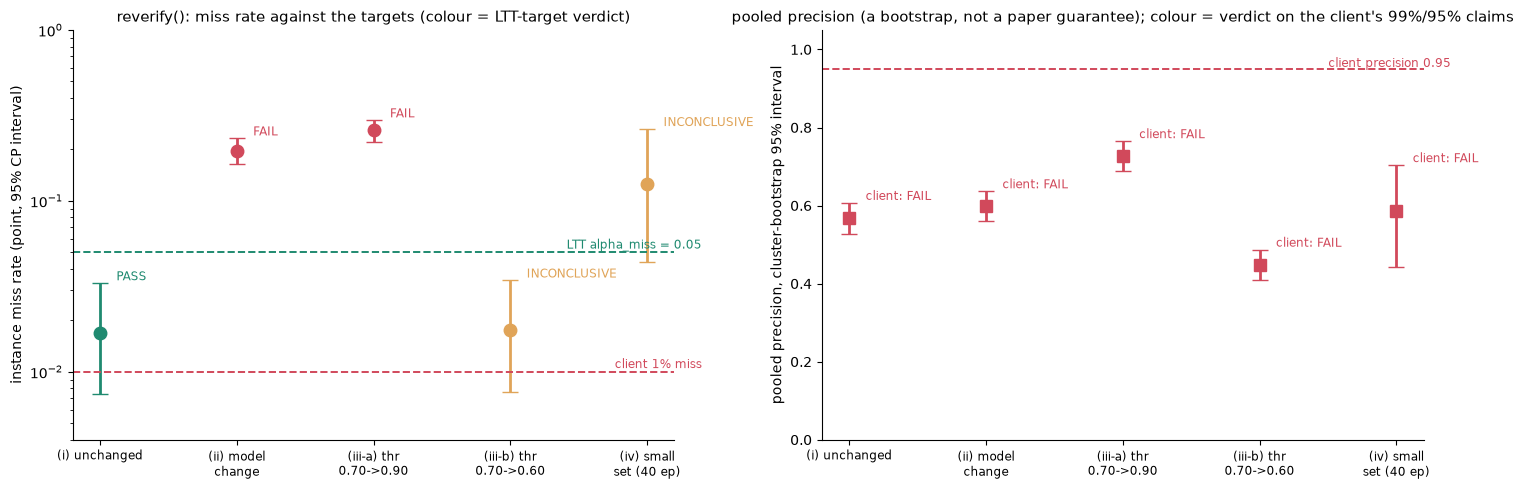

In [29]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
names = list(H); short = ["(i) unchanged", "(ii) model\nchange", "(iii-a) thr\n0.70->0.90", "(iii-b) thr\n0.70->0.60", "(iv) small\nset (40 ep)"]
vcol = {"PASS": C_LTT, "FAIL": C_REQ, "INCONCLUSIVE": C_CRC}
ax = axes[0]
for i, nm in enumerate(names):
    v = H[nm]
    ax.errorbar(i, v["miss_rate"], yerr=[[v["miss_rate"] - v["miss_rate_lower_bound"]], [v["prop26_U"] - v["miss_rate"]]], fmt="o", color=vcol[v["verdict_ltt_targets"]], capsize=6, ms=9, lw=2)
    ax.text(i + 0.12, v["prop26_U"], v["verdict_ltt_targets"], fontsize=8.5, color=vcol[v["verdict_ltt_targets"]], va="bottom")
ax.axhline(HARNESS_TARGETS["miss"], color=C_LTT, ls="--", lw=1.4); ax.text(len(names) - 0.6, HARNESS_TARGETS["miss"] * 1.05, f"LTT alpha_miss = {HARNESS_TARGETS['miss']}", color=C_LTT, ha="right", fontsize=8.5)
ax.axhline(0.01, color=C_REQ, ls="--", lw=1.4); ax.text(len(names) - 0.6, 0.0105, "client 1% miss", color=C_REQ, ha="right", fontsize=8.5)
ax.set_yscale("log"); ax.set_ylim(0.004, 1.0); ax.set_xticks(range(len(names))); ax.set_xticklabels(short, fontsize=8.5)
ax.set_ylabel("instance miss rate (point, 95% CP interval)"); ax.set_title("reverify(): miss rate against the targets (colour = LTT-target verdict)")
ax = axes[1]
for i, nm in enumerate(names):
    v = H[nm]; lo, hi = v["pooled_precision_boot95"]
    ax.errorbar(i, v["pooled_precision"], yerr=[[v["pooled_precision"] - lo], [hi - v["pooled_precision"]]], fmt="s", color=vcol[v["verdict_client_claims"]], capsize=6, ms=8, lw=2)
    ax.text(i + 0.12, hi, "client: " + v["verdict_client_claims"], fontsize=8.5, color=vcol[v["verdict_client_claims"]], va="bottom")
ax.axhline(0.95, color=C_REQ, ls="--", lw=1.4); ax.text(len(names) - 0.6, 0.955, "client precision 0.95", color=C_REQ, ha="right", fontsize=8.5)
ax.set_ylim(0, 1.05); ax.set_xticks(range(len(names))); ax.set_xticklabels(short, fontsize=8.5)
ax.set_ylabel("pooled precision, cluster-bootstrap 95% interval"); ax.set_title("pooled precision (a bootstrap, not a paper guarantee); colour = verdict on the client's 99%/95% claims")
plt.tight_layout(); plt.show()

#### How to read this chart

Two panels; five cases on the x axis: (i) unchanged, (ii) model change, (iii-a) threshold 0.90, (iii-b) threshold 0.60, (iv) small 40-episode set.

- **Left: miss rate against the targets.** y (log) = instance miss rate; the dot is the point estimate, the bar the Clopper-Pearson interval at delta = 0.05. Green dashed line = LTT target 0.05; red dashed line = the client's 1%. Colour = LTT-target verdict. Case (i) is green, with an interval of roughly 0.007 to 0.033: under 0.05 but straddling 1%, so it passes the LTT target without settling the client's 99%. (ii) and (iii-a) are red, intervals above 0.16: the change is caught. (iii-b) is amber with a low miss rate; its INCONCLUSIVE comes from the false-blur leg, not shown here. (iv) is amber with a very wide bar straddling 0.05: too little data.
- **Right: pooled precision with a cluster-bootstrap 95% interval.** Every point is red ("client: FAIL", the combined 99%/95% verdict) and every interval is far below 0.95 (0.57, 0.60, 0.73, 0.45, 0.59).

Pattern: the left panel reacts to recall damage; the right does not react to anything, because the precision shortfall is structural in this synthetic setup. A re-verification is only as good as the size of the fresh audit set.

## Results summary

**Claim.** Every number below is labelled by where it comes from: **synthetic** (computed on the simulated corpora, so it says nothing about real footage), **measured** (timed on this shared WSL2 VM, with several-fold run-to-run variance), **assumed** (placeholders for prices and GPU speed-up, never provider quotes) or **paper** (a number quoted from one of the three papers, shown next to the notebook's own recomputation). The table is built from the live variables of sections 3 to 7; nothing is typed in except the two paper reference numbers. Table A puts the client's targets **T1** and the relaxed, revised targets **T2** side by side (the T2 rule was revised once, after the first version, T2-v1, failed on CAL; both are on the record in section 3). Table B lists the rest, one row per number. A-priori self-checks R.1 to R.3 confirm that no row is unlabelled, that the verdict on the client's 99% recall claim matches an independent recomputation, and that the target table agrees with the audited configuration. The cell also lists every earlier CHECK that is not PASS.

In [30]:
# ---- Results summary (computed from the variables above; every row labelled synthetic / measured / assumed / paper) ----
# Nothing below is typed in by hand except the two PAPER reference numbers (marked label = paper); everything else is read from the live variables of sections 3-7.
LABELS_OK = {"synthetic", "measured", "assumed", "paper"}
def _fmt(x, nd=4):
    return f"{x:.{nd}f}"

# ---- table A: the two target sets side by side (section 3; LTT, delta = DELTA) ----
def _target_row(name, alpha, key, note):
    d = LTT_MAIN[key]; lam = d["lam_hat"]; p = d["p_test"]; n_cert = int(lam.sum())
    if n_cert:
        j = J_T2                                                                             # the chosen (cheapest, ties -> fewest false blurs) member of Lambda-hat
        cfg, cal = describe_key(ALL_KEYS[j]), f"miss {_fmt(p['miss'][j])}, episode-FDP {_fmt(p['fb'][j], 3)}, pooled precision {_fmt(p['pooled_prec'][j], 3)}"
    else:
        exc = np.maximum(p["miss"] / alpha["miss"], p["fb"] / alpha["fb"]); jb = int(np.argmin(exc))
        cfg = "none (empty Lambda-hat: abstain)"
        cal = (f"closest config (NOT certified) {describe_key(ALL_KEYS[jb])}: miss {_fmt(p['miss'][jb])}, episode-FDP {_fmt(p['fb'][jb], 3)}, "
               f"pooled precision {_fmt(p['pooled_prec'][jb], 3)}; lowest miss anywhere {_fmt(p['miss'].min())}")
    return dict(target_set=name, alpha_miss=alpha["miss"], alpha_false_blur=alpha["fb"], delta=DELTA, certified=("YES" if n_cert else "NO"), lambda_hat_size=n_cert,
                chosen_config=cfg, CAL_point_estimates=cal, label="synthetic")
TARGETS_DF = pd.DataFrame([_target_row("T1: client's targets", ALPHA_T1, "T1", ""), _target_row("T2: relaxed, revised (T2-v2)", ALPHA_T2, "T2", "")])

# ---- table B: everything else, one row per number ----
ROWS = []
def add(block, item, value, label, source):
    ROWS.append(dict(block=block, item=item, value=value, label=label, source=source))

_rs = RS_STATS.set_index("procedure"); _pd = PROC_DF.set_index(["family", "procedure"])
_fine = "fine (step 0.01)"
add("LTT vs SeqCRC (re-splits)", f"LTT full grid, T2: violation fraction / abstain rate (R = {int(_rs.loc['T2', 'R'])} re-splits of the main run)",
    f"{_rs.loc['T2', 'violation_rate']:.3f} / {_rs.loc['T2', 'abstain_rate']:.3f}", "synthetic", "section 3(d); P1 Thm 1 bound: <= delta")
add("LTT vs SeqCRC (re-splits)", "LTT full grid, T1: violation fraction / abstain rate", f"{_rs.loc['T1', 'violation_rate']:.3f} / {_rs.loc['T1', 'abstain_rate']:.3f}", "synthetic", "section 3(d)")
for _p in ("CRC (instances)", "LTT-1D (miss only)", "CRC (episode-averaged)"):
    _r = _pd.loc[(_fine, _p)]
    add("LTT vs SeqCRC (re-splits)", f"{_p}, fine ladder, alpha = {ALPHA_CRC}: violation fraction / abstain rate / mean true miss (R = {int(_r['R'])})",
        f"{_r['violation_rate']:.3f} / {_r['abstain_rate']:.3f} / {_r['mean_true_miss']:.4f}", "synthetic", "section 4; CRC controls the mean, LTT the probability")
_sn = SWEEP_N_DF.set_index(["cal_episodes", "procedure"])
add("LTT vs SeqCRC (re-splits)", f"smallest calibration set ({int(SWEEP_N[0])} episodes): CRC violation vs LTT-1D violation (LTT-1D abstain)",
    f"{_sn.loc[(SWEEP_N[0], 'CRC'), 'violation_rate']:.3f} vs {_sn.loc[(SWEEP_N[0], 'LTT-1D'), 'violation_rate']:.3f} ({_sn.loc[(SWEEP_N[0], 'LTT-1D'), 'abstain_rate']:.2f})", "synthetic", "section 4 size sweep")

for _nm in ("T2", "BEST"):
    _a = AUD[_nm]
    add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, f"Prop. 26 on {_nm} config {describe_key(_a['key'])}: C/Q = {_a['C']}/{_a['Q']} -> miss-rate bound U_Q(C, delta) / recall lower bound",
        f"{_a['U']:.4f} / {1 - _a['U']:.4f}", "synthetic", "P3 Prop. 26 (Clopper-Pearson over audited face instances); the ONLY recall basis (Remark 9)")
add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, f"excluded-pool missed mass (T2 config): K0 = {K0}/{N0_SAMPLE}; Thm 8 r <= M_U/N ; Thm 7 r <= p0*U",
    f"{r_hyper:.4f} ; {r_binom:.4f}", "synthetic", "P3 Thm 7/8 on 45-s segments (segment length derived here); NOT a recall claim")
add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, f"implied SEGMENT-level recall lower bound (prevalence lower bound a = {a_pi:.3f}, joint confidence {1 - DELTA_AUDIT:.2f})",
    f"{recall_seg_lb:.3f}", "synthetic", "P3 Remark 9: recall >= 1 - r/a")
add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, "Monte Carlo coverage of the excluded-pool bounds: Thm 8 finite pool / Thm 7 on dependent segments", f"{cov_thm8:.4f} / {cov_thm7:.4f}", "synthetic", "section 5(b); nominal 0.975 each")
add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, "Thm 19 walk returns threshold: segment-mass version (eps = %.2f) / instance-level twin (eps = %.2f, derived here)" % (EPS_SEG, EPS_INST),
    f"{NESTED_THR[ret_seg] if ret_seg >= 0 else 'none'} / {NESTED_THR[ret_inst] if ret_inst >= 0 else 'none'}", "synthetic", "P3 Thm 19; nesting violations on the audit: %d instance-level, %d pool-level (0 = exactly nested)" % (inst_viol, pool_viol))
for _, _t in T29.iterrows():
    add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, f"Thm 29 stress bounds, {_t['config']} config (declared generator only): rho_max / rho_avg at delta/(2|G|)", f"{_t['rho_max_bound']:.4f} / {_t['rho_avg_bound']:.4f}", "synthetic", "P3 Thm 29; valid only for the declared perturbations")
for _, _p in PREC_DF.iterrows():
    add("Sealed audit (delta = %.2f)" % DELTA_AUDIT, f"client's POOLED precision, {_p['config']} config: point and episode-cluster bootstrap 95% interval", f"{_p['pooled_precision']:.3f} {_p['boot95']}", "synthetic", "bootstrap, NOT a P1/P2/P3 guarantee")

add("Cost", "decode / YuNet 4K detect / libx264 encode throughput on this shared WSL2 VM (fps; several-fold run-to-run variance)",
    f"{THROUGHPUT['decode_fps']:.1f} / {THROUGHPUT['detect_fps']:.2f} / {THROUGHPUT['encode_fps']:.2f}", "measured", "data/smoke/timings.json via section 3 throughput dict")
add("Cost", "CPU / GPU price per hour; GPU speed-up", f"${PRICE['assumed_cpu_usd_per_hour']} / ${PRICE['assumed_gpu_usd_per_hour']} ; {THROUGHPUT['assumed_gpu_speedup']:.0f}x", "assumed", "placeholders, not provider quotes")
for _s in sorted(COST_BY_STRIDE):
    add("Cost", f"$/video-hour at stride {_s}: CPU (measured throughput x assumed price) / GPU (assumed speed-up x assumed price)",
        f"{COST_BY_STRIDE[_s]['cpu_usd_per_video_hour']:.3f} / {COST_BY_STRIDE[_s]['gpu_usd_per_video_hour']:.3f}", "assumed", "processing_cost; only stride 1 is certified here (all Lambda-hat members are stride 1)")
add("Cost", "GPU break-even speed-up = GPU price / CPU price (GPU cheaper only above it)", f"{BE_SPEEDUP:.1f}x", "assumed", "section 6 identity")
_sv = VAR_DF[VAR_DF["stride"] == 1]["cpu_usd_per_video_hour"]
add("Cost", "CPU $/video-hour at stride 1 across the recorded slow / measured / fast smoke runs", " / ".join(f"{v:.2f}" for v in _sv), "assumed", "throughput ranges recorded in Notebook 2 (measured) x the ASSUMED price: the dollar figure is assumed")

_best_recall_ok = any(AUD[n]["U"] <= EPS_TARGET for n in AUD)
_best_prec_ok = any(AUD[n]["prec_ci"][0] >= 0.95 for n in AUD)
add("Client's claims", "99% recall (miss rate <= 1%) certified for ANY audited config? (needs U_Q(C, delta) <= 0.01)", "YES" if _best_recall_ok else "NO", "synthetic",
    "; ".join(f"{n}: U = {AUD[n]['U']:.4f}" for n in AUD))
add("Client's claims", "95% pooled precision supported for ANY audited config? (bootstrap lower limit >= 0.95; a bootstrap, not a guarantee)", "YES" if _best_prec_ok else "NO", "synthetic",
    "; ".join(f"{n}: lower limit {AUD[n]['prec_ci'][0]:.3f}" for n in AUD))
_nest1 = T19.loc[T19["U_Q_C_inst"] <= EPS_TARGET, "thr"].tolist()                                          # single-config Prop. 26 at delta (post hoc: eps = 1% was NOT pre-registered for this family)
_nestM = [k[0] for k in NESTED_KEYS if float(cp_upper(int(NEST[k]["missed"].sum()), len(NEST[k]["missed"]), DELTA_AUDIT / len(NESTED_KEYS))) <= EPS_TARGET]
add("Client's claims", f"POST-HOC look at the pre-registered nested family: thresholds with U_Q(C, delta) <= 1% at delta / with a delta/M union bound over the M = {len(NESTED_KEYS)} members (pooled precision of those at delta)",
    f"{_nest1} / {_nestM if _nestM else 'none'} (precision {T19.loc[T19['U_Q_C_inst'] <= EPS_TARGET, 'pooled_precision'].tolist()})", "synthetic",
    f"eps = 1% was not pre-registered for this family (registered eps_inst = {EPS_INST}): NOT a certificate of the 99% claim; and the 95% precision claim fails for every member")
add("Client's claims", "T1 (client targets) certified by LTT on CAL?", TARGETS_DF.iloc[0]["certified"], "synthetic", "section 3")
add("Re-verification harness", "verdicts (LTT targets | client 99%/95%) for cases i, ii, iii-a, iii-b, iv", "; ".join(f"{v['verdict_ltt_targets']}|{v['verdict_client_claims']}" for v in H.values()), "synthetic", "section 7")
add("Paper reference", "P3 Sec. 8: U_300(0, 0.025) = 0.01222 (paper) vs this notebook's Clopper-Pearson", f"0.01222 (paper) vs {float(cp_upper(0, 300, 0.025)):.5f}", "paper", "P3 Sec. 8 worked example [facered-q8]")
add("Paper reference", "P3 Remark 9: pi = 0.01 and r <= 0.005 give recall >= (paper) 0.5", f"{1 - 0.005 / 0.01:.1f}", "paper", "[facered-q9, facered-q11]")
SUMMARY_DF = pd.DataFrame(ROWS)

pd.set_option("display.width", 320); pd.set_option("display.max_colwidth", 150); pd.set_option("display.max_rows", 200)
print("A. The two target sets side by side (LTT, delta = %.2f; CAL/CAL2 point estimates, synthetic data)" % DELTA)
print(TARGETS_DF.to_string(index=False))
print("\nB. Everything else, one row per number")
print(SUMMARY_DF.to_string(index=False))
_last = {c: v for c, _d, v in CHECKS}                                              # last verdict per check id
_not_pass = [c for c, v in _last.items() if v != "PASS"]
print(f"\nSelf-checks so far: {len(_last)} distinct ids, {len(_last) - len(_not_pass)} PASS; NOT PASS: {_not_pass}  (each is reported in the section that ran it)")

check("R.1", "every row of both summary tables carries a label from {synthetic, measured, assumed, paper} (a-priori: no unlabelled number)",
      bool(TARGETS_DF["label"].isin(LABELS_OK).all() and SUMMARY_DF["label"].isin(LABELS_OK).all()), f"{len(TARGETS_DF)} + {len(SUMMARY_DF)} rows; labels used: {sorted(set(TARGETS_DF['label']) | set(SUMMARY_DF['label']))}")
check("R.2", "the summary's verdict on the client's 99% recall claim equals an independent recomputation from the audit bounds (Prop. 26 U_Q(C, delta) <= 0.01) and from section 5's own table",
      _best_recall_ok == bool(P26_DF["claims_recall_99"].any()) == any(float(cp_upper(AUD[n]["C"], AUD[n]["Q"], DELTA_AUDIT)) <= EPS_TARGET for n in AUD),
      f"summary says {'YES' if _best_recall_ok else 'NO'}; section 5 table claims_recall_99 = {P26_DF['claims_recall_99'].tolist()}")
check("R.3", "the target table is consistent with the audit: the T2 row's chosen config is the config that was pre-registered and audited, and 'certified = NO' for T1 iff Lambda-hat is empty",
      TARGETS_DF.iloc[1]["chosen_config"] == describe_key(AUD["T2"]["key"]) and (TARGETS_DF.iloc[0]["certified"] == "NO") == (int(LTT_MAIN["T1"]["lam_hat"].sum()) == 0),
      f"T1 |Lambda-hat| = {int(LTT_MAIN['T1']['lam_hat'].sum())}; T2 chosen {TARGETS_DF.iloc[1]['chosen_config']}")

A. The two target sets side by side (LTT, delta = 0.10; CAL/CAL2 point estimates, synthetic data)
                  target_set  alpha_miss  alpha_false_blur  delta certified  lambda_hat_size                              chosen_config                                                                                                                                            CAL_point_estimates     label
        T1: client's targets        0.01              0.05    0.1        NO                0           none (empty Lambda-hat: abstain) closest config (NOT certified) thr=0.75 stride=1 gap=30 pad=20 margin=0.3: miss 0.0585, episode-FDP 0.308, pooled precision 0.588; lowest miss anywhere 0.0079 synthetic
T2: relaxed, revised (T2-v2)        0.05              0.45    0.1       YES                2 thr=0.70 stride=1 gap=10 pad=20 margin=0.3                                                                                                         miss 0.0355, episode-FDP 0.373, pooled precision 0.5

## Limitations and open engineering choices

**What the sources leave open:**

The notebook can compute certificates; it cannot make these choices. Each one changes what can honestly be promised.

1. **The targets.** The client's T1 (miss <= 1%, false blur <= 5%) is **not certified** on this synthetic corpus (empty certified set on CAL); the closest configuration misses 5.85% of instances with an episode-averaged false-blur of 0.308, and the lowest miss rate anywhere (0.0079) comes with a false-blur of 0.612. Options: relax the targets (T2 shows one certified point, at 5% miss and 45% false blur), accept a human-review step for what the pipeline flags, or improve the detector. Also decide what "precision 95%" means in the contract: LTT controls an episode-*averaged* false-blur fraction, the client's number is *pooled* over blur box-frames; the notebook reports both and they differ (**derived here**).
2. **The real labelled staged set and who labels it.** Every certificate here rests on labelled instances: certifying 1% needs at least 299 audited instances with zero misses, 473 with one, 628 with two (section 2's table, derived from Clopper-Pearson; P3's Sec. 4.6 table has the same arithmetic for the excluded pool [facered-q8]). Choose the vendor, the guidelines and the budget; the audit set must stay sealed.
3. **The real detector and its licence.** The detector here is a simulator plus a YuNet cost model. A different detector means a new grid, new calibration and a new audit.
4. **Blur method** (derived here; the papers are silent): destructive pixelation or solid fill is irreversible, a light Gaussian blur may not be. This is a policy choice, not a statistical one.
5. **Encoder and CRF 16** versus a smaller file, and **the GPU instance and real prices**. All dollar figures above are measured throughput times assumed prices.
6. **Screens and photos in the scene** (a face on a monitor, a photo on a wall): whether they count as faces to redact is a **contract clause**, not something any paper decides.
7. **Which certificate to put in the contract.** Only Prop. 26 over audited face instances supports a recall claim; the missed-mass bound of 5(b) and the stress bounds of 5(d) do not.

**Engineering choices left open:**

- **`redact.py` command-line tool**: resumable, JSON log of every decision, non-zero exit on failure.
- **A real labelled staged capture and a real-detector run**; nothing here uses real footage.
- **Per-stratum reporting** (lighting, distance, camera, scene): all guarantees here are *marginal* over the audit distribution: "all the guarantees in this paper are marginal" `[P1 Sec. 5, facered-q3]`, and Prop. 26 is likewise an average over audited positives. P3 Sec. 9 offers stratified audits with a union bound `[P3 Sec. 9, facered-q11]`; none is implemented here, so a per-stratum report (children, mirrors, small faces) would be a derived-here diagnostic, not a guarantee.
- **The SeqCRC localisation and classification step** (only the confidence step was implemented in section 4), P3's incremental-coverage diagnostic (Thm 24) and its noisy-label variants (Sec. 9).
- **Cost minimisation among certified configurations with a pre-registered cheaper path**: the certified set here contains only stride 1.

## What the three sources do not settle

- **Temporal dependence.** No paper covers video, tracking or frame-to-frame dependence [facered-q11, facered-q12(d)]. The exchangeable unit (instance or episode) is an assumption of this notebook (derived here), and the segment coverage study in 5(b) is a simulation, not a proof.
- **Per-instance versus per-frame units and temporal padding.** None of the three papers defines them [facered-q12(d)].
- **Precision.** SeqCRC does not guarantee it ("only empirically limits false positives" [P2 Sec. V-D, facered-q5]); LTT can control a false-blur risk jointly with recall [P1, facered-q12(a)], but no source certifies the client's *pooled* precision on an audit set; the bootstrap here is not a guarantee.
- **Cost.** Choosing the cheapest configuration among certified ones, and every dollar figure, are outside all three papers [facered-q12(d)].
- **Noisy labels.** P3 needs noiseless audit labels (Assumption 2) and weakens the missed-mass bound under a known sensitivity floor; its two-pool and positive-conditional certificates, including Prop. 26, break under unmodelled noise [P3 Assumption 2, Sec. 9, facered-q11].
- **Distribution shift.** No source gives coverage between calibration/audit data and deployment beyond a declared perturbation generator [facered-q11]; that is why section 7 demands a fresh audit set after any change.
- **Rare faces.** An absolute missed-mass bound is not recall when faces are rare [P3 Remark 9, facered-q11]; only Prop. 26 on audited instances speaks to the client's per-instance 99%.